In [1]:
import pandas as pd
import os
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

<h1><center><strong>DATA CLEANING</strong></center></h1>

# CHECK

In [24]:
aws_heartlab_msmt.head()

,ID,REP_ID,MEAS_ID,VALUE,HLCODE,COMMENTS,UNITS,DeidentifiedStudyID,group_tag
0,8138939,351677,100243,0.528,LV_EDV_Teich_2D,Left ventricle end diastolic volume (Teichholz) (2D),ml,1.2.276.0.7230010.3.1.2.859333938.1.1703135004.8346773,<N5>
1,8324424,354938,100243,0.200,LV_EDV_Teich_2D,Left ventricle end diastolic volume (Teichholz) (2D),ml,1.2.276.0.7230010.3.1.2.859333938.1.1703141568.8439702,<N5>
2,7780864,345164,100266,31.000,RVSP,Right ventricular systolic pressure,mmHg,1.2.276.0.7230010.3.1.2.859333938.1.1703429008.14045253,<N14>
3,7781151,345169,100544,115.000,LA_ESV_SP_4CH_MOD,Left atrial end systolic volume single plane 4CH (MOD),ml,1.2.276.0.7230010.3.1.2.1714578744.1.1703122454.8098825,<N17>
4,7781152,345169,100250,96.000,TR_PEAK_VELsub,NaN,m/sec,1.2.276.0.7230010.3.1.2.1714578744.1.1703122454.8098825,<N14>


In [11]:
print(aws_heartlab_findings.shape)
aws_heartlab_findings.head()

(1263258, 8)


,ID,FIN_ID,REP_ID,DeidentifiedStudyID,HLCODE,SENTENCE,condition_tag,common_label
0,4009028,1,185500,1.2.276.0.7230010.3.1.2.1714578744.1.1703275050.10646188,left ventricle^morphology^size^normal,The left ventricular chamber size is normal.,<C28>,LVC_normal
1,4009029,33,185500,1.2.276.0.7230010.3.1.2.1714578744.1.1703275050.10646188,left ventricle^function^systolic global ejection fraction^normal,There is normal left ventricular systolic function (EF>60%).,<C39>,LVSF_normal
2,4009034,359,185500,1.2.276.0.7230010.3.1.2.1714578744.1.1703275050.10646188,mitral valve^function^regurgitation^mild,There is mild mitral regurgitation observed.,<C41>,MR_mild
3,4009035,458,185500,1.2.276.0.7230010.3.1.2.1714578744.1.1703275050.10646188,tricuspid valve^function^regurgitation^mild to moderate,There is mild to moderate tricuspid regurgitation.,<C74>,TR_mild
4,4009439,622,185521,1.2.276.0.7230010.3.1.2.811753780.1.1703648530.16202885,aorta^dilatation^ascending dilatation degree^mild,There is mild dilatation of the ascending aorta.,<C0>,AA_mild


In [12]:
aws_heartlab_findings.loc[aws_heartlab_findings['DeidentifiedStudyID'] == '1.2.276.0.7230010.3.1.2.895627313.1.1724558499.1282764']

,ID,FIN_ID,REP_ID,DeidentifiedStudyID,HLCODE,SENTENCE,condition_tag,common_label


In [16]:
len(aws_syngo_findings)

542428

In [27]:
aws_syngo_findings.loc[aws_syngo_findings['DeidentifiedStudyID'] == '1.2.276.0.7230010.3.1.2.895693665.1.1724183172.1188930']

,StudyRef,ObservationID,Value,Type,Name,DeidentifiedStudyID,condition_tag,common_label
222215,1560389,16,normal,NORMAL,LV_Cavity_Size-ASE_obs,1.2.276.0.7230010.3.1.2.895693665.1.1724183172.1188930,<C28>,LVC_normal
222216,1560389,20,normal,NORMAL,PA_pressure_obs,1.2.276.0.7230010.3.1.2.895693665.1.1724183172.1188930,<C48>,PAP_normal
222217,1560389,22,normal,NORMAL,RV_Sys_Pressure_obs,1.2.276.0.7230010.3.1.2.895693665.1.1724183172.1188930,<C48>,PAP_normal
222218,1560389,46,normal,OTHER,RV_size-ASE_obs,1.2.276.0.7230010.3.1.2.895693665.1.1724183172.1188930,<C71>,RV_normal
222219,1560389,54,mildly_dilated,ABNORMAL,LA_size-ASE_obs,1.2.276.0.7230010.3.1.2.895693665.1.1724183172.1188930,<C21>,LA_mild
222220,1560389,57,dilated,OTHER,RA_size-ASE_obs,1.2.276.0.7230010.3.1.2.895693665.1.1724183172.1188930,<C63>,RA_severe
222221,1560389,65,mild,OTHER,TR_degree_obs,1.2.276.0.7230010.3.1.2.895693665.1.1724183172.1188930,<C74>,TR_mild
222222,1560389,80,trace,OTHER,PV_Regurgitation_obs,1.2.276.0.7230010.3.1.2.895693665.1.1724183172.1188930,<C59>,PR_trace
222223,1560389,89,greater_than_50_,NORMAL,IVC_HV_respiratory_change-ASE_obs,1.2.276.0.7230010.3.1.2.895693665.1.1724183172.1188930,<C18>,IVC_GT50
222224,1560389,117,normal,OTHER,LV_Fx_qualitative_obs,1.2.276.0.7230010.3.1.2.895693665.1.1724183172.1188930,<C39>,LVSF_normal


In [18]:
aws_heartlab_findings['DeidentifiedStudyID'].nunique()

217288

In [39]:
aws_syngo_findings.head()

,StudyRef,ObservationID,Value,Type,Name,DeidentifiedStudyID,condition_tag,common_label
0,1000750,16,normal,NORMAL,LV_Cavity_Size-ASE_obs,1.2.276.0.7230010.3.1.2.895693665.1.1725195593.4282089,<C28>,LVC_normal
1,1000750,20,severely_elevated,ABNORMAL,PA_pressure_obs,1.2.276.0.7230010.3.1.2.895693665.1.1725195593.4282089,<C49>,PAP_severe
2,1000750,22,severe,ABNORMAL,RV_Sys_Pressure_obs,1.2.276.0.7230010.3.1.2.895693665.1.1725195593.4282089,<C49>,PAP_severe
3,1000750,46,mildly_enlarged,ABNORMAL,RV_size-ASE_obs,1.2.276.0.7230010.3.1.2.895693665.1.1725195593.4282089,<C69>,RV_mild
4,1000750,54,severely_dilated,ABNORMAL,LA_size-ASE_obs,1.2.276.0.7230010.3.1.2.895693665.1.1725195593.4282089,<C24>,LA_severe


In [17]:
aws_syngo_findings['DeidentifiedStudyID'].nunique()

53944

In [14]:
final_df = pd.read_csv('aws/hls_master_v3.csv')

In [28]:
# final_df.loc[final_df['DeidentifiedStudyID'] == '1.2.276.0.7230010.3.1.2.811753780.1.1703762181.17487612']

In [44]:
# final_df.loc[final_df['DeidentifiedStudyID'] == '1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892']

In [36]:
final_df = final_df.drop(columns=["Unnamed: 0.1", "Unnamed: 0"], errors="ignore")
row_count = final_df["StudyRef"].notna().sum()


In [40]:
# rows in aws_syngo_findings whose ID also appears in final_df
cnt_in_final = aws_syngo_findings["DeidentifiedStudyID"].isin(
                 final_df["DeidentifiedStudyID"]
               ).sum()

# rows in final_df whose ID also appears in aws_syngo_findings
cnt_in_aws   = final_df["DeidentifiedStudyID"].isin(
                 aws_syngo_findings["DeidentifiedStudyID"]
               ).sum()


In [48]:
import ast

# parse each cell if it’s a string that looks like a Python literal
final_df["findings"] = final_df["findings"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

dict_rows = final_df["findings"].apply(lambda v: isinstance(v, dict)).sum()
list_rows = final_df["findings"].apply(lambda v: isinstance(v, list)).sum()


In [49]:
dict_rows

49025

In [52]:
dict_rows_df = final_df[final_df["findings"].apply(lambda v: isinstance(v, dict))]

In [54]:
dict_rows_df.to_csv('aws/hls_dict_v3.csv')

In [50]:
list_rows

216983

In [41]:
cnt_in_final

515446

In [42]:
cnt_in_aws

48663

In [37]:
row_count

49025

In [38]:
final_df.columns

Index(['REP_ID', 'findings', 'measurements', 'condition_tags',
       'measurement_tags', 'measurement_tokens', 'DeidentifiedStudyID',
       'StudyRef', 'STUDY_DATE', 'PATIENT_ID', 's3_key', 'study_dir', 'split',
       'measurement_tokens_dedup', 'condition_tags_dedup'],
      dtype='object')

In [34]:
final_df.shape

(266008, 15)

In [32]:
final_df.head()

,REP_ID,findings,measurements,condition_tags,measurement_tags,measurement_tokens,DeidentifiedStudyID,StudyRef,STUDY_DATE,PATIENT_ID,s3_key,study_dir,split,measurement_tokens_dedup,condition_tags_dedup
0,2734.0,"['The left ventricular chamber size is normal.', 'A pacemaker wire is visualized in the right ventricle.', 'There is a membranous ventricular septal defect. (VSD likely represents a patch leak)', 'The septal defect is demonstrated by color Doppler.', 'There is predominant left-to-right shunting across the interventricular septum. (with PG = 91 mmHg.)', 'Septal wall motion has a post-operative appearance.', 'There is no evidence of aortic stenosis.', 'Mild aortic regurgitation is present.', 'There is no evidence of mitral stenosis.', 'There is mild mitral regurgitation observed. (There is elongated extension of the posteromedial papillary muscle noted, running along the interventricular septum. No LVOT obstruction noted.)', 'There is moderate tricuspid regurgitation.', 'The Right Ventricular Systolic Pressure is calculated at ( )mmHg.', 'There is mild pulmonic stenosis present.', 'There is severe pulmonic regurgitation present.', 'The left atrium is mildly dilated.', 'The right atrial cavity size is mildly dilated.', 'A pacemaker wire is visualized in the right atrium.', 'There is no pericardial effusion.', 'F/U Repaired Tetralogy of Fallot', 'Global left ventricular wall motion and contractility are within normal limits (EF>60%).', 'The right ventricular cavity size is mildly enlarged.', 'The right ventricular global systolic function is mildly reduced.']",{},"['<C11>', '<C21>', '<C28>', '<C41>', '<C52>', '<C58>', '<C60>', '<C65>', '<C69>', '<C75>']",[],[],1.2.276.0.7230010.3.1.2.845494328.1.1703364833.18441940,NaN,2004-02-10,2988134,echo-study/1.2.276.0.7230010.3.1.2.845494328.1.1703364833.18441940/,echo-study,train,[],"['<C11>', '<C21>', '<C28>', '<C41>', '<C52>', '<C58>', '<C60>', '<C65>', '<C69>', '<C75>']"
1,3491.0,"['The left ventricular chamber size is normal.', 'There is normal left ventricular systolic function (EF>60%).', 'The left atrium is dilated.', 'The right ventricular global systolic function is normal.', 'There is no evidence of aortic stenosis.', 'There is no evidence of aortic regurgitation.', 'The mitral valve leaflets appear normal.', 'There is trivial mitral regurgitation.', 'The tricuspid valve leaflets are morphologically normal.', 'There is trace tricuspid regurgitation present.', 'The pulmonic valve appears normal in structure and function.', 'The aortic valve is trileaflet.', 'F/U post heart transplantation', 'The right ventricular cavity size is upper limits of normal.', 'There is a small loculated pericardial effusion. (The pericardial effusion at its maximum measures 8-12mm posterior to LV and 8mm adjacent to RV.)', 'There are no echo signs of cardiac tamponade. Clinical correlation is required.', 'Moderate concentric left ventricular hypertrophy is observed.']",{},"['<C11>', '<C22>', '<C28>', '<C32>', '<C39>', '<C53>', '<C6>', '<C71>']",[],[],1.2.276.0.7230010.3.1.2.845494328.1.1703319042.17124420,NaN,2004-02-18,2481240,echo-study/1.2.276.0.7230010.3.1.2.845494328.1.1703319042.17124420/,echo-study,train,[],"['<C11>', '<C22>', '<C28>', '<C32>', '<C39>', '<C53>', '<C6>', '<C71>']"
2,5518.0,"['F/U Tetralogy of Fallot', 'The left ventricular chamber size is normal.', 'There is normal left ventricular systolic function (EF>60%). (Dyssynergic septum.)', 'The right ventricular global systolic function is moderately reduced.', 'The mitral valve leaflets appear normal.', 'There is no evidence of mitral stenosis.', 'There is trivial mitral regurgitation.', 'The aortic valve structure is normal.', 'There is no evidence of aortic stenosis.', 'There is no evidence of aortic regurgitation.', 'The tricuspid valve leaflets are morphologically normal.', 'There is no evidence of tricuspid valve regurgitation.', 'The left atrium is normal in size with no visual thrombus identified.', 'There is no pericardia

# **ALL MEASURE**

In [2]:
# aws_heartlab_msmt = pd.read_csv('aws/aws_heartlab_msmt.csv',index_col=0)
# aws_syngo_msmt = pd.read_csv('aws/aws_syngo_msmt.csv',index_col=0)

In [2]:
import pandas as pd

In [4]:
# aws_heartlab_msmt = pd.read_csv('aws/aws_heartlab_msmt_v2.csv',index_col=0)
# aws_syngo_msmt = pd.read_csv('aws/aws_syngo_msmt_v2.csv',index_col=0)

In [4]:
hls_measure = pd.read_csv('heartlab_syngo_msmt.csv', index_col=0)
print(hls_measure.shape)
hls_measure.head()

(43, 6)


,label_group,child_label,source,definition,COUNT,group_tag
0,Aortic valve peak velocity,AoV Vmax,syngo_msmt,Maximum systolic velocity across the aortic valve – first-line numeric index of aortic-stenosis severity.,161917,<N0>
1,Aortic valve peak velocity,AV_PEAK_VEL,hl_narr_msmt,Maximum systolic velocity across the aortic valve – first-line numeric index of aortic-stenosis severity.,7341,<N0>
2,Aortic valve mean gradient,AoV mean grad,syngo_msmt,Time-averaged systolic pressure gradient across the aortic valve used for stenosis grading.,76639,<N1>
3,Aortic valve mean gradient,AV_MEAN_GRAD,hl_narr_msmt,Time-averaged systolic pressure gradient across the aortic valve used for stenosis grading.,11440,<N1>
6,Aortic valve effective orifice area,AoV area (VTI),syngo_msmt,Effective aortic-valve area by the continuity equation – quantitative reference for stenosis severity.,27744,<N2>


In [5]:
print(aws_heartlab_msmt.shape)
aws_heartlab_msmt.head()

(283421, 9)


,ID,REP_ID,MEAS_ID,VALUE,HLCODE,COMMENTS,UNITS,DeidentifiedStudyID,group_tag
0,8138939,351677,100243,0.528,LV_EDV_Teich_2D,Left ventricle end diastolic volume (Teichholz) (2D),ml,1.2.276.0.7230010.3.1.2.859333938.1.1703135004.8346773,<N5>
1,8324424,354938,100243,0.200,LV_EDV_Teich_2D,Left ventricle end diastolic volume (Teichholz) (2D),ml,1.2.276.0.7230010.3.1.2.859333938.1.1703141568.8439702,<N5>
2,7780864,345164,100266,31.000,RVSP,Right ventricular systolic pressure,mmHg,1.2.276.0.7230010.3.1.2.859333938.1.1703429008.14045253,<N14>
3,7781151,345169,100544,115.000,LA_ESV_SP_4CH_MOD,Left atrial end systolic volume single plane 4CH (MOD),ml,1.2.276.0.7230010.3.1.2.1714578744.1.1703122454.8098825,<N17>
4,7781152,345169,100250,96.000,TR_PEAK_VELsub,NaN,m/sec,1.2.276.0.7230010.3.1.2.1714578744.1.1703122454.8098825,<N14>


In [89]:
print(aws_syngo_msmt.shape)
aws_syngo_msmt.head()

(801539, 7)


,StudyRef,MeasurementTypeRef,MeasurementName,Value,Units,DeidentifiedStudyID,group_tag
0,1000712,11659,AoV Vmax,1.384158,m/s,1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892,<N0>
1,1000712,11666,Ao Asc diam,3.244808,cm,1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892,<N19>
2,1000712,11686,LVOT peak grad,3.877400,mmHg,1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892,<N10>
3,1000712,11691,"LV EF, Teich, 2D",65.251530,%,1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892,<N4>
4,1000712,11713,MV DT,218.084660,msec,1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892,<N11>


In [90]:
# choose the columns you actually want to inspect
hl_cols   = ["group_tag", "HLCODE",        "UNITS"]
syn_cols  = ["group_tag", "MeasurementName", "Units"]

hl_sample  = (
    aws_heartlab_msmt
      .sort_values("group_tag")            # deterministic
      .drop_duplicates(subset="group_tag", keep="first")[hl_cols]
      .rename(columns={"UNITS": "HL_units"})
      .set_index("group_tag")
)

syn_sample = (
    aws_syngo_msmt
      .sort_values("group_tag")
      .drop_duplicates(subset="group_tag", keep="first")[syn_cols]
      .rename(columns={"Units": "Syngo_units"})
      .set_index("group_tag")
)

print("HeartLab unique tags:", len(hl_sample))
print("Syngo    unique tags:", len(syn_sample))


HeartLab unique tags: 16
Syngo    unique tags: 19


In [91]:
# tags present in Syngo but missing from HeartLab
syn_tags = set(aws_syngo_msmt['group_tag'].dropna())
hl_tags  = set(aws_heartlab_msmt['group_tag'].dropna())

missing_in_hl = sorted(syn_tags - hl_tags)

print(f"Syngo-only tags ({len(missing_in_hl)}):")
for t in missing_in_hl:
    print(" ", t)


Syngo-only tags (3):
  <N12>
  <N16>
  <N3>


In [92]:
import pandas as pd
import numpy as np

# ---------------------------------------------------------------
# 1 · build per-tag summaries for each source (now with counts)
# ---------------------------------------------------------------
hl_agg = (
    aws_heartlab_msmt
        .assign(VALUE=pd.to_numeric(aws_heartlab_msmt['VALUE'], errors='coerce'))
        .groupby('group_tag')
        .agg(
            HLCODE   = ('HLCODE', 'first'),
            HL_units = ('UNITS',  'first'),
            HL_cnt   = ('VALUE',  'size'),      # <-- NEW
            HL_min   = ('VALUE',  'min'),
            HL_max   = ('VALUE',  'max'),
            HL_mean  = ('VALUE',  'mean'),
        )
)

syn_agg = (
    aws_syngo_msmt
        .assign(Value=pd.to_numeric(aws_syngo_msmt['Value'], errors='coerce'))
        .groupby('group_tag')
        .agg(
            MeasurementName = ('MeasurementName', 'first'),
            Syngo_units     = ('Units',            'first'),
            Syn_cnt         = ('Value',            'size'),   # <-- NEW
            Syn_min         = ('Value',            'min'),
            Syn_max         = ('Value',            'max'),
            Syn_mean        = ('Value',            'mean'),
        )
)

print("HeartLab unique tags :", len(hl_agg))
print("Syngo    unique tags :", len(syn_agg))

# ---------------------------------------------------------------
# 2 · outer-join so you can compare side-by-side
# ---------------------------------------------------------------
unit_check = (
    hl_agg
        .join(syn_agg, how='outer')       # keep tags present in only one source
        .reset_index()                    # bring group_tag back as a column
        .sort_values('group_tag')
        .round(3)                         # optional: nicer printing
)

display(unit_check.head(20))


HeartLab unique tags : 16
Syngo    unique tags : 19


,group_tag,HLCODE,HL_units,HL_cnt,HL_min,HL_max,HL_mean,MeasurementName,Syngo_units,Syn_cnt,Syn_min,Syn_max,Syn_mean
0,<N0>,AV_PEAK_VEL,m/sec,6475.0,0.010,25.000,5.814,AoV Vmax,m/s,90790,-4.954,4.850000e+02,1.709
1,<N10>,LVOT_PEAK_GRAD,mmHg,1085.0,0.030,11.000,2.856,LVOT peak grad,mmHg,46735,0.000,4.161600e+04,10.191
2,<N11>,MVDec,m/sec,266.0,0.200,22.000,2.568,MV DT,msec,43035,0.000,4.884000e+03,215.114
3,<N12>,NaN,NaN,NaN,NaN,NaN,NaN,MV E/A ratio,unitless,50847,-4396.531,3.563500e+03,1.552
4,<N13>,LV_E_EPRIME_LAT_RATIO,ratio,9354.0,1.300,591.000,65.827,MV E/e',unitless,20176,0.012,1.859478e+03,10.907
5,<N14>,RVSP,mmHg,49886.0,-8219.000,681.096,60.159,RVSP (TR),mmHg,32831,4.800,6.810000e+02,35.507
6,<N15>,RV_FAC,%,25493.0,1.000,3812.000,17.918,RV FAC A4C,%,16748,-31.624,9.993000e+01,36.579
7,<N16>,NaN,NaN,NaN,NaN,NaN,NaN,TAPSE (M-mode),cm,58120,0.000,2.020000e+02,2.012
8,<N17>,LA_ESV_SP_4CH_MOD,ml,17387.0,13.400,794.479,111.208,LA Vol A/L A4C i BSA,ml/m2,25654,0.000,7.425920e+02,36.110
9,<N18>,Aos_sinus_diam,cm,31155.0,0.000,104.000,0.952,"Ao Root d, 2D",cm,39806,0.000,6.500000e+00,3.201


## **Important: Clip Values, Normalize Units, Remove Low Frequency**

In [47]:
import pandas as pd, numpy as np

# ────────────────────── toggles ───────────────────────────
DROP_IBSA      = True      # drop all Syngo rows that are indexed (/m²)
KEEP_ONE_ROOT  = True      # keep only smallest Ao-root per study
# ──────────────────────────────────────────────────────────

# ---------- raw copies ------------------------------------------------------
hl  = aws_heartlab_msmt.copy()
syn = aws_syngo_msmt.copy()

hl  = hl.rename(columns={'VALUE':'val','UNITS':'unit','HLCODE':'label'})
syn = syn.rename(columns={'Value':'val' ,'Units':'unit',
                          'MeasurementName':'label'})

# ---------- HeartLab: one-off fixes ----------------------------------------
hl.loc[hl.group_tag == "<N0>", "unit"] = "m/s"  # AoV Vmax

# Fix E/e' ratio wrongly scaled by 10
m13 = hl.group_tag == "<N13>"
hl.loc[m13, "val"]  = pd.to_numeric(hl.loc[m13, "val"], errors="coerce") / 10
hl.loc[m13, "unit"] = "unitless"

# Rename ambiguous labels
for tg,lbl in {"<N17>":"LA_ESV_raw_ml",
               "<N5>" :"LV_EDV_raw_ml",
               "<N6>" :"LV_ESV_raw_ml",
               "<N7>" :"LV_Mass_raw_g"}.items():
    hl.loc[hl.group_tag==tg,"label"] = lbl

# ---------- MV DT (sec → msec) --------------------------------------------
m11  = hl.group_tag == "<N11>"
v11  = pd.to_numeric(hl.loc[m11, "val"], errors="coerce")
sec_rows = m11 & (v11 < 20)
hl.loc[sec_rows, "val"]  = v11[sec_rows] * 1000
hl.loc[m11, "unit"] = "msec"
print(f"Converted {sec_rows.sum():,} HeartLab MV DT rows (sec → ms)")

# ---------- LVOT peak grad (kPa → mmHg) -----------------------------------
m10 = hl.group_tag == "<N10>"
vals10 = pd.to_numeric(hl.loc[m10, "val"], errors="coerce")
if vals10.median(skipna=True) < 30:
    hl.loc[m10, "val"] = vals10 * 7.5
hl.loc[m10, "unit"] = "mmHg"

# ---------- LVOT VTI (mm → cm) --------------------------------------------
m9 = hl.group_tag == "<N9>"
hl.loc[m9 & (pd.to_numeric(hl.val, errors="coerce") > 60), "val"] /= 10

# ---------- Ao diameters (normalise to cm) --------------------------------
def normalise_cm(s):
    x = pd.to_numeric(s, errors="coerce")
    med = x.median(skipna=True)
    while med and med > 7:
        x /= 10; med /= 10
    while 0 < med < 2:
        x *= 10; med *= 10
    return x

for tg in ("<N18>", "<N19>"):
    mask = hl.group_tag == tg
    hl.loc[mask, "val"] = normalise_cm(hl.loc[mask, "val"])
    hl.loc[mask & (pd.to_numeric(hl.val, errors="coerce") == 0), "val"] = np.nan
    hl.loc[mask & (pd.to_numeric(hl.val, errors="coerce") > 7), "val"] = np.nan

if KEEP_ONE_ROOT:
    root = (hl[hl.group_tag=="<N18>"]
              .sort_values(["DeidentifiedStudyID","val"])
              .groupby("DeidentifiedStudyID",as_index=False)
              .first())
    hl = pd.concat([hl[hl.group_tag!="<N18>"], root], ignore_index=True)

# ---------- Syngo tweaks --------------------------------------------------
syn.loc[syn.group_tag=="<N9>", "val"]  *= 100
syn.loc[syn.group_tag=="<N9>", "unit"] = "cm"
syn.loc[syn.group_tag=="<N7>", "unit"] = "g/m2"
syn.loc[syn.group_tag=="<N12>", "unit"] = "unitless"

ibsa_mask = syn.unit.str.contains(r"/\s?m", na=False)
if DROP_IBSA:
    dropped = syn[ibsa_mask]
    syn = syn[~ibsa_mask]
    print(f"Dropped {len(dropped):,} Syngo /m² rows (DROP_IBSA={DROP_IBSA})")

# ---------- fix invalid or missing HeartLab entries -----------------------
hl.loc[hl.group_tag == "<N16>", "label"] = "TAPSE_raw_cm"
hl.loc[hl.group_tag == "<N16>", "unit"] = "cm"

# ---------- clip helper ---------------------------------------------------
def clip(df, tag, lo=None, hi=None):
    mask = df.group_tag == tag
    v = pd.to_numeric(df.loc[mask, "val"], errors="coerce")
    if lo is not None:
        df.loc[mask & (v < lo), "val"] = np.nan
    if hi is not None:
        df.loc[mask & (v > hi), "val"] = np.nan

# ---------- physiologic clipping ------------------------------------------
for tg,(lo,hi) in {
    "<N0>":(0, 8),      "<N9>":(5,40),
    "<N10>":(0,150),    "<N11>":(80,500),   # tightened upper
    "<N12>":(0,5),      "<N13>":(None,40),
    "<N14>":(5,120),    "<N15>":(None,80),
    "<N18>":(None,7),   "<N19>":(None,7),
    "<N2>":(None,10),   "<N3>":(None,2),
    "<N4>":(0,90),
    "<N5>":(10, 400),   # EDV floor + upper
    "<N6>":(10, 300),   # ESV floor + upper
    "<N7>":(None, 600)  # LV mass upper
}.items():
    clip(hl,  tg, lo, hi)
    clip(syn, tg, lo, hi)

# Drop sparse tag <N11> from HeartLab due to post-clipping collapse
hl = hl[hl.group_tag != "<N11>"]

# Units are both in cm, but: HeartLab <N18> is distorted, likely due to: Bad digitization or legacy measurement system Rounding or value cap at 7.0 Inconsistent protocol vs Syngo
hl = hl[hl.group_tag != "<N18>"]

# 607 rows is not enough for stable regression ⚠️ No cross-system confirmation Only in HeartLab ❓ Label ambiguity Says "raw", but values suggest indexing 🔧 Model simplification Removing this avoids needing unit normalization logic
# hl = hl[hl.group_tag != "<N5>"]


# ---------- summary / sanity check ----------------------------------------
def summarise(df, pfx):
    df2 = df.assign(v=pd.to_numeric(df.val, errors="coerce")).dropna(subset=["v"])
    return (df2.groupby("group_tag")
            .agg(**{f"{pfx}_label":("label","first"),
                    f"{pfx}_units":("unit","first"),
                    f"{pfx}_cnt"  :("v","size"),
                    f"{pfx}_min"  :("v","min"),
                    f"{pfx}_max"  :("v","max"),
                    f"{pfx}_mean" :("v","mean")})
            .round(3))

table = (summarise(hl, "HL")
         .join(summarise(syn, "Syn"), how="outer")
         .reset_index()
         .sort_values("group_tag"))

# Add total count per group_tag across HeartLab and Syngo
table["total_count"] = table["HL_cnt"].fillna(0) + table["Syn_cnt"].fillna(0)
table["total_count"] = table["total_count"].astype(int)  # make it clean for printing

table_sorted = table.sort_values("total_count", ascending=False)
display(table_sorted.head(20))


# ---------- save -----------------------------------------------------------
clean = pd.concat([hl, syn], ignore_index=True, sort=False)
clean.to_parquet("cleaned_measurements.parquet")
print(f"\nSaved cleaned_measurements.parquet ({len(clean):,} rows) ✅")


Converted 0 HeartLab MV DT rows (sec → ms)
Dropped 0 Syngo /m² rows (DROP_IBSA=True)


,group_tag,HL_label,HL_units,HL_cnt,HL_min,HL_max,HL_mean,Syn_label,Syn_units,Syn_cnt,Syn_min,Syn_max,Syn_mean,total_count
0,<N0>,AV_PEAK_VEL,m/s,4848.0,0.010,8.000,4.060,AoV Vmax,m/s,90541.0,0.000,8.000,1.712,95389
14,<N4>,EF_SP_2CH_MOD,%,18840.0,0.000,90.000,53.533,"LV EF, Teich, 2D",%,63006.0,0.000,89.999,58.123,81846
5,<N14>,RVSP,mmHg,43275.0,5.000,120.000,46.221,RVSP (TR),mmHg,32786.0,5.477,119.514,35.360,76061
7,<N16>,NaN,NaN,NaN,NaN,NaN,NaN,TAPSE (M-mode),cm,58120.0,0.000,202.000,2.012,58120
11,<N1>,AV_MEAN_GRAD,mmHg,10122.0,0.010,710.200,8.419,AoV mean grad,mmHg,41816.0,0.000,289.000,12.621,51938
3,<N12>,NaN,NaN,NaN,NaN,NaN,NaN,MV E/A ratio,unitless,50586.0,0.015,5.000,1.263,50586
1,<N10>,LVOT_PEAK_GRAD,mmHg,383.0,1.687,146.250,130.706,LVOT peak grad,mmHg,46711.0,0.000,126.438,4.005,47094
2,<N11>,NaN,NaN,NaN,NaN,NaN,NaN,MV DT,msec,42597.0,80.000,500.000,212.756,42597
6,<N15>,RV_FAC,%,25486.0,1.000,72.007,17.706,RV FAC A4C,%,16745.0,-31.624,72.830,36.569,42231
17,<N7>,LV_Mass_raw_g,g,40555.0,3.000,589.360,70.656,NaN,NaN,NaN,NaN,NaN,NaN,40555



Saved cleaned_measurements.parquet (847,955 rows) ✅


In [48]:
# originally 283K
print(len(hl))
hl.head()

252000


,ID,REP_ID,MEAS_ID,val,label,COMMENTS,unit,DeidentifiedStudyID,group_tag
0,8138939,351677,100243,NaN,LV_EDV_raw_ml,Left ventricle end diastolic volume (Teichholz) (2D),ml,1.2.276.0.7230010.3.1.2.859333938.1.1703135004.8346773,<N5>
1,8324424,354938,100243,NaN,LV_EDV_raw_ml,Left ventricle end diastolic volume (Teichholz) (2D),ml,1.2.276.0.7230010.3.1.2.859333938.1.1703141568.8439702,<N5>
2,7780864,345164,100266,31.0,RVSP,Right ventricular systolic pressure,mmHg,1.2.276.0.7230010.3.1.2.859333938.1.1703429008.14045253,<N14>
3,7781151,345169,100544,115.0,LA_ESV_raw_ml,Left atrial end systolic volume single plane 4CH (MOD),ml,1.2.276.0.7230010.3.1.2.1714578744.1.1703122454.8098825,<N17>
4,7781152,345169,100250,96.0,TR_PEAK_VELsub,NaN,m/sec,1.2.276.0.7230010.3.1.2.1714578744.1.1703122454.8098825,<N14>


In [49]:
# originally 89K
print(len(syn))
syn.head()

595955


,StudyRef,MeasurementTypeRef,label,val,unit,DeidentifiedStudyID,group_tag
0,1000712,11659,AoV Vmax,1.384158,m/s,1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892,<N0>
1,1000712,11666,Ao Asc diam,3.244808,cm,1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892,<N19>
2,1000712,11686,LVOT peak grad,3.877400,mmHg,1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892,<N10>
3,1000712,11691,"LV EF, Teich, 2D",65.251530,%,1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892,<N4>
4,1000712,11713,MV DT,218.084660,msec,1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892,<N11>


In [50]:
print("BEFORE")
print(aws_heartlab_msmt.shape)
print(aws_syngo_msmt.shape)
print()

aws_heartlab_msmt = hl
aws_syngo_msmt = syn

print("AFTER")
print(aws_heartlab_msmt.shape)
print(aws_syngo_msmt.shape)

BEFORE
(252000, 9)
(595955, 7)

AFTER
(252000, 9)
(595955, 7)


In [42]:
aws_syngo_msmt['group_tag'].unique()

array(['<N0>', '<N19>', '<N10>', '<N4>', '<N11>', '<N14>', '<N12>',
       '<N13>', '<N16>', '<N9>', '<N15>', '<N18>', '<N2>', '<N1>', '<N3>'],
      dtype=object)

In [51]:
# ① label_group → group_tag  (unique pairs)
label2tag = (
    hls_measure[["label_group", "group_tag"]]
      .drop_duplicates()
      .set_index("label_group")
)

# ② group_tag → units  (prefer HL_units, fallback to Syn_units)
units_lookup = (
    table_sorted[["group_tag", "HL_units", "Syn_units"]]
      .assign(units=lambda df: df["HL_units"].combine_first(df["Syn_units"]))
      .drop_duplicates("group_tag")
      .set_index("group_tag")["units"]
)

# ③ combine
label2tag_units = label2tag.join(units_lookup, on="group_tag")

# result: label_group | group_tag | units
label2tag_units.reset_index()


,label_group,group_tag,units
0,Aortic valve peak velocity,<N0>,m/s
1,Aortic valve mean gradient,<N1>,mmHg
2,Aortic valve effective orifice area,<N2>,cm2
3,Aortic valve dimensionless index,<N3>,unitless
4,Left-ventricular ejection fraction,<N4>,%
5,LV end-diastolic volume index,<N5>,ml
6,LV end-systolic volume index,<N6>,ml
7,LV mass index,<N7>,g
8,LV dP/dt,<N8>,NaN
9,LVOT velocity-time integral,<N9>,cm


In [53]:
label2tag_units.to_csv('aws/label2tag.csv')

# **ALL FINDING**

In [6]:
# aws_heartlab_findings = pd.read_csv('aws/aws_heartlab_findings.csv',index_col=0)
# aws_syngo_findings = pd.read_csv('aws/aws_syngo_findings.csv',index_col=0)

In [7]:
aws_heartlab_findings = pd.read_csv('aws/aws_heartlab_findings_v2.csv',index_col=0)
aws_syngo_findings = pd.read_csv('aws/aws_syngo_findings_v2.csv',index_col=0)

In [8]:
hls_findings = pd.read_csv('heartlab_syngo_findings.csv', index_col=0)

In [9]:
hls_findings

,label_group,child_label,definition,source,count,severity,value_range,common_label,condition_tag
0,Left-ventricular systolic function (qualitative),LV_Fx_qualitative_obs,Visual categorical grading of global LV contractility.,syngo_obs,77355,normal,"['normal', 'grossly_normal', 'normal based on 3D assessment: EF 74%', 'normal. The LVEF by the biplane method is 69.3%.', 'normal with mild hypokinesis of the inferoseptal wall', 'normal with basal and mid inferoseptal hypokineses']",LVSF_normal,<C39>
1,Left-ventricular systolic function (qualitative),LV_Fx_qualitative_obs,Visual categorical grading of global LV contractility.,syngo_obs,5118,low_normal,"['low_normal', 'low normal', 'lower limits of normal', 'low limit normal']",LVSF_low_normal,<C36>
2,Left-ventricular systolic function (qualitative),LV_Fx_qualitative_obs,Visual categorical grading of global LV contractility.,syngo_obs,6008,mild,"['mild_decr', 'mild_to_mod_decr', 'minimally reduced.']",LVSF_mild,<C37>
3,Left-ventricular systolic function (qualitative),LV_Fx_qualitative_obs,Visual categorical grading of global LV contractility.,syngo_obs,3913,moderate,"['mod_decr', 'mod_to_sev_decr', ""LVEF by Simpson's is 45.8%.""]",LVSF_moderate,<C38>
4,Left-ventricular systolic function (qualitative),LV_Fx_qualitative_obs,Visual categorical grading of global LV contractility.,syngo_obs,2696,severe,['sev_decr'],LVSF_severe,<C40>
5,Left-ventricular systolic function (qualitative),LV_Fx_qualitative_obs,Visual categorical grading of global LV contractility.,syngo_obs,1930,hyperdynamic,"['hyperdynamic', 'Hyperdynamic']",LVSF_hyperdynamic,<C35>
6,Left-ventricular systolic function (qualitative),left ventricle^function^systolic global ejection fraction^normal,Visual categorical grading of global LV contractility.,hl_narr_find,82423,NaN,NaN,LVSF_normal,<C39>
7,Left-ventricular systolic function (qualitative),local^left ventricle^function^systolic global ejection fraction^lower limits normal^1595,Visual categorical grading of global LV contractility.,hl_narr_find,8957,NaN,NaN,LVSF_low_normal,<C36>
8,Left-ventricular systolic function (qualitative),left ventricle^function^systolic global ejection fraction^hyperdynamic,Visual categorical grading of global LV contractility.,hl_narr_find,6871,NaN,NaN,LVSF_hyperdynamic,<C35>
9,Left-ventricular systolic function (qualitative),left ventricle^function^systolic global ejection fraction^mild to moderate,Visual categorical grading of global LV contractility.,hl_narr_find,4116,NaN,NaN,LVSF_mild,<C37>


In [97]:
aws_heartlab_findings.head()

,ID,FIN_ID,REP_ID,DeidentifiedStudyID,HLCODE,SENTENCE,condition_tag,common_label
0,4009028,1,185500,1.2.276.0.7230010.3.1.2.1714578744.1.1703275050.10646188,left ventricle^morphology^size^normal,The left ventricular chamber size is normal.,<C28>,LVC_normal
1,4009029,33,185500,1.2.276.0.7230010.3.1.2.1714578744.1.1703275050.10646188,left ventricle^function^systolic global ejection fraction^normal,There is normal left ventricular systolic function (EF>60%).,<C39>,LVSF_normal
2,4009034,359,185500,1.2.276.0.7230010.3.1.2.1714578744.1.1703275050.10646188,mitral valve^function^regurgitation^mild,There is mild mitral regurgitation observed.,<C41>,MR_mild
3,4009035,458,185500,1.2.276.0.7230010.3.1.2.1714578744.1.1703275050.10646188,tricuspid valve^function^regurgitation^mild to moderate,There is mild to moderate tricuspid regurgitation.,<C74>,TR_mild
4,4009439,622,185521,1.2.276.0.7230010.3.1.2.811753780.1.1703648530.16202885,aorta^dilatation^ascending dilatation degree^mild,There is mild dilatation of the ascending aorta.,<C0>,AA_mild


In [98]:
aws_syngo_findings.head()

,StudyRef,ObservationID,Value,Type,Name,DeidentifiedStudyID,condition_tag,common_label
0,1000750,16,normal,NORMAL,LV_Cavity_Size-ASE_obs,1.2.276.0.7230010.3.1.2.895693665.1.1725195593.4282089,<C28>,LVC_normal
1,1000750,20,severely_elevated,ABNORMAL,PA_pressure_obs,1.2.276.0.7230010.3.1.2.895693665.1.1725195593.4282089,<C49>,PAP_severe
2,1000750,22,severe,ABNORMAL,RV_Sys_Pressure_obs,1.2.276.0.7230010.3.1.2.895693665.1.1725195593.4282089,<C49>,PAP_severe
3,1000750,46,mildly_enlarged,ABNORMAL,RV_size-ASE_obs,1.2.276.0.7230010.3.1.2.895693665.1.1725195593.4282089,<C69>,RV_mild
4,1000750,54,severely_dilated,ABNORMAL,LA_size-ASE_obs,1.2.276.0.7230010.3.1.2.895693665.1.1725195593.4282089,<C24>,LA_severe


In [99]:
# ── 1. counts in each source (keep the common_label with the tag) ─────────
hl_cnt = (
    aws_heartlab_findings
      .groupby(['condition_tag', 'common_label'], as_index=False)
      .size()
      .rename(columns={'size': 'heartlab_count'})
)

syngo_cnt = (
    aws_syngo_findings
      .groupby(['condition_tag', 'common_label'], as_index=False)
      .size()
      .rename(columns={'size': 'syngo_count'})
)

# ── 2. combine and add total ─────────────────────────────────────────────
finding_count = (
    hl_cnt
      .merge(syngo_cnt, on=['condition_tag', 'common_label'], how='outer')
      .fillna(0).astype({'heartlab_count':'int', 'syngo_count':'int'})
      .assign(total = lambda d: d['heartlab_count'] + d['syngo_count'])
      .sort_values('total', ascending=False)              # optional ordering
      .reset_index(drop=True)
)

print(finding_count.shape)
finding_count.sort_values("total", ascending=True).head(12)

(79, 5)


,condition_tag,common_label,heartlab_count,syngo_count,total
78,<C33>,LVH_normal,0,160,160
77,<C34>,LVH_severe,0,290,290
76,<C7>,AR_severe,0,298,298
75,<C13>,DFP_fusion,0,348,348
74,<C50>,PEF_large,399,0,399
73,<C2>,AA_normal,0,679,679
72,<C5>,AR_moderate,0,908,908
71,<C56>,PR_moderate,1057,318,1375
70,<C15>,DFP_grade_II,1405,310,1715
69,<C17>,DFP_normal,0,1830,1830


In [101]:
# add an integer column extracted from the <C*> tag and sort on it
finding_sorted = (
    finding_count
      .assign(tag_num=finding_count["condition_tag"]
                         .str.extract(r'(\d+)')
                         .astype(int))
      .sort_values("tag_num")
      .drop(columns="tag_num")
      .reset_index(drop=True)
)

,condition_tag,common_label,heartlab_count,syngo_count,total
0,<C0>,AA_mild,30006,6783,36789
1,<C1>,AA_moderate,0,16906,16906
2,<C2>,AA_normal,0,679,679
3,<C3>,AA_severe,0,7263,7263
4,<C4>,AR_mild,33369,7565,40934
5,<C5>,AR_moderate,0,908,908
6,<C6>,AR_none,3978,22609,26587
7,<C7>,AR_severe,0,298,298
8,<C8>,AR_trace,620,10906,11526
9,<C9>,AS_mild,5719,14637,20356


In [102]:
finding_sorted.to_csv('aws/finding_79.csv')

## **Important: Remove Low Frequency Findings**

In [205]:
low_freq_tags = [
    "<C33>", "<C34>", "<C7>", "<C13>", "<C50>",
    # "<C3>", "<C17>", "<C73>", "<C5>", "<C2>",  
]

In [32]:
print("Old HeartLab shape:", aws_heartlab_findings.shape)
print("Old Syngo shape:", aws_syngo_findings.shape)

# Drop from HeartLab findings
aws_heartlab_findings = aws_heartlab_findings[
    ~aws_heartlab_findings["condition_tag"].isin(low_freq_tags)
]

# Drop from Syngo findings
aws_syngo_findings = aws_syngo_findings[
    ~aws_syngo_findings["condition_tag"].isin(low_freq_tags)
]

print("New HeartLab shape:", aws_heartlab_findings.shape)
print("New Syngo shape:", aws_syngo_findings.shape)


Old HeartLab shape: (1108522, 8)
Old Syngo shape: (57390, 8)
New HeartLab shape: (1108154, 8)
New Syngo shape: (55497, 8)


In [206]:
print("Old HeartLab shape:", aws_heartlab_findings.shape)
print("Old Syngo shape:", aws_syngo_findings.shape)

# Drop from HeartLab findings
aws_heartlab_findings = aws_heartlab_findings[
    ~aws_heartlab_findings["condition_tag"].isin(low_freq_tags)
]

# Drop from Syngo findings
aws_syngo_findings = aws_syngo_findings[
    ~aws_syngo_findings["condition_tag"].isin(low_freq_tags)
]

print("New HeartLab shape:", aws_heartlab_findings.shape)
print("New Syngo shape:", aws_syngo_findings.shape)


Old HeartLab shape: (1263258, 8)
Old Syngo shape: (542428, 8)
New HeartLab shape: (1262859, 8)
New Syngo shape: (541332, 8)


In [33]:
# # ── 1. counts in each source (keep the common_label with the tag) ─────────
# hl_cnt = (
#     aws_heartlab_findings
#       .groupby(['condition_tag', 'common_label'], as_index=False)
#       .size()
#       .rename(columns={'size': 'heartlab_count'})
# )

# syngo_cnt = (
#     aws_syngo_findings
#       .groupby(['condition_tag', 'common_label'], as_index=False)
#       .size()
#       .rename(columns={'size': 'syngo_count'})
# )

# # ── 2. combine and add total ─────────────────────────────────────────────
# finding_count = (
#     hl_cnt
#       .merge(syngo_cnt, on=['condition_tag', 'common_label'], how='outer')
#       .fillna(0).astype({'heartlab_count':'int', 'syngo_count':'int'})
#       .assign(total = lambda d: d['heartlab_count'] + d['syngo_count'])
#       .sort_values('total', ascending=False)              # optional ordering
#       .reset_index(drop=True)
# )

# print(finding_count.shape)
# finding_count.sort_values("total").head(12)

(69, 5)


,condition_tag,common_label,heartlab_count,syngo_count,total
68,<C56>,PR_moderate,924,26,950
67,<C15>,DFP_grade_II,1221,78,1299
66,<C58>,PR_severe,1315,37,1352
65,<C49>,PAP_severe,1311,180,1491
64,<C1>,AA_moderate,0,1558,1558
63,<C48>,PAP_normal,0,1623,1623
62,<C8>,AR_trace,605,1121,1726
61,<C16>,DFP_grade_III_IV,1845,44,1889
60,<C68>,RVF_severe,1961,0,1961
59,<C51>,PEF_moderate,2227,0,2227


In [207]:
# ── 1. counts in each source (keep the common_label with the tag) ─────────
hl_cnt = (
    aws_heartlab_findings
      .groupby(['condition_tag', 'common_label'], as_index=False)
      .size()
      .rename(columns={'size': 'heartlab_count'})
)

syngo_cnt = (
    aws_syngo_findings
      .groupby(['condition_tag', 'common_label'], as_index=False)
      .size()
      .rename(columns={'size': 'syngo_count'})
)

# ── 2. combine and add total ─────────────────────────────────────────────
finding_count = (
    hl_cnt
      .merge(syngo_cnt, on=['condition_tag', 'common_label'], how='outer')
      .fillna(0).astype({'heartlab_count':'int', 'syngo_count':'int'})
      .assign(total = lambda d: d['heartlab_count'] + d['syngo_count'])
      .sort_values('total', ascending=False)              # optional ordering
      .reset_index(drop=True)
)

print(finding_count.shape)
finding_count.sort_values("total").head(12)

(74, 5)


,condition_tag,common_label,heartlab_count,syngo_count,total
73,<C2>,AA_normal,0,679,679
72,<C5>,AR_moderate,0,908,908
71,<C56>,PR_moderate,1057,318,1375
70,<C15>,DFP_grade_II,1405,310,1715
69,<C17>,DFP_normal,0,1830,1830
68,<C58>,PR_severe,1513,404,1917
67,<C68>,RVF_severe,2111,0,2111
66,<C16>,DFP_grade_III_IV,2038,164,2202
65,<C51>,PEF_moderate,2466,0,2466
64,<C49>,PAP_severe,1527,1623,3150


<h1><center><strong>SYNGO</strong></center></h1>

# Syngo Joins

In [208]:
data_dir = '/cluster/projects/bwanggroup/echo_reports/echo-reports/data/dataset/Lee_Echo_Syngo'
adler = pd.read_csv(os.path.join(data_dir, 'Adler.csv'))
analytics_report = pd.read_csv(os.path.join(data_dir, 'Analytics_Report.csv'))
analytics_study = pd.read_csv(os.path.join(data_dir, 'AnalyticsStudy.csv'))
department = pd.read_csv(os.path.join(data_dir, 'Department.csv'))
field_map = pd.read_csv(os.path.join(data_dir, 'FieldMap.csv'))
measurement_type = pd.read_csv(os.path.join(data_dir, 'MeasurementType.csv'))
modalities = pd.read_csv(os.path.join(data_dir, 'Modalities.csv'))
observations = pd.read_csv(os.path.join(data_dir, 'Observations.csv'))
study_details = pd.read_csv(os.path.join(data_dir, 'StudyDetails.csv'))
data_dir = '/cluster/projects/bwanggroup/echo_reports/echo-reports/data/dataset/Lee_Syngo_AnalyticMeasurement'
analytics_measure = pd.read_csv(os.path.join(data_dir, 'AnalyticsMeasure_Total.csv'))

/tmp/ipykernel_3107838/2030776299.py:3: DtypeWarning: Columns (18,19,23,24,36,37) have mixed types. Specify dtype option on import or set low_memory=False.
  analytics_report = pd.read_csv(os.path.join(data_dir, 'Analytics_Report.csv'))
/tmp/ipykernel_3107838/2030776299.py:10: DtypeWarning: Columns (6,7,8,16) have mixed types. Specify dtype option on import or set low_memory=False.
  study_details = pd.read_csv(os.path.join(data_dir, 'StudyDetails.csv'))


In [209]:
print(analytics_measure.shape)
analytics_measure.head()

(26128284, 5)


,StudyRef,MeasurementTypeRef,MeasurementName,Value,Units
0,1000710,126,Height,189.000000,cm
1,1000710,127,Weight,97.300000,kg
2,1000710,140,Regenerate Study Structured Report,1.000000,unitless
3,1000710,10650,Stress Data Persisted,1.000000,unitless
4,1000710,13019,BSA (Boyd),2.265217,m2


In [210]:
print(observations.shape)
observations.head()

(6577032, 5)


,StudyRef,ObservationID,Value,Type,Name
0,1000750,9,_2,OTHER,EF_4CH_out_of_range_obs
1,1000750,10,_2,OTHER,EF_Biplane_out_of_range_obs
2,1000750,11,normal,NORMAL,LV_EF_2D-ASE_obs
3,1000750,12,_2,OTHER,EF_2D_out_of_range_obs
4,1000750,13,normal,NORMAL,LV_FS_2D-ASE_obs


In [211]:
print(aws_syngo_msmt.shape)
aws_syngo_msmt.head()

(595955, 7)


,StudyRef,MeasurementTypeRef,label,val,unit,DeidentifiedStudyID,group_tag
0,1000712,11659,AoV Vmax,1.384158,m/s,1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892,<N0>
1,1000712,11666,Ao Asc diam,3.244808,cm,1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892,<N19>
2,1000712,11686,LVOT peak grad,3.877400,mmHg,1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892,<N10>
3,1000712,11691,"LV EF, Teich, 2D",65.251530,%,1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892,<N4>
4,1000712,11713,MV DT,218.084660,msec,1.2.276.0.7230010.3.1.2.1714500150.1.1725195543.2219892,<N11>


In [212]:
print(aws_syngo_findings.shape)
aws_syngo_findings.head()

(541332, 8)


,StudyRef,ObservationID,Value,Type,Name,DeidentifiedStudyID,condition_tag,common_label
0,1000750,16,normal,NORMAL,LV_Cavity_Size-ASE_obs,1.2.276.0.7230010.3.1.2.895693665.1.1725195593.4282089,<C28>,LVC_normal
1,1000750,20,severely_elevated,ABNORMAL,PA_pressure_obs,1.2.276.0.7230010.3.1.2.895693665.1.1725195593.4282089,<C49>,PAP_severe
2,1000750,22,severe,ABNORMAL,RV_Sys_Pressure_obs,1.2.276.0.7230010.3.1.2.895693665.1.1725195593.4282089,<C49>,PAP_severe
3,1000750,46,mildly_enlarged,ABNORMAL,RV_size-ASE_obs,1.2.276.0.7230010.3.1.2.895693665.1.1725195593.4282089,<C69>,RV_mild
4,1000750,54,severely_dilated,ABNORMAL,LA_size-ASE_obs,1.2.276.0.7230010.3.1.2.895693665.1.1725195593.4282089,<C24>,LA_severe


In [213]:
import polars as pl
from pathlib import Path
import os
import pandas as pd

# Use ≤ #physical-cores to keep the notebook responsive
os.environ["POLARS_MAX_THREADS"] = "80"   # e.g. 80/126 cores
os.environ["POLARS_VERBOSE"]     = "1"    # optional: prints timing per op

# names are examples – adjust to your variables
df_study = analytics_study          # cols: StudyRef, StudyComments, …
df_obs   = observations             # cols: StudyRef, Name, Value, …
df_meas  = analytics_measure        # cols: StudyRef, MeasurementName, Value, Units

study_pl = pl.from_pandas(df_study)
obs_pl   = pl.from_pandas(df_obs)
meas_pl  = pl.from_pandas(df_meas)

def agg_pl(tbl, cols, new_name):
    return (
        tbl
        .with_columns(pl.struct(cols).alias("rec"))
        .group_by("StudyRef")
        .agg(pl.col("rec").implode())          # ← fixed API
        .rename({"rec": new_name})
    )

merged_pl = (
    study_pl
      .join(agg_pl(obs_pl,  ["Name", "Value"],             "observations"), on="StudyRef", how="left")
      .join(agg_pl(meas_pl, ["MeasurementName", "Value", "Units"],
                   "measurements"),                       on="StudyRef", how="left")
)

# --- optional: fill only the list columns ---
obs_dtype  = merged_pl.schema["observations"]
meas_dtype = merged_pl.schema["measurements"]

merged_pl = merged_pl.with_columns([
    pl.when(pl.col("observations").is_null())
      .then(pl.lit([], dtype=obs_dtype))
      .otherwise(pl.col("observations"))
      .alias("observations"),
    pl.when(pl.col("measurements").is_null())
      .then(pl.lit([], dtype=meas_dtype))
      .otherwise(pl.col("measurements"))
      .alias("measurements")
])

merged = merged_pl.to_pandas()          # if you still need pandas
merged = merged[merged["StudyDescription"] != "Transesophageal Echocardiogram"]

keys/aggregates are not partitionable: running default HASH AGGREGATION
join parallel: true
LEFT join dataframes finished
keys/aggregates are not partitionable: running default HASH AGGREGATION
join parallel: true
LEFT join dataframes finished


In [214]:
import polars as pl, math

# ---------- helpers that never use plain truth-testing ------------------
def obs_dict(row):                      # Series or list[dict] | None
    if row is None:
        return {}
    # Polars passes a Series; convert to Python list
    lst = row.to_list() if isinstance(row, pl.Series) else row
    return {d["Name"]: d["Value"] for d in lst if d is not None and d.get("Name") is not None}

def meas_dict(row):
    if row is None:
        return {}
    lst = row.to_list() if isinstance(row, pl.Series) else row
    out = {}
    for d in lst:
        if d is None or d.get("MeasurementName") is None:
            continue
        val, u = d["Value"], d["Units"]
        # suppress unit if null / NaN
        if u is None or (isinstance(u, float) and math.isnan(u)):
            out[d["MeasurementName"]] = f"{val}"
        else:
            out[d["MeasurementName"]] = f"{val} {u}"
    return out

# ---------- apply --------------------------------------------------------
cleaned_pl = (
    merged_pl
      .with_columns([
          pl.col("observations")
            .map_elements(obs_dict, return_dtype=pl.Object)
            .alias("observations"),
          pl.col("measurements")
            .map_elements(meas_dict, return_dtype=pl.Object)
            .alias("measurements"),
      ])
)

cleaned = cleaned_pl.to_pandas()   # back to pandas if needed


## S3 and Threshold

In [215]:
aws_syngo = pd.read_csv('aws/aws_syngo.csv', index_col=0)
print(aws_syngo.shape)
aws_syngo.head()

(215113, 10)


,DeidentifiedStudyID,OriginalStudyID,STUDY_REF,PATIENT_ID,STUDY_DATE,STUDY_TIME,ACCESSION_NUMBER,s3_key,study_uid,study_dir
0,1.2.276.0.7230010.3.1.2.1714578744.1.1703642763.16086302,1.2.840.113680.1.103.57589.1201541989.392930,1452154,#11-02-003,20080128,93949.0,NaN,echo-study/1.2.276.0.7230010.3.1.2.1714578744.1.1703642763.16086302/,1.2.276.0.7230010.3.1.2.1714578744.1.1703642763.16086302,echo-study
1,1.2.276.0.7230010.3.1.2.845494328.1.1703200559.14758115,1.2.124.113532.36.59504.16340.20110317.142116.7522070,1157355,2393668,20110317,144215.0,25149762,echo-study/1.2.276.0.7230010.3.1.2.845494328.1.1703200559.14758115/,1.2.276.0.7230010.3.1.2.845494328.1.1703200559.14758115,echo-study
2,1.2.276.0.7230010.3.1.2.811753780.1.1703538509.15238312,1.2.840.113680.1.103.51602.1120748752.341366,1546905,3233860,20050707,100552.0,NaN,echo-study/1.2.276.0.7230010.3.1.2.811753780.1.1703538509.15238312/,1.2.276.0.7230010.3.1.2.811753780.1.1703538509.15238312,echo-study
3,1.2.276.0.7230010.3.1.2.845494328.1.1703543619.20977646,1.2.840.113680.1.103.51602.1137682790.772181,1501847,3278818,20060119,95950.0,NaN,echo-study/1.2.276.0.7230010.3.1.2.845494328.1.1703543619.20977646/,1.2.276.0.7230010.3.1.2.845494328.1.1703543619.20977646,echo-study
4,1.2.276.0.7230010.3.1.2.1714578744.1.1703561546.15322813,1.2.840.113680.1.103.51602.1209402194.673271,1479224,3697059,20080428,90314.0,NaN,echo-study/1.2.276.0.7230010.3.1.2.1714578744.1.1703561546.15322813/,1.2.276.0.7230010.3.1.2.1714578744.1.1703561546.15322813,echo-study


In [216]:
aws_uhn = pd.read_csv('aws/aws_uhn.csv', index_col=0)
print(aws_uhn.shape)
aws_uhn.head()

(320854, 9)


,STUDY_REF,PATIENT_ID,STUDY_DATE,STUDY_TIME,ACCESSION_NUMBER,OriginalStudyID,DeidentifiedStudyID,s3_key,study_dir
0,1563378,G0357227TSHG,20110811,70641.0,2844100.001TSHG,1.2.124.113532.25.47541.38022.20110810.133108.68626019,1.2.276.0.7230010.3.1.2.845494328.1.1703113032.13338275,echo-study/1.2.276.0.7230010.3.1.2.845494328.1.1703113032.13338275/,echo-study
1,1070167,4174420,20140318,144646.0,29853237,1.2.124.113532.30763.51996.30715.20140318.141109.3525810,1.2.276.0.7230010.3.1.2.1714578744.1.1703114586.7979678,echo-study/1.2.276.0.7230010.3.1.2.1714578744.1.1703114586.7979678/,echo-study
2,1199431,2368296,20140324,140039.0,29879866,1.2.124.113532.30763.51996.30715.20140324.134336.6750817,1.2.276.0.7230010.3.1.2.1714578744.1.1703115588.7992453,echo-study/1.2.276.0.7230010.3.1.2.1714578744.1.1703115588.7992453/,echo-study
3,1199405,2755844,20140326,93344.0,29889926,1.2.124.113532.30763.51996.30715.20140326.95941.8525045,1.2.276.0.7230010.3.1.2.1714512485.1.1703116173.10393930,echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703116173.10393930/,echo-study
4,1067224,4091284,20140417,142030.0,29994381,1.2.124.113532.30763.51996.30715.20140417.121425.5552659,1.2.276.0.7230010.3.1.2.1714578744.1.1703119511.8053048,echo-study/1.2.276.0.7230010.3.1.2.1714578744.1.1703119511.8053048/,echo-study


In [239]:
valid_refs = set(aws_uhn['STUDY_REF'])
cleaned_in_s3 = cleaned[cleaned['StudyRef'].isin(valid_refs)]

print(cleaned_in_s3.shape) # 216790 for aws_uhn, 149322 for aws_syngo

(216790, 13)


In [240]:
# valid_refs = set(aws_syngo['STUDY_REF'])          
# cleaned_in_s3 = cleaned[cleaned['StudyRef'].isin(valid_refs)]

# print(cleaned_in_s3.shape) # 216790 for aws_uhn, 149322 for aws_syngo

In [241]:
avg_keys = cleaned['measurements'].map(len).mean()
avg_keys

70.11340520714847

In [242]:
# --- count keys per-row ---------------------------------------------------
n_keys = cleaned_in_s3['measurements'].apply(len)

# --- average --------------------------------------------------------------
avg_keys = n_keys.mean()
print(f"average # measurement keys per study: {avg_keys:.2f}")

average # measurement keys per study: 50.40


In [243]:
print(len(cleaned_in_s3))

216790


In [244]:
# cleaned_in_s3.head()

In [245]:
# --- keep only rows ≥ average --------------------------------------------
# threshold = avg_keys
threshold = avg_keys
cleaned_in_s3 = cleaned_in_s3.loc[n_keys >= threshold].reset_index(drop=True)

print(cleaned_in_s3.shape)

(50079, 13)


In [121]:
# cleaned_in_s3.head(1)

In [246]:
# ------------------------------------------------------------------
# 1 ▸ build a lookup  {StudyRef → list-of-condition_tags}
cond_lookup = (
    aws_syngo_findings
      .groupby('StudyRef')['condition_tag']
      .unique()                      # numpy array of tags
      .apply(lambda x: sorted(x))    # make it a tidy Python list
)

# 2 ▸ build a lookup  {StudyRef → list-of-measurement_tags}
meas_lookup = (
    aws_syngo_msmt
      .groupby('StudyRef')['group_tag']
      .unique()
      .apply(lambda x: sorted(x))
)

# ------------------------------------------------------------------
# 3 ▸ attach both columns to *any* dataframe that has StudyRef
# (replace `target_df` with the frame you want to enrich)
target_df = cleaned_in_s3      # example

target_df = (
    target_df
      .assign(
          condition_tags   = target_df['StudyRef'].map(cond_lookup),
          measurement_tags = target_df['StudyRef'].map(meas_lookup)
      )
)


In [278]:
# Step 1: create a lookup {StudyRef → list of (<group_tag>, value)}
# Precision per tag (2 d.p. where needed)
tag_precision = {
    "<N0>": 2, "<N2>": 2, "<N3>": 2, "<N10>": 2,
    "<N12>": 2, "<N13>": 2, "<N16>": 2
}

def format_value(tag, val):
    decimals = tag_precision.get(tag, 1)
    val = round(val, decimals)
    return f"{val:.{decimals}f}".rstrip("0").rstrip(".")

# Build measurement token lookup
meas_token_lookup = (
    aws_syngo_msmt
      .dropna(subset=["group_tag", "val"])
      .assign(val=lambda df: pd.to_numeric(df["val"], errors="coerce"))
      .dropna(subset=["val"])
      .groupby("StudyRef")
      .apply(lambda g: sorted([
          f"{row.group_tag} {format_value(row.group_tag, row.val)}"
          for _, row in g.iterrows()
      ]))
)



# Step 2: sanitize existing list-style columns (for printing and JSON safety)
def stringify_list(lst):
    if isinstance(lst, list):
        return [str(x) for x in lst]
    return []

# Step 3: enrich the target_df with all 3 columns
target_df = target_df.assign(
    condition_tags=target_df["StudyRef"].map(cond_lookup).apply(stringify_list),
    measurement_tags=target_df["StudyRef"].map(meas_lookup).apply(stringify_list),
    measurement_tokens=target_df["StudyRef"].map(meas_token_lookup).apply(stringify_list)
)


/tmp/ipykernel_3107838/2858299894.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: sorted([


In [279]:
aws_syngo_msmt['group_tag'].unique()

array(['<N0>', '<N19>', '<N10>', '<N4>', '<N11>', '<N14>', '<N12>',
       '<N13>', '<N16>', '<N9>', '<N15>', '<N18>', '<N2>', '<N1>', '<N3>'],
      dtype=object)

In [280]:
syngo_all = target_df
print(len(syngo_all))
cols_to_drop = [
    "ReportType", "CreationDate", "Modality", "Watermark",
    "IsAmended", "StudyDescription", "Indication", "StudyComments",
    "ReasonForStudy", "PatientHistory"
]

syngo_all = (
    syngo_all
      .drop(columns=cols_to_drop, errors="ignore")  # ignore if a col is missing
      .rename(columns={"observations": "findings"})
)

50079


In [285]:
dropped_conditions = [
    "<C33>", "<C34>", "<C7>", "<C13>", "<C50>",
    # "<C3>", "<C17>", "<C73>", "<C5>", "<C2>",  # these were recovered with newer data (es1/es2)
]

dropped_measurements = [
    "<N5>", # across both databases (low freq)
    # "<N11>", # heartlab only 
    # "<N18>" # heartlab only (acquisition / measurement issues)
]

In [284]:
# Safe check using isinstance and null-guard
has_dropped_condition = syngo_all["condition_tags"].apply(
    lambda tags: isinstance(tags, list) and any(tag in dropped_conditions for tag in tags)
)

has_dropped_measurement = syngo_all["measurement_tags"].apply(
    lambda tags: isinstance(tags, list) and any(tag in dropped_measurements for tag in tags)
)

# Combine masks and filter
rows_with_dropped_tags = syngo_all[has_dropped_condition | has_dropped_measurement]

print(f"⚠️ Found {len(rows_with_dropped_tags)} rows with dropped tags.")
rows_with_dropped_tags.head()


⚠️ Found 0 rows with dropped tags.


,StudyRef,findings,measurements,condition_tags,measurement_tags,measurement_tokens


In [286]:
# ──  add “DeidentifiedStudyID” to **syngo_all**  ──────────────────────────────
#  1)  build a lookup  {StudyRef → DeidentifiedStudyID} from *aws_syngo*
uid_lookup = (
    aws_uhn
    # aws_syngo
      .loc[:, ['STUDY_REF', 'DeidentifiedStudyID']]
      .dropna(subset=['STUDY_REF'])        # defensive
      .drop_duplicates('STUDY_REF')        # 1-to-1 map
      .set_index('STUDY_REF')['DeidentifiedStudyID']
)

#  2)  attach the column, then (optionally) keep only rows that received a UID
syngo_all = (
    syngo_all
      .assign(DeidentifiedStudyID = syngo_all['StudyRef'].map(uid_lookup))
      .dropna(subset=['DeidentifiedStudyID']) 
)


# Final Syngo

In [287]:
print(syngo_all.shape)
# syngo_all.head()

(50079, 7)


In [288]:
empty_both = syngo_all[
    syngo_all["condition_tags"].apply(lambda x: isinstance(x, list) and len(x) == 0) &
    syngo_all["measurement_tokens"].apply(lambda x: isinstance(x, list) and len(x) == 0)
]

print(f"❌ Rows with both condition_tags and measurement_tokens empty: {len(empty_both)}")


❌ Rows with both condition_tags and measurement_tokens empty: 72


In [289]:
# Keep only rows where at least one of the lists is non-empty
syngo_filtered_all = syngo_all[
    ~(
        syngo_all["condition_tags"].apply(lambda x: isinstance(x, list) and len(x) == 0) &
        syngo_all["measurement_tokens"].apply(lambda x: isinstance(x, list) and len(x) == 0)
    )
].reset_index(drop=True)

# Show result
print(f"✅ New shape after filtering: {syngo_filtered_all.shape}")
# syngo_filtered_all.head()

✅ New shape after filtering: (50007, 7)


<h1><center><strong>HEARTLAB</strong></center></h1>

# HeartLab Joins

In [290]:
data_dir = '/cluster/projects/bwanggroup/echo_reports/echo-reports/data/dataset'

In [291]:
msmt_defs = pd.read_csv(os.path.join(data_dir,'MEASUREMENT_DEFINITIONS.csv'))
msmt_formula = pd.read_csv(os.path.join(data_dir,'MEASUREMENT_FORMULA.csv'))
msmt_groups = pd.read_csv(os.path.join(data_dir,'MEASUREMENT_GROUPS.csv'))
msmt_intersects = pd.read_csv(os.path.join(data_dir,'MEASUREMENT_INTERSECTS.csv'))
msmt_lists = pd.read_csv(os.path.join(data_dir,'MEASUREMENT_LISTS.csv'))
msmt = pd.read_csv(os.path.join(data_dir,'MEASUREMENTS.csv'))

/tmp/ipykernel_3107838/806415481.py:4: DtypeWarning: Columns (7,10,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  msmt_intersects = pd.read_csv(os.path.join(data_dir,'MEASUREMENT_INTERSECTS.csv'))


In [292]:
findings = pd.read_csv(os.path.join(data_dir,'ENCOADMIN_FINDINGS.csv'))
finding_groups = pd.read_csv(os.path.join(data_dir,'ENCOADMIN_FINDING_GROUPS.csv'))
finding_intersects = pd.read_csv(os.path.join(data_dir,'ENCOADMIN_FINDING_INTERSECTS.csv'))

In [293]:
patients = pd.read_csv(os.path.join(data_dir,'Patients_No_PHI.csv'))
reports = pd.read_csv(os.path.join(data_dir,'REPORTS.csv'))
series = pd.read_csv(os.path.join(data_dir,'SERIES.csv'))
studies = pd.read_csv(os.path.join(data_dir,'STUDIES.csv'))

/tmp/ipykernel_3107838/1450941421.py:2: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  reports = pd.read_csv(os.path.join(data_dir,'REPORTS.csv'))
/tmp/ipykernel_3107838/1450941421.py:3: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  series = pd.read_csv(os.path.join(data_dir,'SERIES.csv'))
/tmp/ipykernel_3107838/1450941421.py:4: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  studies = pd.read_csv(os.path.join(data_dir,'STUDIES.csv'))


# HL Measurements

In [294]:
reports.head()

,ID,SERI_ID,CREATION_DATE,FINALIZED_DATE,LOC_ID,EXAM_TYPE_ID,SUPERCEDED,ADM_ID,FUP_ID
0,155595,310944.0,02/14/08 12:51:07,NaN,1,8.0,NaN,NaN,NaN
1,155596,310950.0,02/14/08 00:00:00,02/14/08 17:48:50,1,1.0,NaN,NaN,NaN
2,155629,311016.0,02/14/08 15:09:56,02/14/08 15:23:16,1,1.0,NaN,NaN,NaN
3,155699,311153.0,02/15/08 00:00:00,02/15/08 11:29:13,1,1.0,NaN,NaN,NaN
4,155745,311243.0,02/15/08 14:01:28,02/15/08 16:10:48,1,1.0,NaN,NaN,NaN


In [295]:
# columns needed from the definitions table
defs_sel = msmt_defs[['ID', 'HLCODE', 'UNITS', 'COMMENTS']]

# left-join on MEAS_ID ↔ ID
msmt_comp = (
    msmt_intersects
      .merge(defs_sel, how='left', left_on='MEAS_ID', right_on='ID')
      .loc[:, ['REP_ID', 'MEAS_ID', 'VALUE', 'HLCODE', 'UNITS', 'COMMENTS']]
)


In [296]:
print(f"{len(msmt_intersects):,} rows in msmt_intersects")
print(f"{len(msmt_comp):,} rows in msmt_comp")

2,619,597 rows in msmt_intersects
2,619,597 rows in msmt_comp


In [297]:
msmt_comp.head()

,REP_ID,MEAS_ID,VALUE,HLCODE,UNITS,COMMENTS
0,351677,100229,56.00,LADim_MM_Index,cm/m2,Left atrial dimension (MM) indexed
1,351677,100156,24.06,LV_Basal_Septal_Time_From_Onset_QRS_to_Systolic_Vmax_TDI,msec,Left ventricle septal basal wall time from onset QRS to the S Vmax on TDI
2,351677,100255,21.46,LPA_PEAK_VEL_SAX,m/sec,LPA Vmax
3,351677,100688,29.60,LV_Basal_Inferior_Time_From_Onset_QRS_to_Systolic_Vmax_TDI,msec,Left ventricle inferior basal wall time from onset QRS to the S Vmax on TDI
4,351677,100456,29.60,MVDiam2,cm,Mitral valve orifice minor diameter (Length (2D))


# HL Findings

In [298]:
reports.head()

,ID,SERI_ID,CREATION_DATE,FINALIZED_DATE,LOC_ID,EXAM_TYPE_ID,SUPERCEDED,ADM_ID,FUP_ID
0,155595,310944.0,02/14/08 12:51:07,NaN,1,8.0,NaN,NaN,NaN
1,155596,310950.0,02/14/08 00:00:00,02/14/08 17:48:50,1,1.0,NaN,NaN,NaN
2,155629,311016.0,02/14/08 15:09:56,02/14/08 15:23:16,1,1.0,NaN,NaN,NaN
3,155699,311153.0,02/15/08 00:00:00,02/15/08 11:29:13,1,1.0,NaN,NaN,NaN
4,155745,311243.0,02/15/08 14:01:28,02/15/08 16:10:48,1,1.0,NaN,NaN,NaN


In [299]:
# keep only the columns you need from `findings`
f_sent = findings[['ID', 'SENTENCE']]

# left-join on FIN_ID (left) ↔ ID (right)
findings_comp = (
    finding_intersects
      .merge(f_sent, how='left', left_on='FIN_ID', right_on='ID')
      .loc[:, ['REP_ID', 'FIN_ID', 'NOTE', 'SENTENCE']]
)


In [300]:
print(f"{len(finding_intersects):,} rows in finding_intersects")
print(f"{len(findings_comp):,} rows in findings_comp")

6,402,431 rows in finding_intersects
6,402,431 rows in findings_comp


In [301]:
findings_comp.head()

,REP_ID,FIN_ID,NOTE,SENTENCE
0,2028,576,NaN,There is no pericardial effusion.
1,2028,364,Regurgitant orifice area by PISA method is 0.44 cmsq.,There is severe mitral regurgitation observed.
2,2028,458,NaN,There is mild to moderate tricuspid regurgitation.
3,185500,100543,NaN,The study quality is good.
4,185500,1,NaN,The left ventricular chamber size is normal.


In [302]:
aws_reports = pd.read_csv('aws/aws_reports_v2.csv', index_col=0)

/tmp/ipykernel_3107838/1175898802.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  aws_reports = pd.read_csv('aws/aws_reports_v2.csv', index_col=0)


In [303]:
print(aws_reports.shape)
aws_reports.head()

(221962, 10)


,ID,SERI_ID,CREATION_DATE,FINALIZED_DATE,LOC_ID,EXAM_TYPE_ID,SUPERCEDED,ADM_ID,FUP_ID,DeidentifiedStudyID
0,155596,310950.0,02/14/08 00:00:00,02/14/08 17:48:50,1,1.0,NaN,NaN,NaN,1.2.276.0.7230010.3.1.2.859333938.1.1703560737.15441217
1,155699,311153.0,02/15/08 00:00:00,02/15/08 11:29:13,1,1.0,NaN,NaN,NaN,1.2.276.0.7230010.3.1.2.1714512485.1.1703585355.18869378
2,155745,311243.0,02/15/08 14:01:28,02/15/08 16:10:48,1,1.0,NaN,NaN,NaN,1.2.276.0.7230010.3.1.2.859333938.1.1703498844.14746508
3,155868,311493.0,02/19/08 00:00:00,02/20/08 08:39:23,1,1.0,NaN,NaN,NaN,1.2.276.0.7230010.3.1.2.811753780.1.1703639034.16127070
4,155948,311645.0,02/20/08 00:00:00,02/20/08 22:48:15,1,1.0,NaN,NaN,NaN,1.2.276.0.7230010.3.1.2.859333938.1.1703585457.15682843


# HeartLab Join

In [304]:
print(aws_heartlab_msmt.shape) # should be 236162
print("findings shape:", aws_heartlab_findings.shape) # should be 1108154

(252000, 9)
findings shape: (1262859, 8)


In [305]:
import polars as pl

# convert to Polars
msmt_pl = pl.from_pandas(msmt_comp)      # REP_ID, MEAS_ID, VALUE, HLCODE, UNITS, COMMENTS
find_pl = pl.from_pandas(findings_comp)  # REP_ID, FIN_ID, NOTE, SENTENCE

def agg(tbl: pl.DataFrame, cols: list[str], new_name: str) -> pl.DataFrame:
    return (
        tbl.with_columns(pl.struct(cols).alias("rec"))
           .group_by("REP_ID")
           .agg(pl.col("rec").implode())
           .rename({"rec": new_name})
    )

# collapse rows -> lists-of-structs
agg_msmt = agg(msmt_pl,  ["MEAS_ID", "VALUE", "HLCODE", "UNITS", "COMMENTS"], "measurements")
agg_find = agg(find_pl, ["FIN_ID",  "NOTE",  "SENTENCE"],                     "findings")

# merge on REP_ID
merged_pl = (
    agg_find.join(agg_msmt, on="REP_ID", how="outer")      # keep every report
)

# ensure lists are never null
merged_pl = merged_pl.with_columns([
    pl.when(pl.col("findings").is_null())
      .then(pl.lit([], dtype=merged_pl.schema["findings"]))
      .otherwise(pl.col("findings"))
      .alias("findings"),
    pl.when(pl.col("measurements").is_null())
      .then(pl.lit([], dtype=merged_pl.schema["measurements"]))
      .otherwise(pl.col("measurements"))
      .alias("measurements")
])

merged = merged_pl.to_pandas()   # back to pandas if needed


keys/aggregates are not partitionable: running default HASH AGGREGATION
keys/aggregates are not partitionable: running default HASH AGGREGATION
/tmp/ipykernel_3107838/3403756221.py:21: DeprecationWarning: Use of `how='outer'` should be replaced with `how='full'`.
  agg_find.join(agg_msmt, on="REP_ID", how="outer")      # keep every report
join parallel: true
FULL join dataframes finished


In [306]:
len(merged)

310379

In [307]:
# ❶ – build a fast-lookup set (or Series)
valid_reps = set(aws_reports['ID'].dropna().astype(int))

# ❷ – keep only rows whose REP_ID is in that set
hl_in_s3 = merged[ merged['REP_ID'].isin(valid_reps) ].reset_index(drop=True)

In [308]:
import polars as pl, math

# ------------------------------------------------------------------------------
# 1 ▶ helpers – identical to the originals
def clean_findings(rec_list):
    """Return a list of clean sentence strings (including NOTE if present)."""
    if rec_list is None:
        return []
    out = []
    for r in rec_list:
        if not r:
            continue
        sent = r.get("SENTENCE")
        note = r.get("NOTE")
        if isinstance(note, str) and note.strip():
            out.append(f"{sent} ({note.strip()})")
        else:
            out.append(sent)
    return out


def meas_dict(rec_list):
    """Return a {HLCODE: 'value [units]'} mapping."""
    if rec_list is None:
        return {}
    d = {}
    for r in rec_list:
        if not r:
            continue
        code, val, units = r.get("HLCODE"), r.get("VALUE"), r.get("UNITS")
        if code is not None:
            txt = f"{val}" if units in (None, float("nan")) else f"{val} {units}"
            d[code] = txt
    return d
# ------------------------------------------------------------------------------


# 2 ▶ convert hl_in_s3 → Polars
hl_pl = pl.from_pandas(hl_in_s3)


# 3 ▶ clean the two complex columns
cleaned_hl_pl = (
    hl_pl
      # (optional) drop any *_right columns that may have survived a merge
      .drop([c for c in hl_pl.columns if c.endswith("_right")])

      # map Python functions over the list columns
      .with_columns([
          pl.col("findings")
            .map_elements(clean_findings,  return_dtype=pl.Object)
            .alias("findings"),

          pl.col("measurements")
            .map_elements(meas_dict,       return_dtype=pl.Object)
            .alias("measurements"),
      ])
)

# convert back to pandas if you still need it
cleaned_hl = cleaned_hl_pl.to_pandas()

In [309]:
print("rows in cleaned_hl :", len(cleaned_hl))
cleaned_hl.head()

rows in cleaned_hl : 220193


,REP_ID,findings,measurements
0,324161.0,"[No thrombus is visualized in the left atrial appendage., No mass is visualized within the left atrium., No thrombus is visualized within the left atrium., The study quality is fair. , All 4 pulmonary veins are visualized and drain into the left atrium., The mitral valve leaflets appear myxomatous., There is moderate bileaflet mitral valve prolapse., There is mildly decreased global left ventricular systolic function (EF 40-55%). (The LVEDV 131ml. The LVEF calculated by Simpson's biplane =47% in the context of severe MR.), There is severe mitral regurgitation observed. (The MR jet enters the LAA.), Pulmonary vein flow reversal is present., There is evidence of a flail mitral valve leaflet. (flail of posterior leaflet involving P2. The annulus is measured at 42 mm AP dimension.), There is mild to moderate tricuspid regurgitation., The Right Ventricular Systolic Pressure is calculated at ( )mmHg., Severe biatrial enlargement is observed., There is mild dilatation of the ascending aorta., The left ventricular chamber size is mildly dilated., There is no evidence of spontaneous echo contrast., The left atrial appendage velocity is mildly reduced., There is no obvious PFO by colour Doppler., 3D data recorded., Fentanyl:50ucg. , Propofol: ( )mg. , Topical xylocaine was administered prior to probe insertion., The patient was administered 1 mg of Midazolam., The TEE was completed without complications., There is no evidence of aortic regurgitation., Dilated IVC with less than 50% respiratory change in diameter c/w increased right atrial pressure., The tricuspid valve leaflets are morphologically normal. (There is mild prolapse of the septal and anterior leaflets of the tricuspid valve.), Mitral regurgitation (? MVP Patient denies any significant symptoms. History of hypertension. No DM, no TIA, no previous treatment for CHF.), The right ventricular cavity size is normal., The right ventricular global systolic function is normal., The aortic valve is tricuspid., The pulmonic valve appears normal in structure and function., There is no pericardial effusion., There is no evidence of aortic stenosis.]",{}
1,198722.0,"[Assess LV size and systolic function. , The mitral regurgitant jet is posteriorly directed., The pulmonic valve appears normal., There is trace pulmonic regurgitation present., The left ventricular chamber size is normal., There is normal left ventricular systolic function (EF>60%)., Normal left ventricular diastolic filling is observed., The aortic valve is tricuspid., The aortic valve cusps are slightly thickened., There is no evidence of aortic stenosis., Mild aortic regurgitation is present., The aortic regurgitation is centrally directed., The calculated pressure half-time is ( )mm/sec., The mitral valve leaflets are mildly thickened., There is no mitral stenosis., There is mild mitral regurgitation observed., The right ventricular cavity size is normal., The right ventricular global systolic function is normal., The tricuspid valve leaflets are morphologically normal., There is mild tricuspid regurgitation., The Right Ventricular Systolic Pressure is calculated at ( )mmHg., The left atrium is mildly dilated., In the apical four chamber view, the left atrium measures (5.8x4.5cm.), There is no pericardial effusion.]",{}
2,191770.0,"[The left ventricular chamber size is normal., Mild concentric left ventricular hypertrophy is observed., There is normal left ventricular systolic function., There are no major wall motion abnormalities seen., The right ventricular cavity size is normal., The right ventricular global systolic function is normal., The aortic valve is tricuspid., Systolic excursion of the aortic valve is normal., There is severe dilatation of the aortic root., Moderate to severe aortic regurgitation is present., The aortic regurgitation is centrally directed., The tricuspid valve leaflets are morphologically normal., There is mild tricuspid regurgitation., The tricuspid

In [310]:
aws_heartlab_findings.head()

,ID,FIN_ID,REP_ID,DeidentifiedStudyID,HLCODE,SENTENCE,condition_tag,common_label
0,4009028,1,185500,1.2.276.0.7230010.3.1.2.1714578744.1.1703275050.10646188,left ventricle^morphology^size^normal,The left ventricular chamber size is normal.,<C28>,LVC_normal
1,4009029,33,185500,1.2.276.0.7230010.3.1.2.1714578744.1.1703275050.10646188,left ventricle^function^systolic global ejection fraction^normal,There is normal left ventricular systolic function (EF>60%).,<C39>,LVSF_normal
2,4009034,359,185500,1.2.276.0.7230010.3.1.2.1714578744.1.1703275050.10646188,mitral valve^function^regurgitation^mild,There is mild mitral regurgitation observed.,<C41>,MR_mild
3,4009035,458,185500,1.2.276.0.7230010.3.1.2.1714578744.1.1703275050.10646188,tricuspid valve^function^regurgitation^mild to moderate,There is mild to moderate tricuspid regurgitation.,<C74>,TR_mild
4,4009439,622,185521,1.2.276.0.7230010.3.1.2.811753780.1.1703648530.16202885,aorta^dilatation^ascending dilatation degree^mild,There is mild dilatation of the ascending aorta.,<C0>,AA_mild


In [311]:
aws_heartlab_msmt.head()

,ID,REP_ID,MEAS_ID,val,label,COMMENTS,unit,DeidentifiedStudyID,group_tag
0,8138939,351677,100243,NaN,LV_EDV_raw_ml,Left ventricle end diastolic volume (Teichholz) (2D),ml,1.2.276.0.7230010.3.1.2.859333938.1.1703135004.8346773,<N5>
1,8324424,354938,100243,NaN,LV_EDV_raw_ml,Left ventricle end diastolic volume (Teichholz) (2D),ml,1.2.276.0.7230010.3.1.2.859333938.1.1703141568.8439702,<N5>
2,7780864,345164,100266,31.0,RVSP,Right ventricular systolic pressure,mmHg,1.2.276.0.7230010.3.1.2.859333938.1.1703429008.14045253,<N14>
3,7781151,345169,100544,115.0,LA_ESV_raw_ml,Left atrial end systolic volume single plane 4CH (MOD),ml,1.2.276.0.7230010.3.1.2.1714578744.1.1703122454.8098825,<N17>
4,7781152,345169,100250,96.0,TR_PEAK_VELsub,NaN,m/sec,1.2.276.0.7230010.3.1.2.1714578744.1.1703122454.8098825,<N14>


In [312]:
# ─────────────────────────────────────────────────────────────
# 1 ▸ precision control for measurements
tag_precision = {
    "<N0>": 2, "<N2>": 2, "<N3>": 2, "<N10>": 2,
    "<N12>": 2, "<N13>": 2, "<N16>": 2  # all others default to 1
}

def format_value(tag, val):
    decimals = tag_precision.get(tag, 1)
    val = round(val, decimals)
    return f"{val:.{decimals}f}".rstrip("0").rstrip(".")

# ─────────────────────────────────────────────────────────────
# 2 ▸ build a lookup { REP_ID → list of "<TAG> <value>" }
meas_token_lookup = (
    aws_heartlab_msmt
      .dropna(subset=["group_tag", "val"])
      .assign(val=lambda df: pd.to_numeric(df["val"], errors="coerce"))
      .dropna(subset=["val"])
      .groupby("REP_ID")
      .apply(lambda g: sorted([
          f"{row.group_tag} {format_value(row.group_tag, row.val)}"
          for _, row in g.iterrows()
      ]))
)

# ─────────────────────────────────────────────────────────────
# 3 ▸ build tag lookups
cond_lookup = (
    aws_heartlab_findings
      .groupby("REP_ID")["condition_tag"]
      .unique()
      .apply(lambda x: sorted(str(tag) for tag in x if pd.notnull(tag)))
)

meas_tag_lookup = (
    aws_heartlab_msmt
      .groupby("REP_ID")["group_tag"]
      .unique()
      .apply(lambda x: sorted(str(tag) for tag in x if pd.notnull(tag)))
)

# ─────────────────────────────────────────────────────────────
# 4 ▸ attach to cleaned_hl
def safe_get_list(lookup, rep_id):
    return lookup.get(rep_id, [])

cleaned_hl = cleaned_hl.assign(
    condition_tags=cleaned_hl["REP_ID"].map(lambda rep_id: safe_get_list(cond_lookup, rep_id)),
    measurement_tags=cleaned_hl["REP_ID"].map(lambda rep_id: safe_get_list(meas_tag_lookup, rep_id)),
    measurement_tokens=cleaned_hl["REP_ID"].map(lambda rep_id: safe_get_list(meas_token_lookup, rep_id)),
)


/tmp/ipykernel_3107838/3477365513.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: sorted([


In [183]:
len(cleaned_hl)

220193

In [313]:
len(cleaned_hl)

220193

In [184]:
empty_both_hl = cleaned_hl[
    cleaned_hl["condition_tags"].apply(lambda x: isinstance(x, list) and len(x) == 0) &
    cleaned_hl["measurement_tokens"].apply(lambda x: isinstance(x, list) and len(x) == 0)
]

print(f"❌ Rows with both condition_tags and measurement_tokens empty: {len(empty_both_hl)}")


❌ Rows with both condition_tags and measurement_tokens empty: 27760


In [314]:
empty_both_hl = cleaned_hl[
    cleaned_hl["condition_tags"].apply(lambda x: isinstance(x, list) and len(x) == 0) &
    cleaned_hl["measurement_tokens"].apply(lambda x: isinstance(x, list) and len(x) == 0)
]

print(f"❌ Rows with both condition_tags and measurement_tokens empty: {len(empty_both_hl)}")


❌ Rows with both condition_tags and measurement_tokens empty: 3054


In [315]:
cleaned_hl = cleaned_hl[
    ~(
        cleaned_hl["condition_tags"].apply(lambda x: isinstance(x, list) and len(x) == 0) &
        cleaned_hl["measurement_tokens"].apply(lambda x: isinstance(x, list) and len(x) == 0)
    )
].reset_index(drop=True)

print(f"✅ New shape after filtering: {cleaned_hl.shape}")
cleaned_hl.head()

✅ New shape after filtering: (217139, 6)


,REP_ID,findings,measurements,condition_tags,measurement_tags,measurement_tokens
0,324161.0,"[No thrombus is visualized in the left atrial appendage., No mass is visualized within the left atrium., No thrombus is visualized within the left atrium., The study quality is fair. , All 4 pulmonary veins are visualized and drain into the left atrium., The mitral valve leaflets appear myxomatous., There is moderate bileaflet mitral valve prolapse., There is mildly decreased global left ventricular systolic function (EF 40-55%). (The LVEDV 131ml. The LVEF calculated by Simpson's biplane =47% in the context of severe MR.), There is severe mitral regurgitation observed. (The MR jet enters the LAA.), Pulmonary vein flow reversal is present., There is evidence of a flail mitral valve leaflet. (flail of posterior leaflet involving P2. The annulus is measured at 42 mm AP dimension.), There is mild to moderate tricuspid regurgitation., The Right Ventricular Systolic Pressure is calculated at ( )mmHg., Severe biatrial enlargement is observed., There is mild dilatation of the ascending aorta., The left ventricular chamber size is mildly dilated., There is no evidence of spontaneous echo contrast., The left atrial appendage velocity is mildly reduced., There is no obvious PFO by colour Doppler., 3D data recorded., Fentanyl:50ucg. , Propofol: ( )mg. , Topical xylocaine was administered prior to probe insertion., The patient was administered 1 mg of Midazolam., The TEE was completed without complications., There is no evidence of aortic regurgitation., Dilated IVC with less than 50% respiratory change in diameter c/w increased right atrial pressure., The tricuspid valve leaflets are morphologically normal. (There is mild prolapse of the septal and anterior leaflets of the tricuspid valve.), Mitral regurgitation (? MVP Patient denies any significant symptoms. History of hypertension. No DM, no TIA, no previous treatment for CHF.), The right ventricular cavity size is normal., The right ventricular global systolic function is normal., The aortic valve is tricuspid., The pulmonic valve appears normal in structure and function., There is no pericardial effusion., There is no evidence of aortic stenosis.]",{},"[<C0>, <C11>, <C20>, <C26>, <C44>, <C52>, <C74>]",[],[]
1,198722.0,"[Assess LV size and systolic function. , The mitral regurgitant jet is posteriorly directed., The pulmonic valve appears normal., There is trace pulmonic regurgitation present., The left ventricular chamber size is normal., There is normal left ventricular systolic function (EF>60%)., Normal left ventricular diastolic filling is observed., The aortic valve is tricuspid., The aortic valve cusps are slightly thickened., There is no evidence of aortic stenosis., Mild aortic regurgitation is present., The aortic regurgitation is centrally directed., The calculated pressure half-time is ( )mm/sec., The mitral valve leaflets are mildly thickened., There is no mitral stenosis., There is mild mitral regurgitation observed., The right ventricular cavity size is normal., The right ventricular global systolic function is normal., The tricuspid valve leaflets are morphologically normal., There is mild tricuspid regurgitation., The Right Ventricular Systolic Pressure is calculated at ( )mmHg., The left atrium is mildly dilated., In the apical four chamber view, the left atrium measures (5.8x4.5cm.), There is no pericardial effusion.]",{},"[<C11>, <C21>, <C28>, <C39>, <C41>, <C4>, <C52>, <C74>]",[],[]
2,191770.0,"[The left ventricular chamber size is normal., Mild concentric left ventricular hypertrophy is observed., There is normal left ventricular systolic function., There are no major wall motion abnormalities seen., The right ventricular cavity size is normal., The right ventricular global systolic function is normal., The aortic valve is tricuspid., Systolic excursion of the aortic valve is normal., There is severe dilatation of the aortic root., Moderate to severe aortic regurgitation i

In [316]:
rep_uid_map = (
    aws_reports
      .drop_duplicates(subset='ID', keep='first')   # pick the first UID per ID
      .rename(columns={'ID': 'REP_ID'})
      .set_index('REP_ID')['DeidentifiedStudyID']    # now index is unique
)

cleaned_hl['DeidentifiedStudyID'] = cleaned_hl['REP_ID'].map(rep_uid_map)


In [317]:
rep_uid_map = (
    aws_reports
      .groupby('ID', as_index=False)['DeidentifiedStudyID']
      .first()                                     # or .min(), .max(), list, …
      .rename(columns={'ID': 'REP_ID'})
      .set_index('REP_ID')['DeidentifiedStudyID']
)

cleaned_hl['DeidentifiedStudyID'] = cleaned_hl['REP_ID'].map(rep_uid_map)


In [318]:
cleaned_hl = cleaned_hl.dropna(subset=['DeidentifiedStudyID']).reset_index(drop=True)


In [319]:
len(cleaned_hl)

217139

In [320]:
# filter for rows where measurement_tokens is not empty
non_empty_tokens = cleaned_hl[cleaned_hl["measurement_tokens"].apply(lambda x: isinstance(x, list) and len(x) > 0)]

In [321]:
print(non_empty_tokens.shape)
non_empty_tokens.head(3)

(32287, 7)


,REP_ID,findings,measurements,condition_tags,measurement_tags,measurement_tokens,DeidentifiedStudyID
4,371092.0,"[The study quality is fair. , Normal size inferior vena cava with greater than 50% respiratory change in diameter, consistent with normal right atrial pressures. , There is mild tricuspid regurgitation., The tricuspid valve leaflets are morphologically normal., There is trace pulmonic regurgitation present., The aortic valve is tricuspid., There is no evidence of aortic stenosis., There is trace aortic regurgitation., The RVSP may be underestimated due to incomplete Doppler spectrum., There is mild bileaflet mitral valve prolapse., The right ventricular size and function are within normal limits., The left and right atria appear within normal limits., There is no pericardial effusion., The pulmonic valve appears normal., The left ventricular chamber size is normal., The Right Ventricular Systolic Pressure is calculated at ( )mmHg., Cardiac assessment - r/o structural heart disease. , There is no mitral stenosis., There is mild mitral regurgitation observed., There is normal left ventricular systolic function., LV EF : ( )%.]","{'SV_MV': '37.0 ml', 'RV_FAC': '11.0 %', 'LA_ISD': '22.42 cm', 'LV_ESV_SP_4CH_MOD': '3.2 ml', 'APICAL_CORR': '222.0 %', 'AV_MEAN_GRAD': '13.0 mmHg', 'TV_MEAN_GRAD': '13.0 mmHg', 'LV_Mass_Dim_Index': '17.0 g/m2', 'MV_PEAK_VEL': '18.0 m/sec', 'AoV_area_Vmean': '3.0 cm2', 'MV_PEAK_GRAD': '11.0 mmHg', 'LVIDs_MM_Index': '0.33 cm/m2', 'LVPWs_2D': '105.33 cm', 'SV_CUBE_MM': '0.94 ml', 'RVSP': '33.0 mmHg', 'Ao_Eject_time': '1.88 msec', 'Ao_STs_jnct_diam': '55.15 cm', 'ASD': '76.67 cm', 'E_Velocity_Inspiration': '1.76 m/sec', 'VSD_PEAK_GRAD': '63.84 mmHg', 'LV_Percent_Thick': '17.58 %', 'EF_CUBE_2D': '2.61 %', 'TV_CI': '0.92 l/min/m2', 'LV_EDV_SP_2CH_MOD': '2.18 ml', 'SV_SP_4CH_MOD': '937.5 l/min', 'BSA': '1.94 m2', 'PAP_Accel': '0.37 mmHg', 'PDA': '102.0 cm', 'MVA_PISA': '64.0 cm2', 'VSD': '64.0 cm', 'PADecSlope': '1.65 cm/sec2', 'LA_ESV_SP_4CH_MOD': '109.0 ml', 'TR_PEAK_VELsub': '61.0 m/sec', 'LV_Mass_Dim_MM': '91.0 g', 'LV_Percent_Thick_MM': '32.0 %', 'PVEIN_S/D_VEL_RATIO': '25.0 ratio', 'LA_Ao_GENERIC': '29.0 ratio', 'RV_MPI_TVCO': '0.9', 'MV_A_VEL': '4.3 m/sec', 'MAP_CALC_KP33': '2.9 mmHg', 'LV_ap2_MOD_SI': '0.943 ml/m2', 'AOASC': '4.0 cm', 'Aos_sinus_diam': '0.7 cm', 'LV_Mass_MM': '0.12 g', 'EF_SP_2CH_MOD': '71.0 %', 'LV_ESV_SP_2CH_MOD': '59.0 ml', 'RVDd_MM_Index': '68.0 cm/m2', 'Teich_CO': '69.3 l/min/m2', 'LADim_MM_Index': '61.0 cm/m2', 'LV_Basal_Septal_Time_From_Onset_QRS_to_Systolic_Vmax_TDI': '9.42 msec', 'LV_Basal_Inferior_Time_From_Onset_QRS_to_Systolic_Vmax_TDI': '32.6 msec', 'MVDiam2': '32.6 cm', 'AosRoot_Dim_2D': '1.29 cm', 'E1': '1.02 m/sec', 'AR_dec_rate': '3.6 m/sec2', 'LVAs_2CH': '3.4 cm2', 'RV_E_EPRIME_RATIO': '3.1 ratio', 'RVOT_PEAK_GRAD': '0.86 mmHg', 'PV_PEAK_VELsub': '0.558 m/sec', 'LV_BP_MOD_CI': '1.13 l/min/m2', 'RVs_diam': '2.03 cm', 'LV_EDV_Teich_2D': '0.291 ml', 'MVCO': '0.765 msec', 'LV_LAT_E_PRIME_VEL': '0.573 m/sec', 'LVLd_Apical': '0.75 cm', 'ESV_SPEL': '174.0 ml', 'LA_Dim_s_2D': '54.0 cm'}","[<C11>, <C18>, <C28>, <C41>, <C52>, <C74>]","[<N14>, <N15>, <N17>, <N19>, <N1>, <N2>, <N4>, <N5>, <N6>, <N7>]","[<N14> 33, <N14> 61, <N15> 11, <N17> 109, <N19> 4, <N1> 13, <N2> 3, <N4> 71, <N6> 59, <N7> 17, <N7> 91]",1.2.276.0.7230010.3.1.2.811753780.1.1703170231.9051909
9,340417.0,"[The RVSP may be underestimated due to incomplete Doppler spectrum., F/U Repaired Tetralogy of Fallot, The left ventricular chamber size is normal., There is normal left ventricular systolic function., The right ventricular cavity size is mildly enlarged. (RVEDVi of 123ml/m2.), The right ventricular global systolic function is normal., The aortic valve is tricuspid. There is no aortic stenosis or regurgitation present., There is no dilatation of the aortic root., There is mild tricuspid regurgitation., The Right Ventricular Systolic Pressure is calculated at ( )mmHg., The PV mean gradient is ( )mmHg. ,

In [322]:
cleaned_hl.head()

,REP_ID,findings,measurements,condition_tags,measurement_tags,measurement_tokens,DeidentifiedStudyID
0,324161.0,"[No thrombus is visualized in the left atrial appendage., No mass is visualized within the left atrium., No thrombus is visualized within the left atrium., The study quality is fair. , All 4 pulmonary veins are visualized and drain into the left atrium., The mitral valve leaflets appear myxomatous., There is moderate bileaflet mitral valve prolapse., There is mildly decreased global left ventricular systolic function (EF 40-55%). (The LVEDV 131ml. The LVEF calculated by Simpson's biplane =47% in the context of severe MR.), There is severe mitral regurgitation observed. (The MR jet enters the LAA.), Pulmonary vein flow reversal is present., There is evidence of a flail mitral valve leaflet. (flail of posterior leaflet involving P2. The annulus is measured at 42 mm AP dimension.), There is mild to moderate tricuspid regurgitation., The Right Ventricular Systolic Pressure is calculated at ( )mmHg., Severe biatrial enlargement is observed., There is mild dilatation of the ascending aorta., The left ventricular chamber size is mildly dilated., There is no evidence of spontaneous echo contrast., The left atrial appendage velocity is mildly reduced., There is no obvious PFO by colour Doppler., 3D data recorded., Fentanyl:50ucg. , Propofol: ( )mg. , Topical xylocaine was administered prior to probe insertion., The patient was administered 1 mg of Midazolam., The TEE was completed without complications., There is no evidence of aortic regurgitation., Dilated IVC with less than 50% respiratory change in diameter c/w increased right atrial pressure., The tricuspid valve leaflets are morphologically normal. (There is mild prolapse of the septal and anterior leaflets of the tricuspid valve.), Mitral regurgitation (? MVP Patient denies any significant symptoms. History of hypertension. No DM, no TIA, no previous treatment for CHF.), The right ventricular cavity size is normal., The right ventricular global systolic function is normal., The aortic valve is tricuspid., The pulmonic valve appears normal in structure and function., There is no pericardial effusion., There is no evidence of aortic stenosis.]",{},"[<C0>, <C11>, <C20>, <C26>, <C44>, <C52>, <C74>]",[],[],1.2.276.0.7230010.3.1.2.1714512485.1.1705000200.22430438
1,198722.0,"[Assess LV size and systolic function. , The mitral regurgitant jet is posteriorly directed., The pulmonic valve appears normal., There is trace pulmonic regurgitation present., The left ventricular chamber size is normal., There is normal left ventricular systolic function (EF>60%)., Normal left ventricular diastolic filling is observed., The aortic valve is tricuspid., The aortic valve cusps are slightly thickened., There is no evidence of aortic stenosis., Mild aortic regurgitation is present., The aortic regurgitation is centrally directed., The calculated pressure half-time is ( )mm/sec., The mitral valve leaflets are mildly thickened., There is no mitral stenosis., There is mild mitral regurgitation observed., The right ventricular cavity size is normal., The right ventricular global systolic function is normal., The tricuspid valve leaflets are morphologically normal., There is mild tricuspid regurgitation., The Right Ventricular Systolic Pressure is calculated at ( )mmHg., The left atrium is mildly dilated., In the apical four chamber view, the left atrium measures (5.8x4.5cm.), There is no pericardial effusion.]",{},"[<C11>, <C21>, <C28>, <C39>, <C41>, <C4>, <C52>, <C74>]",[],[],1.2.276.0.7230010.3.1.2.1714578744.1.1703288186.10821461
2,191770.0,"[The left ventricular chamber size is normal., Mild concentric left ventricular hypertrophy is observed., There is normal left ventricular systolic function., There are no major wall motion abnormalities seen., The right ventricular cavity size is normal., The right ventricular global systolic function is normal., The aortic valve is tricuspid., Systol

In [323]:
# ────────────────────────────────────────────────────────────────────────────────
# ❶  LOOK-UP TABLES  ▸ one unique row per tag
# ────────────────────────────────────────────────────────────────────────────────
cond_lut = (
    hls_findings
      .loc[:, ['condition_tag', 'label_group', 'common_label']]
      .drop_duplicates(subset='condition_tag')
      .set_index('condition_tag')
)

meas_lut = (
    hls_measure
      .loc[:, ['group_tag', 'label_group']]
      .drop_duplicates(subset='group_tag')
      .set_index('group_tag')
      .rename_axis('measurement_tag')   # just a nicer name
)

# ────────────────────────────────────────────────────────────────────────────────
# helper: ensure we don’t have duplicate cols before merging
# ────────────────────────────────────────────────────────────────────────────────
def safe_merge(base, lut, key, extra_cols):
    """
    • drops any of *extra_cols* that already exist in *base*
    • merges the lookup
    • guarantees the requested columns are present afterwards
    """
    # 1 ▸ drop overlapping columns (to avoid _x/_y suffixes)
    overlap = [c for c in extra_cols if c in base.columns]
    base    = base.drop(columns=overlap) if overlap else base

    # 2 ▸ merge (suffixes disabled because we removed overlaps)
    out = (
        base
          .merge(lut.reset_index(), on=key, how='left', validate='many_to_one')
    )

    # 3 ▸ if the lookup missed something, fill with NA so the cols exist
    for col in extra_cols:
        if col not in out.columns:
            out[col] = pd.NA
    return out

# ────────────────────────────────────────────────────────────────────────────────
# ❷  ENRICH & tidy the two counts tables
# ────────────────────────────────────────────────────────────────────────────────
cond_counts_enriched = (
    safe_merge(
        cond_counts,             # base
        cond_lut,                # lookup
        key='condition_tag',
        extra_cols=['label_group', 'common_label']
    )
    .loc[:, ['condition_tag', 'label_group', 'common_label', 'n_rows']]
    .sort_values('n_rows', ascending=False, ignore_index=True)
)

meas_counts_enriched = (
    safe_merge(
        meas_counts,
        meas_lut,
        key='measurement_tag',
        extra_cols=['label_group']
    )
    .loc[:, ['measurement_tag', 'label_group', 'n_rows']]
    .sort_values('n_rows', ascending=False, ignore_index=True)
)

NameError: name 'cond_counts' is not defined

In [ ]:
print(len(cond_counts))
cond_counts

In [ ]:
print(len(meas_counts))
meas_counts

<h1><center><strong>JOIN TWO</strong></center></h1>

# HeartLab + Syngo

In [352]:
print(len(cleaned_hl))
cleaned_hl.head(1)

217139


,REP_ID,findings,measurements,condition_tags,measurement_tags,measurement_tokens,DeidentifiedStudyID
0,324161.0,"[No thrombus is visualized in the left atrial appendage., No mass is visualized within the left atrium., No thrombus is visualized within the left atrium., The study quality is fair. , All 4 pulmonary veins are visualized and drain into the left atrium., The mitral valve leaflets appear myxomatous., There is moderate bileaflet mitral valve prolapse., There is mildly decreased global left ventricular systolic function (EF 40-55%). (The LVEDV 131ml. The LVEF calculated by Simpson's biplane =47% in the context of severe MR.), There is severe mitral regurgitation observed. (The MR jet enters the LAA.), Pulmonary vein flow reversal is present., There is evidence of a flail mitral valve leaflet. (flail of posterior leaflet involving P2. The annulus is measured at 42 mm AP dimension.), There is mild to moderate tricuspid regurgitation., The Right Ventricular Systolic Pressure is calculated at ( )mmHg., Severe biatrial enlargement is observed., There is mild dilatation of the ascending aorta., The left ventricular chamber size is mildly dilated., There is no evidence of spontaneous echo contrast., The left atrial appendage velocity is mildly reduced., There is no obvious PFO by colour Doppler., 3D data recorded., Fentanyl:50ucg. , Propofol: ( )mg. , Topical xylocaine was administered prior to probe insertion., The patient was administered 1 mg of Midazolam., The TEE was completed without complications., There is no evidence of aortic regurgitation., Dilated IVC with less than 50% respiratory change in diameter c/w increased right atrial pressure., The tricuspid valve leaflets are morphologically normal. (There is mild prolapse of the septal and anterior leaflets of the tricuspid valve.), Mitral regurgitation (? MVP Patient denies any significant symptoms. History of hypertension. No DM, no TIA, no previous treatment for CHF.), The right ventricular cavity size is normal., The right ventricular global systolic function is normal., The aortic valve is tricuspid., The pulmonic valve appears normal in structure and function., There is no pericardial effusion., There is no evidence of aortic stenosis.]",{},"[<C0>, <C11>, <C20>, <C26>, <C44>, <C52>, <C74>]",[],[],1.2.276.0.7230010.3.1.2.1714512485.1.1705000200.22430438


In [353]:
print(len(syngo_filtered_all))
syngo_filtered_all.head(1)

50007


,StudyRef,findings,measurements,condition_tags,measurement_tags,measurement_tokens,DeidentifiedStudyID
0,1000712,"{'LV_Thickness_2_0_obs': 'mild_concentric', 'LVH_obs': 'mild', 'LVOT_pk_vel_resting_obs': 'normal', 'Wall_Thickness-ASE_obs': 'normal', 'EF_2CH_out_of_range_obs': '_2', 'EF_4CH_out_of_range_obs': '_2', 'EF_Biplane_out_of_range_obs': '_2', 'LV_EF_2D-ASE_obs': 'normal', 'EF_2D_out_of_range_obs': '_2', 'LV_FS_2D-ASE_obs': 'normal', 'FS_2D_out_of_range_obs': '_2', 'LV_Cavity_Size_obs': 'mild_to_mod', 'LV_Cavity_Size-ASE_obs': 'moderately_increased', 'LV_Size_obs': 'borderline', 'Size_-_2D_obs': 'moderate_dilated', 'PA_pressure_obs': 'normal', 'PA_pressure_sD_obs': 'normal', 'RV_Sys_Pressure_obs': 'normal', 'site_location_uhn_obs': 'TGH', 'Exam_location_obs': 'TGH1', 'Hospital_Location_obs': 'Out_Patient_TGH', 'Patient_type_obs': 'Outpatient', 'UHNprocedure_obs': 'TEE', 'TDS_Windows_obs': 'Good', 'LV_filling_pressure-ASE_obs': 'normal', 'RV_size-ASE_obs': 'normal', 'RV_syst._fx-ASE_obs': 'normal', 'RV_seg_fx_degree-ASE_obs': 'normal', 'RV_seg_fx-ASE_obs': 'free_wall_and_apex', 'PAB_No_LA_clot_uhn_obs': 'No_LV_thrombus', 'LA_size-ASE_obs': 'moderately_dilated', 'No_PFO_sDx_obs': 'No_PFO', 'RA_size-ASE_obs': 'mildly_dilated', 'No_right_atrial_thrombus_obs': 'No_right_atrial_clot', 'Pulmonary_vein_flow_pattern-ASE_obs': 'systolic_blunting', 'MVP_degree_obs': 'mild', 'MVP_leaflets_obs': 'both', 'TR_degree_obs': 'mild', 'TV_leaflet_appearance_uhn_obs': 'normal', 'TV_Stenosis_SD_obs': 'none', 'AoV_Normal_obs': 'normal', 'Ao_normal_adult_obs': 'Normal_Ao_Root_and_Asc_Ao', 'PA_size-ASE_obs': 'mild_dilated', 'PV_structure-ASE_obs': 'normal', 'PV_Stenosis_SD_obs': 'none', 'PV_Regurgitation_obs': 'mild', 'PE_Effusion_uhn_obs': 'absent', 'Fat_pad-ASE_obs': 'absent', 'Pulmonary_vein_mass_present_absent-ASE_obs': 'absent', 'Pulmonary_vein_mass_location-ASE_obs': 'four_pulmonary_veins', 'IVC_HV_size-ASE_obs': 'normal', 'IVC_HV_respiratory_change-ASE_obs': 'greater_than_50_', 'IVC_HV_mass_present_absent-ASE_obs': 'absent', 'Consent_TEE_EUH_obs': 'Consent', 'Probe_Passed_EUH_obs': 'Probe', 'TEE_No_Complications_EUH_obs': None, 'Normal_Valves_obs': 'Normal_Valves', 'Comment_Locator_01_obs': 'Report_Body', 'Comment_Locator_02_obs': 'Report_Body', 'Comment_Locator_03_obs': 'Report_Body', 'Comment_Locator_04_obs': 'Report_Body', 'Comment_Locator_05_obs': 'Report_Body', 'Comment_Locator_06_obs': 'Report_Body', 'Comment_Locator_07_obs': 'Report_Body', 'Comment_Locator_08_obs': 'Report_Body', 'Comment_Locator_09_obs': 'Report_Body', 'Comment_Locator_10_obs': 'Report_Body', 'NORMAL_ECHOCARDIOGRAM_obs': 'Normal_Echo', 'Comment_16_obs': 'Bileaflet mitral valve prolapse (all scallops) with moderate mitral regurgitation and left atrial enlargment with normal estimated RVSP.', 'LV_Fx_qualitative_obs': 'normal', 'Cardiac_Rhythm_obs': 'NSR', 'Anasthesia_Assistant_obs': 'Paluck_Sally', 'LA_Comments_obs': 'Normal LAA emptying velocities.', 'MV_Regurgitation_obs': 'moderate', 'MV_leaflet_thickening_calc_ASE_obs': 'ant_and_post_thickening', 'Normal_Pulm_Veins_obs': 'Normal', 'PV_stenosis_location-ASE_obs': 'valvular', 'Oropharyngeal_anesthetic_obs': 'lidocaine', 'Fentanyl_mcg_obs': '_50', 'Midazolam_mg_sD_obs': '_2_0', 'Propofol_obs': '300', 'MV_Comments_obs': 'at current hemodynamics (BP 95/45).', 'Normal_PA_to_Summary_obs': 'send', 'RV_Comments_obs': 'S'= 0.16m/s.', 'Comment_17_obs': 'Normal biventricular size and systolic function.'}","{'Diastolic BP': '67.0 mmHg', 'Systolic BP': '108.0 mmHg', 'Height': '188.0 cm', 'Weight': '92.0 kg', 'Regenerate Study Structured Report': '1.0 unitless', 'Stage Number': '0.0 unitless', 'Stress Data Persisted': '1.0 unitless', 'AoV Vmax': '1.3841580554798 m/s', 'AoV pk grad': '7.6635740901986 mmHg', 'Ao Asc diam': '3.244807871207 cm', 'Ao Root diam': '3.44212047006 cm', 'IVS d, 2D': '1.112532013518 cm', 'LA Vol A/L A2C': '95.12882637000001 ml', 'LA Vol A/L A4C': '88.35710573999998 ml', 'LA Vol A/L BP': '95.97103592 ml'

In [354]:
syngo_filtered_all.to_csv('aws/syngo_filtered_all_v2.csv')

In [355]:
syngo_all = syngo_filtered_all

In [356]:
import pandas as pd

# ------------------------------------------------------------------
# ❶  quick overlap / exclusives summary
# ------------------------------------------------------------------
hl_ids     = set(cleaned_hl['DeidentifiedStudyID'].dropna())
syngo_ids  = set(syngo_all['DeidentifiedStudyID'].dropna())

overlap_ids   = hl_ids & syngo_ids                 # in **both**
hl_only_ids   = hl_ids  - syngo_ids                # only in HeartLab
syngo_only_ids= syngo_ids - hl_ids                 # only in Syngo

print(f"cleaned_hl rows : {len(cleaned_hl):,}")
print(f"syngo_all  rows : {len(syngo_all):,}\n")

print(f"IDs in both           : {len(overlap_ids):,}")
print(f"IDs only in HeartLab  : {len(hl_only_ids):,}")
print(f"IDs only in Syngo     : {len(syngo_only_ids):,}")

# ------------------------------------------------------------------
# ❷  build the *union* (keep one row per DeidentifiedStudyID)
#     • if an ID appears in *both* tables the HeartLab row wins
#       (⇢ change the sort order if you want Syngo to win instead)
# ------------------------------------------------------------------
union_df = (
    pd.concat(
        [cleaned_hl, syngo_all],                # order matters: first wins
        ignore_index=True,
        sort=False
    )
    .drop_duplicates(subset='DeidentifiedStudyID', keep='first')
    .reset_index(drop=True)
)

print("\nunion rows :", len(union_df))


cleaned_hl rows : 217,139
syngo_all  rows : 50,007

IDs in both           : 0
IDs only in HeartLab  : 217,001
IDs only in Syngo     : 49,025

union rows : 266026


In [357]:
import pandas as pd

# ------------------------------------------------------------------
# ❶  quick overlap / exclusives summary
# ------------------------------------------------------------------
hl_ids     = set(cleaned_hl['DeidentifiedStudyID'].dropna())
syngo_ids  = set(syngo_all['DeidentifiedStudyID'].dropna())

overlap_ids   = hl_ids & syngo_ids                 # in **both**
hl_only_ids   = hl_ids  - syngo_ids                # only in HeartLab
syngo_only_ids= syngo_ids - hl_ids                 # only in Syngo

print(f"cleaned_hl rows : {len(cleaned_hl):,}")
print(f"syngo_all  rows : {len(syngo_all):,}\n")

print(f"IDs in both           : {len(overlap_ids):,}")
print(f"IDs only in HeartLab  : {len(hl_only_ids):,}")
print(f"IDs only in Syngo     : {len(syngo_only_ids):,}")

# ------------------------------------------------------------------
# ❷  build the *union* (keep one row per DeidentifiedStudyID)
#     • if an ID appears in *both* tables the HeartLab row wins
#       (⇢ change the sort order if you want Syngo to win instead)
# ------------------------------------------------------------------
union_df = (
    pd.concat(
        [cleaned_hl, syngo_all],                # order matters: first wins
        ignore_index=True,
        sort=False
    )
    .drop_duplicates(subset='DeidentifiedStudyID', keep='first')
    .reset_index(drop=True)
)

print("\nunion rows :", len(union_df))


cleaned_hl rows : 217,139
syngo_all  rows : 50,007

IDs in both           : 0
IDs only in HeartLab  : 217,001
IDs only in Syngo     : 49,025

union rows : 266026


In [358]:
import pandas as pd
import json
from itertools import chain
import numpy as np

# ------------------------------------------------------------------
# 0.  helper coercion utils  (robust to NaN, lists, JSON strings) ----
# ------------------------------------------------------------------
def _as_list(x):
    """Return a Python list for any 'list-like' column."""
    if x is None:
        return []
    if isinstance(x, (list, tuple, set, np.ndarray)):
        return list(x)
    if isinstance(x, str):
        try:
            parsed = json.loads(x)
            return list(parsed) if isinstance(parsed, (list, tuple, set)) else [parsed]
        except Exception:
            return [x]
    # scalar (number, bool, etc.)
    if pd.isna(x):
        return []
    return [x]

def _as_dict(x):
    """Return a Python dict for any 'dict-like' column."""
    if x is None:
        return {}
    if isinstance(x, dict):
        return dict(x)          # make a shallow copy
    if isinstance(x, str):
        try:
            parsed = json.loads(x)
            return dict(parsed) if isinstance(parsed, dict) else {}
        except Exception:
            return {}
    # scalar / NaN
    return {} if pd.isna(x) else {}

# columns to merge
COND_TAG_COL = "condition_tags"
MEAS_TAG_COL = "measurement_tags"
FINDINGS_COL = "findings"
MEASURES_COL = "measurements"

# ------------------------------------------------------------------
# 1.  quick overlap counts  -----------------------------------------
# ------------------------------------------------------------------
hl_ids     = set(cleaned_hl['DeidentifiedStudyID'].dropna())
syngo_ids  = set(syngo_all['DeidentifiedStudyID'].dropna())

overlap_ids    = hl_ids & syngo_ids
hl_only_ids    = hl_ids  - syngo_ids
syngo_only_ids = syngo_ids - hl_ids

print(f"cleaned_hl rows : {len(cleaned_hl):,}")
print(f"syngo_all  rows : {len(syngo_all):,}\n")
print(f"IDs in both           : {len(overlap_ids):,}")
print(f"IDs only in HeartLab  : {len(hl_only_ids):,}")
print(f"IDs only in Syngo     : {len(syngo_only_ids):,}")

# ------------------------------------------------------------------
# 2.  build fast look-up tables (first occurrence wins) -------------
# ------------------------------------------------------------------
hl_base = (
    cleaned_hl
      .drop_duplicates(subset="DeidentifiedStudyID", keep="first")
      .set_index("DeidentifiedStudyID", drop=False)
)
syngo_base = (
    syngo_all
      .drop_duplicates(subset="DeidentifiedStudyID", keep="first")
      .set_index("DeidentifiedStudyID", drop=False)
)

# collectors
union_rows, merged_rows = [], []

# ------------------------------------------------------------------
# 3.  main merge loop ----------------------------------------------
# ------------------------------------------------------------------
for uid in chain(overlap_ids, hl_only_ids, syngo_only_ids):

    if uid in overlap_ids:
        hl_row    = hl_base.loc[uid]
        syngo_row = syngo_base.loc[uid]

        # (defensive) if either is DataFrame (due to duplicates we missed)
        if isinstance(hl_row, pd.DataFrame):
            hl_row = hl_row.iloc[0]
        if isinstance(syngo_row, pd.DataFrame):
            syngo_row = syngo_row.iloc[0]

        new_row = hl_row.copy()        # HeartLab row as base
        # ---- findings ---------------------------------------------------
        h_find = _as_list(hl_row[FINDINGS_COL])
        s_find = _as_list(syngo_row[FINDINGS_COL])
        new_row[FINDINGS_COL] = h_find + [x for x in s_find if x not in h_find]

        # ---- measurements ----------------------------------------------
        h_meas = _as_dict(hl_row[MEASURES_COL])
        s_meas = _as_dict(syngo_row[MEASURES_COL])
        h_meas.update(s_meas)          # syngo overrides duplicates
        new_row[MEASURES_COL] = h_meas

        # ---- tag columns -----------------------------------------------
        for col in (COND_TAG_COL, MEAS_TAG_COL):
            h_tags = set(_as_list(hl_row.get(col)))
            s_tags = set(_as_list(syngo_row.get(col)))
            new_row[col] = list(h_tags | s_tags)

        union_rows.append(new_row)
        merged_rows.append(new_row)

    elif uid in hl_only_ids:
        union_rows.append(hl_base.loc[uid])

    else:                              # uid in syngo_only_ids
        union_rows.append(syngo_base.loc[uid])

# ------------------------------------------------------------------
# 4.  final dataframes ---------------------------------------------
# ------------------------------------------------------------------
union_df     = pd.DataFrame(union_rows).reset_index(drop=True)
merged_pairs = pd.DataFrame(merged_rows).reset_index(drop=True)

print("\nunion_df rows :", len(union_df))
print("merged_pairs  :", len(merged_pairs))

cleaned_hl rows : 217,139
syngo_all  rows : 50,007

IDs in both           : 0
IDs only in HeartLab  : 217,001
IDs only in Syngo     : 49,025

union_df rows : 266026
merged_pairs  : 0


In [359]:
import pandas as pd
import json
from itertools import chain
import numpy as np

# ------------------------------------------------------------------
# 0.  helper coercion utils  (robust to NaN, lists, JSON strings) ----
# ------------------------------------------------------------------
def _as_list(x):
    """Return a Python list for any 'list-like' column."""
    if x is None:
        return []
    if isinstance(x, (list, tuple, set, np.ndarray)):
        return list(x)
    if isinstance(x, str):
        try:
            parsed = json.loads(x)
            return list(parsed) if isinstance(parsed, (list, tuple, set)) else [parsed]
        except Exception:
            return [x]
    # scalar (number, bool, etc.)
    if pd.isna(x):
        return []
    return [x]

def _as_dict(x):
    """Return a Python dict for any 'dict-like' column."""
    if x is None:
        return {}
    if isinstance(x, dict):
        return dict(x)          # make a shallow copy
    if isinstance(x, str):
        try:
            parsed = json.loads(x)
            return dict(parsed) if isinstance(parsed, dict) else {}
        except Exception:
            return {}
    # scalar / NaN
    return {} if pd.isna(x) else {}

# columns to merge
COND_TAG_COL = "condition_tags"
MEAS_TAG_COL = "measurement_tags"
FINDINGS_COL = "findings"
MEASURES_COL = "measurements"

# ------------------------------------------------------------------
# 1.  quick overlap counts  -----------------------------------------
# ------------------------------------------------------------------
hl_ids     = set(cleaned_hl['DeidentifiedStudyID'].dropna())
syngo_ids  = set(syngo_all['DeidentifiedStudyID'].dropna())

overlap_ids    = hl_ids & syngo_ids
hl_only_ids    = hl_ids  - syngo_ids
syngo_only_ids = syngo_ids - hl_ids

print(f"cleaned_hl rows : {len(cleaned_hl):,}")
print(f"syngo_all  rows : {len(syngo_all):,}\n")
print(f"IDs in both           : {len(overlap_ids):,}")
print(f"IDs only in HeartLab  : {len(hl_only_ids):,}")
print(f"IDs only in Syngo     : {len(syngo_only_ids):,}")

# ------------------------------------------------------------------
# 2.  build fast look-up tables (first occurrence wins) -------------
# ------------------------------------------------------------------
hl_base = (
    cleaned_hl
      .drop_duplicates(subset="DeidentifiedStudyID", keep="first")
      .set_index("DeidentifiedStudyID", drop=False)
)
syngo_base = (
    syngo_all
      .drop_duplicates(subset="DeidentifiedStudyID", keep="first")
      .set_index("DeidentifiedStudyID", drop=False)
)

# collectors
union_rows, merged_rows = [], []

# ------------------------------------------------------------------
# 3.  main merge loop ----------------------------------------------
# ------------------------------------------------------------------
for uid in chain(overlap_ids, hl_only_ids, syngo_only_ids):

    if uid in overlap_ids:
        hl_row    = hl_base.loc[uid]
        syngo_row = syngo_base.loc[uid]

        # (defensive) if either is DataFrame (due to duplicates we missed)
        if isinstance(hl_row, pd.DataFrame):
            hl_row = hl_row.iloc[0]
        if isinstance(syngo_row, pd.DataFrame):
            syngo_row = syngo_row.iloc[0]

        new_row = hl_row.copy()        # HeartLab row as base
        # ---- findings ---------------------------------------------------
        h_find = _as_list(hl_row[FINDINGS_COL])
        s_find = _as_list(syngo_row[FINDINGS_COL])
        new_row[FINDINGS_COL] = h_find + [x for x in s_find if x not in h_find]

        # ---- measurements ----------------------------------------------
        h_meas = _as_dict(hl_row[MEASURES_COL])
        s_meas = _as_dict(syngo_row[MEASURES_COL])
        h_meas.update(s_meas)          # syngo overrides duplicates
        new_row[MEASURES_COL] = h_meas

        # ---- tag columns -----------------------------------------------
        for col in (COND_TAG_COL, MEAS_TAG_COL):
            h_tags = set(_as_list(hl_row.get(col)))
            s_tags = set(_as_list(syngo_row.get(col)))
            new_row[col] = list(h_tags | s_tags)

        union_rows.append(new_row)
        merged_rows.append(new_row)

    elif uid in hl_only_ids:
        union_rows.append(hl_base.loc[uid])

    else:                              # uid in syngo_only_ids
        union_rows.append(syngo_base.loc[uid])

# ------------------------------------------------------------------
# 4.  final dataframes ---------------------------------------------
# ------------------------------------------------------------------
union_df     = pd.DataFrame(union_rows).reset_index(drop=True)
merged_pairs = pd.DataFrame(merged_rows).reset_index(drop=True)

print("\nunion_df rows :", len(union_df))
print("merged_pairs  :", len(merged_pairs))

cleaned_hl rows : 217,139
syngo_all  rows : 50,007

IDs in both           : 0
IDs only in HeartLab  : 217,001
IDs only in Syngo     : 49,025

union_df rows : 266026
merged_pairs  : 0


In [360]:
union_df.head(1)

,REP_ID,findings,measurements,condition_tags,measurement_tags,measurement_tokens,DeidentifiedStudyID,StudyRef
0,176433.0,"[The left ventricular chamber size is normal., Assess RV size and systolic function. , Assess LV size and systolic function. (SLE. Pulmonary edema.), The right ventricular size and function are within normal limits., The mitral regurgitant jet is posteriorly directed., There is no mitral stenosis., There is mild mitral regurgitation observed., There is no tricuspid stenosis., There is trace tricuspid regurgitation present., The Right Ventricular Systolic Pressure is calculated at ( )mmHg., The left atrium is mildly dilated., There is a small to moderate circumferential pericardial effusion. (Pericardial effison is mainly adjacent to RV (10mm), RA (20mm) and postero-lateral to LV (5mm). There is mild diastolic inversion of RV wall(RVOT) and systolic inversion of RA wall. Echo findings suggest early tamponade. Clinical correlation is required.), A left pleural effusion is present., There is moderately decreased global left ventricular systolic function (EF 20-39%). (LVEF measured by Quinones method is 35%.), Mild aortic regurgitation is present., The aortic valve is tricuspid., There is no evidence of aortic stenosis., There is no pulmonic stenosis present., There is trace pulmonic regurgitation present.]",{},"[<C11>, <C21>, <C28>, <C41>, <C4>, <C51>]",[],[],1.2.276.0.7230010.3.1.2.859333938.1.1703347277.12167736,NaN


In [361]:
merged_pairs.head()

""


In [362]:
# ------------------------------------------------------------------
# ❶  How much overlap do we have with `aws_syngo`?
# ------------------------------------------------------------------
ids_union = set(union_df['DeidentifiedStudyID'].dropna())
ids_syngo = set(aws_syngo['DeidentifiedStudyID'].dropna())

overlap_ids   = ids_union & ids_syngo           # intersection
only_in_union = ids_union - ids_syngo           # IDs unique to union_df
only_in_syngo = ids_syngo - ids_union           # IDs unique to aws_syngo

print(f"union_df  : {len(ids_union):,} unique DeidentifiedStudyID")
print(f"aws_syngo : {len(ids_syngo):,} unique DeidentifiedStudyID")
print(f"overlap   : {len(overlap_ids):,}")
print(f"union ⊂ syngo?  {ids_union.issubset(ids_syngo)}")
print(f"syngo ⊂ union?  {ids_syngo.issubset(ids_union)}")


union_df  : 266,026 unique DeidentifiedStudyID
aws_syngo : 215,113 unique DeidentifiedStudyID
overlap   : 197,681
union ⊂ syngo?  False
syngo ⊂ union?  False


In [363]:

# ------------------------------------------------------------------
# ❷  Add STUDY_DATE to union_df (lookup from aws_syngo)
# ------------------------------------------------------------------
date_lookup = (
    aws_uhn
      .loc[:, ['DeidentifiedStudyID', 'STUDY_DATE']]
      .drop_duplicates('DeidentifiedStudyID')        # 1-to-1 map
      .set_index('DeidentifiedStudyID')['STUDY_DATE']
)

union_df['STUDY_DATE'] = union_df['DeidentifiedStudyID'].map(date_lookup)

# (optional) check how many dates we picked up
picked   = union_df['STUDY_DATE'].notna().sum()
missing  = union_df.shape[0] - picked
print(f"STUDY_DATE populated for {picked:,} rows, missing for {missing:,}")

STUDY_DATE populated for 266,026 rows, missing for 0


In [364]:
# Count missing (NaN) vs present STUDY_DATE
n_missing = union_df["STUDY_DATE"].isna().sum()
n_present = union_df["STUDY_DATE"].notna().sum()

print(f"✅ Rows with STUDY_DATE: {n_present}")
print(f"❌ Rows missing STUDY_DATE: {n_missing}")

✅ Rows with STUDY_DATE: 266026
❌ Rows missing STUDY_DATE: 0


In [365]:
# Convert to datetime if needed (assuming YYYYMMDD as string or int)
union_df["STUDY_DATE"] = pd.to_datetime(union_df["STUDY_DATE"], format="%Y%m%d", errors="coerce")
union_df = union_df.sort_values("STUDY_DATE", ascending=True).reset_index(drop=True)

In [366]:
# filter for rows where measurement_tokens is not empty
non_empty_tokens = union_df[union_df["measurement_tokens"].apply(lambda x: isinstance(x, list) and len(x) > 0)]
print(non_empty_tokens.shape)
non_empty_tokens.head(1)

(81071, 9)


,REP_ID,findings,measurements,condition_tags,measurement_tags,measurement_tokens,DeidentifiedStudyID,StudyRef,STUDY_DATE
411,41267.0,"[There is severely decreased global left ventricular systolic function (EF <20%)., The Right Ventricular Systolic Pressure is calculated at ( )mmHg., The left atrium is severely dilated., A pacemaker wire is visualized in the right ventricle., There is no pulmonic stenosis present., The pulmonic valve appears normal., The right atrial cavity size is moderately dilated., The left ventricular chamber size is severely dilated., There is no pericardial effusion., There is evidence of mild pulmonary hypertension., Dilated cardiomyopathy., The left ventricular diastolic filling pattern is restrictive., There is no evidence of aortic stenosis., No thrombus is visualized within the left ventricle., The right ventricular global systolic function is severely reduced., The right ventricular cavity size is normal., The aortic valve leaflets are slightly thickened., There is no evidence of aortic regurgitation., There is no mitral stenosis., The aortic valve is trileaflet., The mitral valve leaflets appear normal., The mitral regurgitant jet is posteriorly directed., The mitral regurgitant jet is eccentric., The tricuspid valve leaflets are morphologically normal., There is no tricuspid stenosis., There is mild tricuspid regurgitation., There is moderate to severe mitral regurgitation observed.]","{'LA_ESV_SP_4CH_MOD': '550.35 ml', 'LV_Percent_Thick_MM': '449.52 %', 'TR_PEAK_VELsub': '411.77 m/sec', 'PVEIN_S/D_VEL_RATIO': '337.96 ratio', 'LV_ESV_SP_2CH_MOD': '17.93 ml', 'EF_SP_2CH_MOD': '18.32 %', 'RVDd_MM_Index': '17.59 cm/m2', 'LA_Ao_GENERIC': '387.7 ratio', 'LV_Mass_Dim_MM': '470.46 g', 'PADecSlope': '2.01 cm/sec2'}","[<C11>, <C16>, <C24>, <C29>, <C40>, <C42>, <C46>, <C52>, <C61>, <C68>, <C74>]","[<N14>, <N17>, <N4>, <N6>, <N7>]","[<N17> 550.4, <N4> 18.3, <N6> 17.9, <N7> 470.5]",1.2.276.0.7230010.3.1.2.845494328.1.1703323865.17220700,NaN,2005-03-08


In [367]:
# filter for rows where measurement_tokens is not empty
non_empty_tokens = union_df[union_df["measurement_tokens"].apply(lambda x: isinstance(x, list) and len(x) > 0)]
print(non_empty_tokens.shape)

# filter for rows where measurement_tokens is not empty
non_empty_tokens = union_df[union_df["measurement_tags"].apply(lambda x: isinstance(x, list) and len(x) > 0)]
print(non_empty_tokens.shape)

(81071, 9)
(81270, 9)


In [368]:
# align dtypes
for df in (aws_uhn, union_df):
    df["DeidentifiedStudyID"] = df["DeidentifiedStudyID"].astype(str)

# minimal lookup table
pid_meta = (
    aws_uhn[["DeidentifiedStudyID", "PATIENT_ID"]]
      .drop_duplicates("DeidentifiedStudyID")
)

# add/patch PATIENT_ID
union_df = (
    union_df
      .merge(pid_meta, on="DeidentifiedStudyID", how="left", suffixes=('', '_aws'))
)

# if union_df already had PATIENT_ID, fill its NaNs with the aws version
if 'PATIENT_ID_aws' in union_df.columns:
    union_df['PATIENT_ID'] = union_df['PATIENT_ID'].combine_first(union_df['PATIENT_ID_aws'])
    union_df.drop(columns='PATIENT_ID_aws', inplace=True)


In [372]:
# count rows where PATIENT_ID is missing
n_missing_pat = union_df['PATIENT_ID'].isna().sum()
print(n_missing_pat)

# remove rows where PATIENT_ID is NaN
union_df = union_df.dropna(subset=['PATIENT_ID']).reset_index(drop=True)

print(union_df.shape)      # confirm new size
n_missing_pat = union_df['PATIENT_ID'].isna().sum()
print(n_missing_pat)

0
(266008, 10)
0


In [373]:
# 1. Make sure the join key is the same dtype
for df in (aws_uhn, union_df):
    df["DeidentifiedStudyID"] = df["DeidentifiedStudyID"].astype(str)

# 2. Prepare the metadata you want to attach (drop duplicates if any)
meta = (
    aws_uhn[["DeidentifiedStudyID", "s3_key", "study_dir"]]
      .drop_duplicates("DeidentifiedStudyID")
)

# 3. Left-join onto union_df to append the two columns
union_df = union_df.merge(meta, on="DeidentifiedStudyID", how="left")


In [374]:
# count NaNs in every column
union_df.isna().sum()

# rows where either s3_key or study_dir is missing
missing = union_df[union_df[['s3_key', 'study_dir', 'PATIENT_ID']].isna().any(axis=1)]
print(len(missing))         # how many such rows
missing.head()              # preview


0


,REP_ID,findings,measurements,condition_tags,measurement_tags,measurement_tokens,DeidentifiedStudyID,StudyRef,STUDY_DATE,PATIENT_ID,s3_key,study_dir


In [488]:
print("hello")

hello


In [375]:
union_df.head(1)

,REP_ID,findings,measurements,condition_tags,measurement_tags,measurement_tokens,DeidentifiedStudyID,StudyRef,STUDY_DATE,PATIENT_ID,s3_key,study_dir
0,2734.0,"[The left ventricular chamber size is normal., A pacemaker wire is visualized in the right ventricle., There is a membranous ventricular septal defect. (VSD likely represents a patch leak), The septal defect is demonstrated by color Doppler., There is predominant left-to-right shunting across the interventricular septum. (with PG = 91 mmHg.), Septal wall motion has a post-operative appearance., There is no evidence of aortic stenosis., Mild aortic regurgitation is present., There is no evidence of mitral stenosis., There is mild mitral regurgitation observed. (There is elongated extension of the posteromedial papillary muscle noted, running along the interventricular septum. No LVOT obstruction noted.), There is moderate tricuspid regurgitation., The Right Ventricular Systolic Pressure is calculated at ( )mmHg., There is mild pulmonic stenosis present., There is severe pulmonic regurgitation present., The left atrium is mildly dilated., The right atrial cavity size is mildly dilated., A pacemaker wire is visualized in the right atrium., There is no pericardial effusion., F/U Repaired Tetralogy of Fallot, Global left ventricular wall motion and contractility are within normal limits (EF>60%)., The right ventricular cavity size is mildly enlarged., The right ventricular global systolic function is mildly reduced.]",{},"[<C11>, <C21>, <C28>, <C41>, <C52>, <C58>, <C60>, <C65>, <C69>, <C75>]",[],[],1.2.276.0.7230010.3.1.2.845494328.1.1703364833.18441940,NaN,2004-02-10,2988134,echo-study/1.2.276.0.7230010.3.1.2.845494328.1.1703364833.18441940/,echo-study


In [376]:
union_df.to_csv('aws/hls_all_claude_v2.csv')

<h1><center><strong>FINAL COUNTS</strong></center></h1>

In [83]:
union_df = pd.read_csv('aws/hls_all_claude_v2.csv')

In [81]:
# ------------------------------------------------------------------
# look-up tables that map each tag to its metadata
# ------------------------------------------------------------------
cond_meta = (
    hls_findings
      .loc[:, ['condition_tag', 'label_group', 'common_label']]
      .drop_duplicates('condition_tag')
      .set_index('condition_tag')                 #  ➜ fast join key
)

meas_meta = (
    hls_measure
      .loc[:, ['group_tag', 'label_group']]
      .drop_duplicates('group_tag')
      .set_index('group_tag')                    #  ➜ fast join key
      .rename_axis('measurement_tag')            # keep names parallel
)

# ------------------------------------------------------------------
#  ❶  explode → count tags (same as before) -------------------------
# ------------------------------------------------------------------
cond_counts = (
    union_df
      .explode('condition_tags')
      .query('condition_tags.notna() & condition_tags != ""')
      .value_counts('condition_tags')
      .rename_axis('condition_tag')
      .rename('n_rows')
      .reset_index()
)

meas_counts = (
    union_df
      .explode('measurement_tags')
      .query('measurement_tags.notna() & measurement_tags != ""')
      .value_counts('measurement_tags')
      .rename_axis('measurement_tag')
      .rename('n_rows')
      .reset_index()
)

# ------------------------------------------------------------------
#  ❷  enrich the two tables with label-group (and common-label) -----
# ------------------------------------------------------------------
cond_counts = (
    cond_counts
      .merge(cond_meta.reset_index(), on='condition_tag', how='left',
             validate='many_to_one')          # each tag has one meta-row
      .loc[:, ['condition_tag', 'label_group',
               'common_label', 'n_rows']]     # tidy order
      .sort_values('n_rows', ascending=False,
                   ignore_index=True)
)

meas_counts = (
    meas_counts
      .merge(meas_meta.reset_index(), on='measurement_tag', how='left',
             validate='many_to_one')
      .loc[:, ['measurement_tag', 'label_group', 'n_rows']]
      .sort_values('n_rows', ascending=False,
                   ignore_index=True)
)

In [378]:
print(len(cond_counts))
cond_counts

74


,condition_tag,label_group,common_label,n_rows
0,<C28>,Left-ventricular cavity size,LVC_normal,197883
1,<C52>,Pericardial effusion size,PEF_none,153172
2,<C11>,Aortic stenosis severity,AS_none,145438
3,<C74>,Tricuspid regurgitation severity,TR_mild,90714
4,<C39>,Left-ventricular systolic function (qualitative),LVSF_normal,90660
5,<C41>,Mitral regurgitation severity,MR_mild,80516
6,<C18>,IVC respiratory collapse,IVC_GT50,58113
7,<C23>,Left-atrial size,LA_normal,55476
8,<C4>,Aortic regurgitation severity,AR_mild,40177
9,<C71>,Right-ventricular size,RV_normal,39675


In [618]:
print(len(meas_counts))
meas_counts

18


,measurement_tag,label_group,n_rows
0,<N14>,Right-ventricular systolic pressure,32854
1,<N7>,LV mass index,27650
2,<N15>,Right-ventricular fractional area change,26712
3,<N2>,Aortic valve effective orifice area,26399
4,<N4>,Left-ventricular ejection fraction,23080
5,<N6>,LV end-systolic volume index,18410
6,<N17>,Left-atrial volume index,17245
7,<N19>,Ascending aorta diameter,14578
8,<N13>,Mitral E/e' ratio,12308
9,<N1>,Aortic valve mean gradient,11907


In [379]:
print(len(meas_counts))
meas_counts

19


,measurement_tag,label_group,n_rows
0,<N4>,Left-ventricular ejection fraction,65059
1,<N14>,Right-ventricular systolic pressure,54123
2,<N0>,Aortic valve peak velocity,43032
3,<N16>,TAPSE,41893
4,<N12>,Mitral E/A ratio,38028
5,<N15>,Right-ventricular fractional area change,37505
6,<N2>,Aortic valve effective orifice area,36591
7,<N10>,LVOT peak gradient,35520
8,<N11>,Mitral inflow deceleration time,27798
9,<N7>,LV mass index,27667


<h1><center><strong>DATA SPLITS</strong></center></h1>

In [412]:
df1 = union_df.copy()
print(df1.shape)
# df.head()

(266008, 12)


In [413]:
# df = # 1) parse on load  (fastest)
df0 = pd.read_csv(
    "aws/hls_all_claude.csv",
    index_col=0,
    parse_dates=["STUDY_DATE"],       # <- parsed as datetime64[ns]
)

print(df0.shape)

(198433, 10)


In [415]:
# keep only the df1 rows whose DeidentifiedStudyID also appears in df0
common_ids = set(df0["DeidentifiedStudyID"].dropna())
df1_filtered = df1[df1["DeidentifiedStudyID"].isin(common_ids)].copy()
print(df1_filtered.shape)

(197661, 12)


In [418]:
# df = df1_filtered
df = union_df.copy()

In [431]:
df.iloc[0:3][["DeidentifiedStudyID", "STUDY_DATE", "PATIENT_ID", "condition_tags", "measurement_tokens"]]

,DeidentifiedStudyID,STUDY_DATE,PATIENT_ID,condition_tags,measurement_tokens
0,1.2.276.0.7230010.3.1.2.845494328.1.1703364833.18441940,2004-02-10,2988134,"[<C11>, <C21>, <C28>, <C41>, <C52>, <C58>, <C60>, <C65>, <C69>, <C75>]",[]
1,1.2.276.0.7230010.3.1.2.845494328.1.1703319042.17124420,2004-02-18,2481240,"[<C11>, <C22>, <C28>, <C32>, <C39>, <C53>, <C6>, <C71>]",[]
2,1.2.276.0.7230010.3.1.2.811753780.1.1704934493.17980520,2004-03-04,2807177,"[<C11>, <C28>, <C39>, <C52>, <C66>, <C69>, <C6>, <C76>]",[]


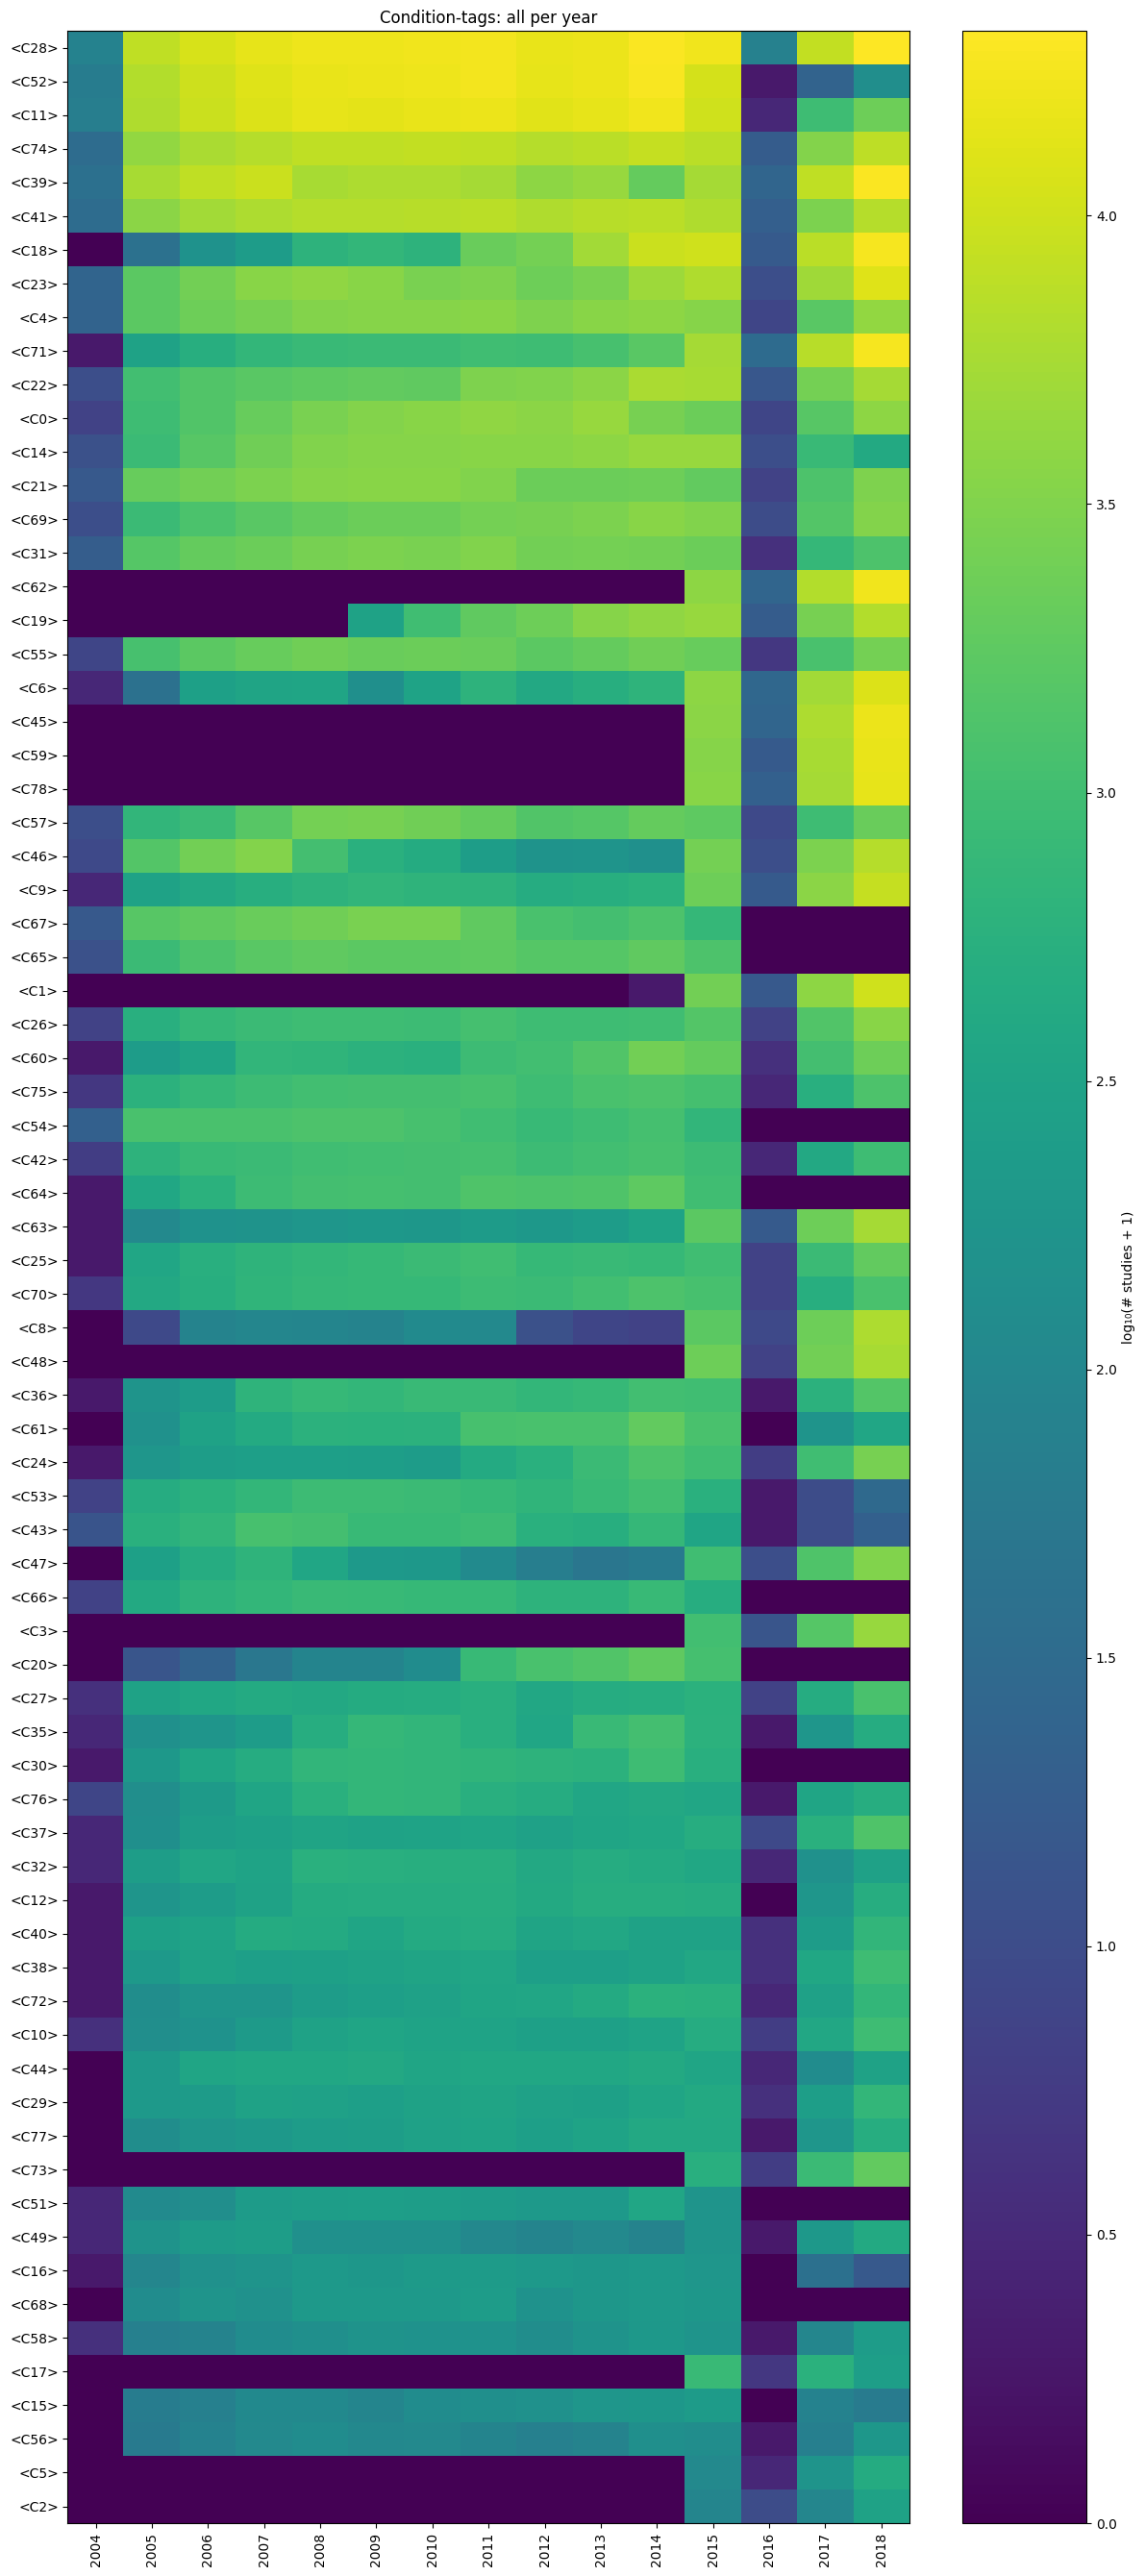

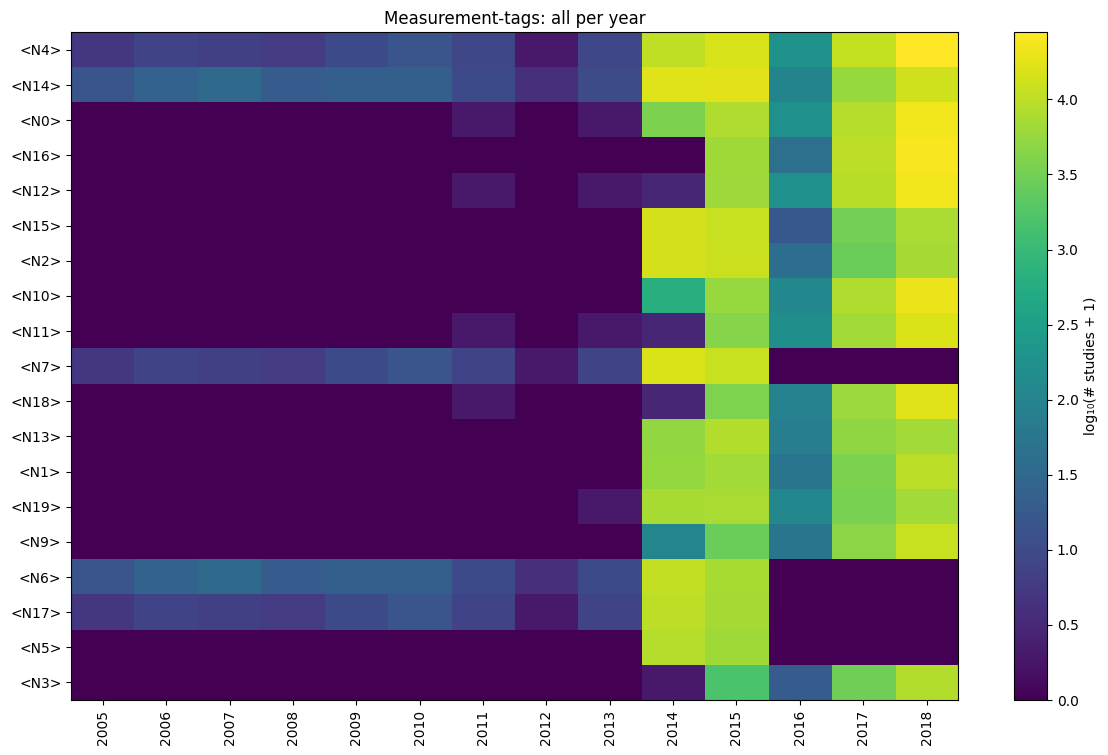

In [419]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ------------------------------------------------------------
# helper for nicer heat-maps
# ------------------------------------------------------------
def plot_tag_heat(counts, title, *, top_k=None, log=False,
                  out=None, dpi=300, show=True):
    """
    counts : DataFrame (rows = years, cols = tags)
    title  : plot title
    top_k  : int | None — keep this many most-common tags; None ⇒ all
    log    : use log10(count+1) colour scale if True
    out    : str | Path | None — file path to save (e.g. "heat.png"); None ⇒ no save
    dpi    : resolution for saved image
    show   : display plot in notebook if True
    """
    tag_totals = counts.sum(axis=0).sort_values(ascending=False)
    keep = tag_totals.head(top_k).index if top_k is not None else tag_totals.index
    mat  = counts[keep].T

    if log:
        mat = np.log10(mat + 1)
        cbar_label = "log₁₀(# studies + 1)"
    else:
        cbar_label = "# studies"

    plt.figure(figsize=(12, 0.35 * len(keep) + 1))
    plt.imshow(mat, aspect="auto", interpolation="nearest", cmap="viridis")
    plt.colorbar(label=cbar_label)
    plt.yticks(range(len(keep)), keep)
    plt.xticks(range(len(counts.index)), counts.index.year, rotation=90)
    plt.title(title)
    plt.tight_layout()

    if out is not None:
        plt.savefig(out, dpi=dpi, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close()


# ------------------------------------------------------------
# build the yearly tables if you haven't already
# ------------------------------------------------------------
def yearly_counts(df, tag_col, date_col="STUDY_DATE"):
    return (
        df[[date_col, tag_col]]
          .explode(tag_col)
          .dropna(subset=[tag_col])
          .assign(year=lambda d: d[date_col].dt.to_period("Y").dt.start_time)
          .groupby(["year", tag_col]).size()
          .unstack(fill_value=0)
          .sort_index()
    )

cond_yearly = yearly_counts(df, "condition_tags")
meas_yearly = yearly_counts(df, "measurement_tags")

# ------------------------------------------------------------
# nicer plots
# ------------------------------------------------------------
plot_tag_heat(cond_yearly,
              title="Condition-tags: all per year",
              log=True,
              out="aws/v1_condition_heatmap.png")

plot_tag_heat(meas_yearly,
              title="Measurement-tags: all per year",
              log=True,
              out="aws/v1_measurement_heatmap.png",   # any Matplotlib-supported format
              top_k=None)                      # explicit for clarity

# New Split

In [476]:
df = union_df.copy()

In [477]:
"""
echo_split_try_best.py   ·   2025-05-07
────────────────────────────────────────
Prerequisite
------------
A DataFrame named `df` already exists.

Outputs
-------
train_df, val_df, test_df  (no file I/O)
Plus an in-memory `issues` dict summarising any constraint we
could not satisfy.
"""

from __future__ import annotations
import pandas as pd, numpy as np
from collections import Counter, defaultdict
import logging, sys

# ╭────────── CONFIG — tune here ──────────╮
MIN_TEST   = 50                     # rows / label in test
MIN_VAL    = 15                     # rows / label in val
MIN_TRAIN  = 50                     # enforce train > test only if train ≥ this
TAG_COLS   = ["condition_tags", "measurement_tags"]
TRAIN_END  = pd.Timestamp("2014-12-31")
VAL_END    = pd.Timestamp("2016-12-31")
RNG_SEED   = 42
# ╰────────────────────────────────────────╯

logging.basicConfig(stream=sys.stdout,
                    format="%(levelname)s: %(message)s",
                    level=logging.INFO)

rng = np.random.default_rng(RNG_SEED)
df  = df.copy()
df["STUDY_DATE"] = pd.to_datetime(df["STUDY_DATE"], errors="coerce")
df = df.drop(columns=[c for c in df.columns if c.startswith("split")],
             errors="ignore")

# ───────── 1 · calendar buckets ─────────
first_dates = (df.groupby("PATIENT_ID", as_index=False)["STUDY_DATE"]
                 .min()
                 .rename(columns={"STUDY_DATE": "first_date"}))

def _bucket(ts):
    if pd.isna(ts) or ts <= TRAIN_END: return "train"
    if ts <= VAL_END:                  return "val"
    return "test"

first_dates["split"] = first_dates["first_date"].apply(_bucket)
df["split"] = df["PATIENT_ID"].map(first_dates.set_index("PATIENT_ID")["split"])

# ───────── helpers ─────────
def pos_counts(frame: pd.DataFrame, col: str) -> Counter:
    c = Counter()
    for tags in frame[col]:
        if isinstance(tags, (list, tuple, set)):
            c.update(tags)
    return c

def patient_rows(pid):
    return df.index[df.PATIENT_ID == pid]

issues: dict[str, list[str]] = defaultdict(list)

# ───────── 2 · balancing loops ─────────
for col in TAG_COLS:
    logging.info(f"─── Balancing {col}")
    # 2A · boost validation to MIN_VAL
    while True:
        val_cnt = pos_counts(df[df.split == "val"], col)
        short   = {t: MIN_VAL - n for t, n in val_cnt.items() if n < MIN_VAL}
        if not short: break
        tag, need = max(short.items(), key=lambda kv: kv[1])

        # candidate patients from train
        cand = (df[(df.split == "train") &
                   (df[col].apply(lambda ts, t=tag:
                                   isinstance(ts, (list, tuple, set)) and t in ts))]
                .PATIENT_ID.drop_duplicates())
        cand = rng.permutation(cand)
        moved = 0
        for pid in cand:
            rows  = patient_rows(pid)
            added = df.loc[rows, col].apply(
                        lambda ts, t=tag: t in ts if isinstance(ts, (list, tuple, set)) else False
                    ).sum()
            if added == 0: continue
            df.loc[rows, "split"] = "val"
            moved += added
            need  -= added
            if need <= 0: break
        if need > 0:
            issues["val_shortfall"].append(tag)
            logging.warning(f"Cannot reach {MIN_VAL} in val for {tag} "
                            f"(missing {need} rows).")
            break

    # 2B · boost test & keep dominance
    while True:
        tr_cnt = pos_counts(df[df.split == "train"], col)
        va_cnt = pos_counts(df[df.split == "val"  ], col)
        te_cnt = pos_counts(df[df.split == "test" ], col)

        # rows needed for MIN_TEST
        need = MIN_TEST - te_cnt.get(tag, 0)
        # extra rows needed so train > test (only if train ≥ MIN_TRAIN)
        dom_extra = 0
        if tr_cnt.get(tag, 0) >= MIN_TRAIN and te_cnt.get(tag, 0) >= tr_cnt.get(tag, 0):
            dom_extra = te_cnt[tag] - tr_cnt[tag] + 1
            need = max(need, dom_extra)

        if need <= 0: break       # done for this tag

        # prefer patients from val, then train
        satisfied = False
        for src in ("val", "train"):
            if satisfied: break
            pids = (df[(df.split == src) &
                       (df[col].apply(lambda ts, t=tag:
                                       isinstance(ts, (list, tuple, set)) and t in ts))]
                    .PATIENT_ID.drop_duplicates())
            pids = rng.permutation(pids)
            for pid in pids:
                rows  = patient_rows(pid)
                added = df.loc[rows, col].apply(
                            lambda ts, t=tag: t in ts if isinstance(ts, (list, tuple, set)) else False
                        ).sum()
                if added == 0: continue

                # if moving from train, check dominance constraint
                if src == "train" and tr_cnt[tag] >= MIN_TRAIN:
                    if tr_cnt[tag] - added < te_cnt[tag] + added:
                        continue  # skip – would violate train > test

                df.loc[rows, "split"] = "test"
                need      -= added
                te_cnt[tag] += added
                if src == "train":
                    tr_cnt[tag] -= added
                satisfied = need <= 0
                if satisfied: break

        if not satisfied:
            issues["test_shortfall"].append(tag)
            logging.warning(f"{tag}: couldn't satisfy "
                            f"(need {max(need,0)} more rows).")
            break

# ───────── 3 · leakage check ─────────
assert (df.groupby("PATIENT_ID")["split"].nunique() == 1).all(), "Patient leakage!"

# ───────── 4 · final DataFrames ─────────
train_df = df[df.split == "train"].copy()
val_df   = df[df.split == "val"  ].copy()
test_df  = df[df.split == "test" ].copy()

logging.info("Rows per split: %s",
             {k: v.shape[0] for k, v in
              {"train": train_df, "val": val_df, "test": test_df}.items()})

if issues:
    logging.warning("Unresolved constraints: %s", dict(issues))
else:
    logging.info("All constraints satisfied 🎉")


INFO: ─── Balancing condition_tags
INFO: ─── Balancing measurement_tags
INFO: Rows per split: {'train': 230154, 'val': 8022, 'test': 27832}


In [482]:
len(df)

266008

In [487]:
df.iloc[0:3][["DeidentifiedStudyID", "s3_key", "study_dir", "split"]]

,DeidentifiedStudyID,s3_key,study_dir,split
0,1.2.276.0.7230010.3.1.2.845494328.1.1703364833.18441940,echo-study/1.2.276.0.7230010.3.1.2.845494328.1.1703364833.18441940/,echo-study,train
1,1.2.276.0.7230010.3.1.2.845494328.1.1703319042.17124420,echo-study/1.2.276.0.7230010.3.1.2.845494328.1.1703319042.17124420/,echo-study,train
2,1.2.276.0.7230010.3.1.2.811753780.1.1704934493.17980520,echo-study-1/1.2.276.0.7230010.3.1.2.811753780.1.1704934493.17980520/,echo-study-1,train


In [484]:
df.to_csv('aws/hsl_master_v2.csv')

In [481]:
train_df.to_csv('aws/hsl_train_v2.csv')
val_df.to_csv('aws/hsl_val_v2.csv')
test_df.to_csv('aws/hsl_test_v2.csv')

In [478]:
import pandas as pd
from collections import defaultdict

# ─────────────────────────────────────────────────────────────
# helper – turn a column of lists into a tidy count Series
# ─────────────────────────────────────────────────────────────
def tag_counts(df: pd.DataFrame, col: str) -> pd.Series:
    """
    Parameters
    ----------
    df  : split dataframe (train / val / test)
    col : name of the list-of-tags column, e.g. 'condition_tags'
    """
    return (
        df[col]
          .explode()              # one tag per row
          .dropna()               # in case some rows are {}
          .value_counts()         # absolute counts
          .sort_index()
    )

# ─────────────────────────────────────────────────────────────
# build a summary table for each tag column
# ─────────────────────────────────────────────────────────────
summary = defaultdict(pd.DataFrame)
for tag_col in ["condition_tags", "measurement_tags"]:
    summary[tag_col] = (
        pd.concat(
            [
                tag_counts(train_df, tag_col).rename("train"),
                tag_counts(val_df,   tag_col).rename("val"),
                tag_counts(test_df,  tag_col).rename("test"),
            ],
            axis=1,
        )
        .fillna(0).astype(int)           # tags absent in a split → 0
        .assign(
            train_pct=lambda d: d.train / d.train.sum() * 100,
            val_pct  =lambda d: d.val   / d.val.sum()   * 100,
            test_pct =lambda d: d.test  / d.test.sum()  * 100,
        )
        .round(2)
        .sort_values("train", ascending=False)   # most common tags first
    )

In [479]:
summary["condition_tags"].to_csv('aws/split5_condition.csv')
summary["condition_tags"]

,train,val,test,train_pct,val_pct,test_pct
condition_tags,,,,,,
<C28>,171286,6032,20565,11.99,11.57,7.52
<C52>,148295,4058,819,10.38,7.79,0.30
<C11>,138550,4160,2728,9.70,7.98,1.00
<C74>,81666,2360,6688,5.72,4.53,2.45
<C41>,72663,1941,5912,5.09,3.72,2.16
<C39>,70729,1094,18837,4.95,2.10,6.89
<C23>,40096,2065,13315,2.81,3.96,4.87
<C18>,37949,3121,17043,2.66,5.99,6.23
<C4>,35700,1103,3374,2.50,2.12,1.23


In [480]:
summary["measurement_tags"].to_csv('aws/split5 _measurement.csv')
summary["measurement_tags"]

,train,val,test,train_pct,val_pct,test_pct
measurement_tags,,,,,,
<N14>,35223,6157,12743,10.55,12.16,6.06
<N4>,34002,4824,26233,10.18,9.53,12.48
<N15>,25938,4538,7029,7.77,8.96,3.34
<N2>,25465,4448,6678,7.63,8.79,3.18
<N7>,22473,4454,740,6.73,8.80,0.35
<N0>,20243,2599,20190,6.06,5.13,9.61
<N16>,17215,1554,23124,5.16,3.07,11.00
<N19>,15531,2780,7194,4.65,5.49,3.42
<N6>,15155,2797,476,4.54,5.53,0.23


# Old Split

In [911]:
# ================================================================
# Echocardiogram leak-safe splitter  (v2025-05-06 “75-15-10”)
# ================================================================
import pandas as pd, numpy as np, ast, logging
from collections.abc import Iterable
from typing import Any, Dict, List, Set, Tuple

logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s - %(levelname)s - %(message)s")
logger = logging.getLogger(__name__)

# ------------ user-tunable targets --------------------------------
TEST_FRAC_TARGET   = 0.10   # desired final %
VAL_FRAC_TARGET    = 0.10
TRAIN_FRAC_TARGET  = 0.80
# ------------ original thresholds ---------------------------------
TEST_FRAC_CUTOFF   = 0.08   # newest 8 % define *initial* test boundary
VAL_FRAC_INITIAL   = 0.08   # initial val sampling fraction
MIN_TRAIN, MIN_VAL, MIN_TEST = 300, 100, 0
MIN_TRAIN_FOR_RARE, MIN_VAL_FOR_RARE = 350, 80
MAX_TEST_TRAIN_SKEW = 3.0
MAX_BLEED_FRACTION  = 0.12
ALLOW_CHRON_OVERLAP = True
AVOID_PATIENT_OVERLAP = True
TAG_COLS = ["condition_tags", "measurement_tags"]
HEAVILY_SKEWED_CONDITION_TAGS  = ["<C45>", "<C62>", "<C59>", "<C78>", "<C1>",
                                  "<C48>"]
HEAVILY_SKEWED_MEASUREMENT_TAGS = ["<N10>", "<N12>", "<N11>", "<N18>",
                                   "<N16>", "<N3>"]

RNG = np.random.default_rng(42)   # reproducibility

# ================================================================
# ❶ helper utilities (unchanged except tiny notes)
# ================================================================
def to_list(x: Any) -> List:
    if isinstance(x, list):
        return x
    if pd.isna(x) or str(x).strip() in {"", "[]", "{}"}:
        return []
    if isinstance(x, str):
        try:
            v = ast.literal_eval(x)
            if isinstance(v, Iterable) and not isinstance(v, str):
                return list(v)
        except (ValueError, SyntaxError):
            pass
        return [t.strip() for t in x.strip("[]").split(",") if t.strip()]
    if isinstance(x, Iterable):
        return list(x)
    return []

def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for c in TAG_COLS:
        df[c] = df.get(c, [[]] * len(df)).apply(to_list)
    if "STUDY_DATE" not in df or "PATIENT_ID" not in df:
        raise KeyError("DataFrame must contain STUDY_DATE & PATIENT_ID")
    df["STUDY_DATE"] = pd.to_datetime(df["STUDY_DATE"])
    df["PATIENT_ID"] = df["PATIENT_ID"].astype(str)
    return df.sort_values("STUDY_DATE").reset_index(drop=True)

def study_table(f: pd.DataFrame) -> pd.DataFrame:
    return (f.groupby("DeidentifiedStudyID", sort=False)
             .agg({"STUDY_DATE": "first",
                   "PATIENT_ID": "first",
                   **{c: "first" for c in TAG_COLS}})
             .reset_index())

def tag_counts(f: pd.DataFrame, col: str) -> pd.Series:
    return f[col].explode().value_counts()

def min_tag(f: pd.DataFrame, col: str) -> int:
    vc = tag_counts(f, col)
    return 0 if vc.empty else vc.min()

def tags_in_row(row) -> Set[str]:
    return set().union(*[set(row[c]) for c in TAG_COLS])

# ----- patient helpers -------------------------------------------
def _all_studies_of_patients(ids: Set[str], df: pd.DataFrame) -> Set[str]:
    pats = set(df.loc[df.DeidentifiedStudyID.isin(ids), "PATIENT_ID"])
    return set(df.loc[df.PATIENT_ID.isin(pats), "DeidentifiedStudyID"])

def _patients_to_move(df_from: pd.DataFrame, n: int,
                      oldest_first: bool = True) -> Set[str]:
    """Return *study IDs* for the first `n` patients by oldest/youngest."""
    if n <= 0 or df_from.empty:
        return set()
    sort = df_from.sort_values("STUDY_DATE", ascending=oldest_first)
    pats = sort["PATIENT_ID"].drop_duplicates().head(n)
    return set(df_from.loc[df_from.PATIENT_ID.isin(pats), "DeidentifiedStudyID"])

# ================================================================
# ❷ bleeding & rare-tag helpers (identical to your last version,
#    with the KeyError patch already in get_tag_deficient_studies)
# ================================================================
# .....  (to save vertical space the internal helpers are the same
#         as the previous message – nothing changed there) .....
# >>> COPY FROM THE PREVIOUS “fixed KeyError” CODE FOR:
#     • calculate_tag_distributions
#     • get_tag_deficient_studies (patched)
#     • bleed
#     • ensure_val_representation
# ================================================================
# ↓↓↓ keep exactly as in previous snippet ↓↓↓
# (for brevity here, assume they are included verbatim)
# ================================================================
# ================================================================
# ❺ rare-tag helpers
# ------------------------------------------------
def calculate_tag_distributions(train_df, val_df, test_df):
    res = {}
    for col in TAG_COLS:
        res[col] = {}
        t_c = tag_counts(train_df, col); v_c = tag_counts(val_df, col); s_c = tag_counts(test_df, col)
        sz_t, sz_v, sz_s = map(len, (train_df, val_df, test_df))
        for tag in set(t_c.index) | set(v_c.index) | set(s_c.index):
            t, v, s = t_c.get(tag, 0), v_c.get(tag, 0), s_c.get(tag, 0)
            tp = t / sz_t * 100 if sz_t else 0
            vp = v / sz_v * 100 if sz_v else 0
            sp = s / sz_s * 100 if sz_s else 0
            ratio = sp / tp if tp else float("inf")
            res[col][tag] = dict(train=t, val=v, test=s,
                                 train_pct=tp, val_pct=vp, test_pct=sp,
                                 test_train_ratio=ratio)
    return res

def get_tag_deficient_studies(df: pd.DataFrame,
                              tags_to_add: Dict[str, int],
                              min_count: int,
                              tag_counts_dict: Dict[str, int] | None = None,
                              expand_patients: bool = True) -> Tuple[Set[str], Dict[str, int]]:
    """Greedy study selection to satisfy tag floors (patched for KeyError)."""
    if not tags_to_add:
        return set(), tag_counts_dict or {}

    tag_counts = tag_counts_dict or {t: 0 for t in tags_to_add}
    need = {t: min_count - tag_counts.get(t, 0) for t in tags_to_add}
    need = {t: n for t, n in need.items() if n > 0}
    if not need:
        return set(), tag_counts

    scored = []
    for _, row in study_table(df).iterrows():
        inter = tags_in_row(row) & need.keys()
        if inter:
            scored.append((row.DeidentifiedStudyID, inter,
                           sum(need[t] for t in inter)))
    scored.sort(key=lambda x: x[2], reverse=True)

    chosen: Set[str] = set()
    for sid, inter, _ in scored:
        if not need:
            break
        if sid in chosen:
            continue
        chosen.add(sid)
        for t in inter:
            if t in need:             #  ❗ PATCH – ensure key exists
                need[t] -= 1
                if need[t] <= 0:
                    need.pop(t, None)

    if expand_patients and AVOID_PATIENT_OVERLAP:
        chosen = _expand_to_patient_studies(chosen, df)

    # update tag_counts
    for sid in chosen:
        row = df.loc[df.DeidentifiedStudyID == sid].iloc[0]
        for c in TAG_COLS:
            for t in row[c]:
                if t in tag_counts:
                    tag_counts[t] += 1
    return chosen, tag_counts


def bleed(source_df: pd.DataFrame,
          target_ids: Set[str],
          floor: int,
          direction: str,
          max_fraction: float = MAX_BLEED_FRACTION):
    """Move studies until each tag ≥ floor in target."""
    global df, ALL_TAGS
    if source_df.empty:
        return target_ids, set()

    tgt_df = df[df.DeidentifiedStudyID.isin(target_ids)]
    need = {}
    for col in TAG_COLS:
        counts = tag_counts(tgt_df, col)
        for t in ALL_TAGS[col]:
            miss = floor - counts.get(t, 0)
            if miss > 0:
                need[t] = miss
    if not need:
        return target_ids, set()

    ordered = source_df.sort_values("STUDY_DATE",
                                    ascending=(direction == "forward"))
    limit = int(len(source_df) * max_fraction)
    moved = set()

    for _, row in ordered.iterrows():
        if not need or len(moved) >= limit:
            break
        sid = row.DeidentifiedStudyID
        if sid in target_ids:
            continue
        tags = tags_in_row(row) & need.keys()
        if tags:
            cand_ids = _expand_to_patient_studies({sid}, df) if AVOID_PATIENT_OVERLAP else {sid}
            for cid in cand_ids:
                if cid in target_ids or len(moved) >= limit:
                    continue
                moved.add(cid)
                for t in tags_in_row(df.loc[df.DeidentifiedStudyID == cid].iloc[0]) & need.keys():
                    need[t] -= 1
                    if need[t] <= 0:
                        need.pop(t, None)
                if not need:
                    break

    return target_ids | moved, moved

def ensure_val_representation(test_df, val_df, skewed_tags, min_count):
    val_counts = {t: 0 for t in skewed_tags}
    for col in TAG_COLS:
        vc = tag_counts(val_df, col)
        for t in skewed_tags:
            val_counts[t] = max(val_counts[t], vc.get(t, 0))
    need = {t: c for t, c in val_counts.items() if c < min_count}
    if not need:
        return set()
    move_ids, _ = get_tag_deficient_studies(test_df, need,
                                            min_count, val_counts)
    return move_ids

# ================================================================
# ❸ splitter with final re-balance
# ================================================================
def create_train_val_test_split(union_df: pd.DataFrame, verbose=True):
    global df, ALL_TAGS
    df = preprocess(union_df)
    ALL_TAGS = {c: set(df[c].explode().dropna().unique()) for c in TAG_COLS}

    # ------------------------------------------------ 1. initial TEST (chronological)
    stu = study_table(df)
    cut = int(len(stu) * (1 - TEST_FRAC_CUTOFF))
    base_test = set(stu.iloc[cut:]["DeidentifiedStudyID"])
    test_ids = _all_studies_of_patients(base_test, df) if AVOID_PATIENT_OVERLAP else base_test
    test_df  = df[df.DeidentifiedStudyID.isin(test_ids)]
    trainval = df[~df.DeidentifiedStudyID.isin(test_ids)]
    boundary = stu.iloc[cut - 1]["STUDY_DATE"]

    # ------------------------------------------------ 2. stratified VALIDATION (same logic as before)
    tv = study_table(trainval)
    skewed = set(HEAVILY_SKEWED_CONDITION_TAGS + HEAVILY_SKEWED_MEASUREMENT_TAGS)
    tv["m"], tv["c"] = tv["measurement_tags"].apply(bool), tv["condition_tags"].apply(bool)
    tv["r"] = tv.apply(lambda r: bool(tags_in_row(r) & skewed), axis=1)
    tv["grp"] = tv["m"].astype(int).astype(str) + tv["c"].astype(int).astype(str) + tv["r"].astype(int).astype(str)

    val_ids = set()
    for g, sub in tv.groupby("grp"):
        frac = VAL_FRAC_INITIAL * (1.5 if g.endswith("1") else 1.0)
        k = int(len(sub) * frac)
        if k:
            val_ids.update(RNG.choice(sub.DeidentifiedStudyID, k, replace=False))
    if AVOID_PATIENT_OVERLAP:
        val_ids = _all_studies_of_patients(val_ids, trainval)

    val_df   = trainval[trainval.DeidentifiedStudyID.isin(val_ids)]
    train_df = trainval[~trainval.DeidentifiedStudyID.isin(val_ids)]

    # step 3 – bleed train → val
    _, moved = bleed(study_table(train_df), val_ids, MIN_VAL, "forward")
    if moved:
        train_df = train_df[~train_df.DeidentifiedStudyID.isin(moved)]
        val_df   = pd.concat([val_df, df[df.DeidentifiedStudyID.isin(moved)]])

    # step 4 – bleed test → train to meet MIN_TRAIN
    train_ids, moved_min = bleed(study_table(test_df),
                                 set(train_df.DeidentifiedStudyID),
                                 MIN_TRAIN, "back", 0.05)
    if moved_min:
        test_df  = test_df[~test_df.DeidentifiedStudyID.isin(moved_min)]
        train_df = pd.concat([train_df, df[df.DeidentifiedStudyID.isin(moved_min)]])

    # step 5 – rare tags in validation
    moved_val = ensure_val_representation(test_df, val_df, skewed, MIN_VAL_FOR_RARE)
    if moved_val:
        val_df   = pd.concat([val_df, df[df.DeidentifiedStudyID.isin(moved_val)]])
        test_df  = test_df[~test_df.DeidentifiedStudyID.isin(moved_val)]

    # step 6 – boost skewed tags into train
    dist = calculate_tag_distributions(train_df, val_df, test_df)
    to_boost = {}
    for tag in skewed:
        for col in TAG_COLS:
            if tag in dist[col]:
                d = dist[col][tag]
                if d["train"] > 0 and d["test_train_ratio"] > MAX_TEST_TRAIN_SKEW:
                    tgt = max(MIN_TRAIN_FOR_RARE, int(d["train"] * 1.2))
                    if d["train"] < tgt:
                        to_boost[tag] = tgt
    if to_boost:
        train_ct = {t: tag_counts(train_df, c).get(t, 0) for c in TAG_COLS for t in to_boost}
        boost_ids, _ = get_tag_deficient_studies(test_df, to_boost,
                                                 MIN_TRAIN_FOR_RARE, train_ct)
        cap = int(len(test_df) * 0.07)
        boost_ids = set(list(boost_ids)[:cap])
        if boost_ids:
            train_df = pd.concat([train_df, df[df.DeidentifiedStudyID.isin(boost_ids)]])
            test_df  = test_df[~test_df.DeidentifiedStudyID.isin(boost_ids)]

    # === 7. enforce patient exclusivity (unchanged) ===============
    if AVOID_PATIENT_OVERLAP:
        train_df, val_df, test_df = enforce_patient_exclusivity(train_df, val_df, test_df)

    # === 8. FINAL RE-BALANCE (one-pass, no recursion) ===============

    def _tag_counts(frame: pd.DataFrame) -> Dict[str, Dict[str, int]]:
        out = {c: tag_counts(frame, c).to_dict() for c in TAG_COLS}
        return out
    
    def _patient_ok_to_move(p_tag_cnt: Dict[str, Dict[str, int]],
                            val_tag_cnt: Dict[str, Dict[str, int]]) -> bool:
        """True if moving this patient keeps every tag ≥ MIN_VAL in val."""
        for col in TAG_COLS:
            for t, n in p_tag_cnt[col].items():
                if val_tag_cnt[col].get(t, 0) - n < MIN_VAL:
                    return False
        return True

    def _collect_patient_counts(group: pd.DataFrame) -> Dict[str, Dict[str, int]]:
        """Return {col -> {tag: count}} for a patient group."""
        res = {c: {} for c in TAG_COLS}
        for col in TAG_COLS:
            vc = tag_counts(group, col)
            res[col] = vc.to_dict()
        return res
    
    # current sizes
    total = len(train_df) + len(val_df) + len(test_df)
    want_train = int(total * TRAIN_FRAC_TARGET)
    
    # -------- a) move from VAL → TRAIN --------------------------------
    if len(train_df) < want_train and not val_df.empty:
        val_tag_cnt = _tag_counts(val_df)
        # patients ordered oldest first
        for pid, grp in val_df.sort_values("STUDY_DATE").groupby("PATIENT_ID"):
            if len(train_df) >= want_train or len(val_df) <= int(total * VAL_FRAC_TARGET):
                break
            p_cnt = _collect_patient_counts(grp)
            if _patient_ok_to_move(p_cnt, val_tag_cnt):
                # move
                train_df = pd.concat([train_df, grp])
                val_df   = val_df.drop(grp.index)
                # update val_tag_cnt
                for col in TAG_COLS:
                    for t, n in p_cnt[col].items():
                        val_tag_cnt[col][t] -= n
    
    # -------- b) move from TEST → TRAIN --------------------------------
    if len(train_df) < want_train and not test_df.empty:
        # keep test ≥ 10 % of total
        min_test_rows = int(total * TEST_FRAC_TARGET)
        for pid, grp in test_df.sort_values("STUDY_DATE").groupby("PATIENT_ID"):
            if len(train_df) >= want_train or len(test_df) <= min_test_rows:
                break
            train_df = pd.concat([train_df, grp])
            test_df  = test_df.drop(grp.index)
    
    # === 9. report (unchanged) ========================================
    total = len(train_df) + len(val_df) + len(test_df)
    for n, d in (("train", train_df), ("val", val_df), ("test", test_df)):
        logger.info(f"{n:<5}: rows={len(d):>7,}  studies={d.DeidentifiedStudyID.nunique():>7,}  "
                    f"patients={d.PATIENT_ID.nunique():>7,}  "
                    f"min_cond={min_tag(d,'condition_tags'):>3}  "
                    f"min_meas={min_tag(d,'measurement_tags'):>3}")
    logger.info("fractions train/val/test: "
                f"{len(train_df)/total:.2%} | "
                f"{len(val_df)/total:.2%} | "
                f"{len(test_df)/total:.2%}")



    return (train_df.reset_index(drop=True),
            val_df.reset_index(drop=True),
            test_df.reset_index(drop=True))

# ================================================================
# usage example
# ------------------------------------------------
# train_df, val_df, test_df = create_train_val_test_split(union_df, verbose=True)


In [912]:
train_df, val_df, test_df = create_train_val_test_split(union_df, verbose=True)

2025-05-06 12:20:25,518 - INFO - train: rows=158,746  studies=158,746  patients= 83,235  min_cond=657  min_meas=809
2025-05-06 12:20:25,545 - INFO - val  : rows= 19,842  studies= 19,842  patients=  6,897  min_cond= 85  min_meas= 83
2025-05-06 12:20:25,577 - INFO - test : rows= 19,845  studies= 19,845  patients=  7,204  min_cond=175  min_meas=439
2025-05-06 12:20:25,578 - INFO - fractions train/val/test: 80.00% | 10.00% | 10.00%


In [913]:
# ---------------------------------------------------------------
# 7 · show the lowest-frequency tags in each split
# ---------------------------------------------------------------
# def lowest_tags(frame, col, k=10):
#     """Return a DataFrame of the k least-common tags in `col`."""
#     vc = (frame[col]
#             .explode()
#             .value_counts()
#             .sort_values())           # ascending
#     return vc.head(k).rename_axis("tag").to_frame("count")

# for split_name, split_df in [("train", train_df),
#                              ("val",   val_df),
#                              ("test",  test_df)]:
#     print(f"\n── {split_name.upper()} : condition_tags (lowest {10}) ──")
#     display(lowest_tags(split_df, "condition_tags"))
    
#     print(f"── {split_name.upper()} : measurement_tags (lowest {10}) ──")
#     display(lowest_tags(split_df, "measurement_tags"))


In [434]:
import pandas as pd
from collections import defaultdict

# ─────────────────────────────────────────────────────────────
# helper – turn a column of lists into a tidy count Series
# ─────────────────────────────────────────────────────────────
def tag_counts(df: pd.DataFrame, col: str) -> pd.Series:
    """
    Parameters
    ----------
    df  : split dataframe (train / val / test)
    col : name of the list-of-tags column, e.g. 'condition_tags'
    """
    return (
        df[col]
          .explode()              # one tag per row
          .dropna()               # in case some rows are {}
          .value_counts()         # absolute counts
          .sort_index()
    )

# ─────────────────────────────────────────────────────────────
# build a summary table for each tag column
# ─────────────────────────────────────────────────────────────
summary = defaultdict(pd.DataFrame)
for tag_col in ["condition_tags", "measurement_tags"]:
    summary[tag_col] = (
        pd.concat(
            [
                tag_counts(train_df, tag_col).rename("train"),
                tag_counts(val_df,   tag_col).rename("val"),
                tag_counts(test_df,  tag_col).rename("test"),
            ],
            axis=1,
        )
        .fillna(0).astype(int)           # tags absent in a split → 0
        .assign(
            train_pct=lambda d: d.train / d.train.sum() * 100,
            val_pct  =lambda d: d.val   / d.val.sum()   * 100,
            test_pct =lambda d: d.test  / d.test.sum()  * 100,
        )
        .round(2)
        .sort_values("train", ascending=False)   # most common tags first
    )

In [915]:
summary["condition_tags"]

,train,val,test,train_pct,val_pct,test_pct
condition_tags,,,,,,
<C28>,119209,14165,13854,12.90,12.64,11.28
<C52>,108968,12772,12116,11.79,11.40,9.86
<C11>,101129,11971,11359,10.94,10.69,9.25
<C74>,55914,7193,6889,6.05,6.42,5.61
<C41>,50479,5909,5554,5.46,5.27,4.52
<C39>,44113,5082,4099,4.77,4.54,3.34
<C23>,26313,3046,3948,2.85,2.72,3.21
<C14>,24890,2411,2457,2.69,2.15,2.00
<C4>,24598,2776,2741,2.66,2.48,2.23


In [916]:
summary["measurement_tags"]

,train,val,test,train_pct,val_pct,test_pct
measurement_tags,,,,,,
<N14>,21900,2185,8769,13.60,14.10,12.79
<N7>,18759,1931,6960,11.65,12.46,10.15
<N15>,17948,1723,7041,11.14,11.12,10.27
<N2>,17857,1759,6783,11.09,11.35,9.89
<N4>,15085,1404,6591,9.37,9.06,9.61
<N6>,12584,1340,4486,7.81,8.65,6.54
<N17>,11776,1225,4244,7.31,7.91,6.19
<N19>,9595,910,4073,5.96,5.87,5.94
<N1>,7915,772,3220,4.91,4.98,4.70


In [917]:
train_df.to_csv('aws/hls_160K_train.csv')
val_df.to_csv('aws/hls_20K_val.csv')
test_df.to_csv('aws/hls_20K_test.csv')

# Inspect

In [2]:
import pandas as pd
import os
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

In [4]:
full_dataset = pd.read_csv('aws/hsl_master_v2.csv')

In [9]:
full_dataset.shape

(266008, 14)

In [31]:
# full_dataset.head(1)

In [18]:
# rows whose measurement_tags list is non-empty
import ast

def to_list(obj):
    try:
        return ast.literal_eval(obj) if isinstance(obj, str) else obj
    except Exception:
        return []          # fallback for malformed strings

full_dataset["measurement_tags"] = full_dataset["measurement_tags"].apply(to_list)

# now keep rows where the list is

non_empty_msmt = full_dataset[full_dataset["measurement_tags"].astype(bool)]
print(non_empty_msmt.shape)

(81270, 14)


In [54]:
non_empty_msmt.iloc[0:20][["DeidentifiedStudyID", "measurement_tokens"]]

,DeidentifiedStudyID,measurement_tokens
411,1.2.276.0.7230010.3.1.2.845494328.1.1703323865.17220700,"['<N17> 550.4', '<N4> 18.3', '<N6> 17.9', '<N7> 470.5']"
1615,1.2.276.0.7230010.3.1.2.859333938.1.1703365046.12872194,['<N6> 63.1']
2355,1.2.276.0.7230010.3.1.2.1714512485.1.1703595892.19023282,"['<N14> 69.1', '<N6> 59']"
2615,1.2.276.0.7230010.3.1.2.811753780.1.1703657425.16337210,['<N6> 16.3']
3790,1.2.276.0.7230010.3.1.2.1714512485.1.1703331949.14732693,['<N6> 68.5']
4833,1.2.276.0.7230010.3.1.2.811753780.1.1703658156.16347748,['<N6> 28.2']
7911,1.2.276.0.7230010.3.1.2.845494328.1.1703597442.21523933,"['<N14> 70.6', '<N6> 77']"
8053,1.2.276.0.7230010.3.1.2.1714512485.1.1703601095.19074949,['<N6> 46.3']
8267,1.2.276.0.7230010.3.1.2.1714512485.1.1704948275.21692352,"['<N17> 167.3', '<N4> 20.3', '<N6> 36.3', '<N7> 145.3']"
8286,1.2.276.0.7230010.3.1.2.1714578744.1.1703597586.15715729,['<N6> 53.6']


In [57]:
non_empty_msmt.shape

(81270, 14)

In [105]:
full_dataset.shape

(266008, 17)

# Deduplicate

In [32]:
full_dataset = pd.read_csv('aws/hsl_master_v2.csv')
full_dataset.shape

(266008, 14)

In [33]:
import pandas as pd, ast, re, statistics

# ── 1 · load full dataframe ────────────────────────────────────────────
df = full_dataset.copy()

# ── 2 · helpers ────────────────────────────────────────────────────────
NUM_RE = re.compile(r"^-?\d+(\.\d+)?([eE][-+]?\d+)?$")

def is_scalar_na(x):
    return x is None or (pd.api.types.is_scalar(x) and pd.isna(x))

def to_py(x):
    """safe literal-eval that returns a Python list or the original obj"""
    if is_scalar_na(x):
        return []
    if isinstance(x, (list, tuple)):
        return list(x)
    try:
        return ast.literal_eval(x) if isinstance(x, str) else x
    except Exception:
        return []

# ── 3 · de-duplication rule-set (extend if you add new <N*> tags) ─────
DEDUP_RULE = {
    # haemodynamic “severity” → keep highest
    "<N0>": "high",   # AV Vmax
    "<N1>": "high",   # AV mean gradient
    "<N14>": "high",  # RVSP
    "<N10>": "high",  # LVOT peak gradient (worst)
    # indexed or “smaller is healthier” → keep lowest
    "<N5>": "low",    # LVEDVi
    "<N6>": "low",    # LVESVi
    "<N7>": "low",    # LVMi
    "<N17>": "low",   # LAVi
    # classic dual-plane EF → mean of 2-CH + 4-CH
    "<N4>": "mean",   # LVEF
    # low-noise waveform metrics → mean if duplicated
    "<N9>":  "mean",  # LVOT VTI
    "<N11>": "mean",  # Decel-time
    # anything else → take the final (usually the reader override)
    # e.g. N12, N13, N15, N16, N18, N19 ...
}


def dedup_measurement_tokens(tokens):
    """
    tokens  : list[str]  e.g. ['<N4> 55.1','<N4> 52.0','<N7> 180','<N7> 102']
    returns : list[str]  (≤1 token per tag, deterministic order)
    """
    bucket, first_order = {}, []

    for tok in tokens:
        if not (tok.startswith("<N") and " " in tok):
            continue
        tag, val = tok.split(maxsplit=1)
        if not NUM_RE.fullmatch(val.strip()):
            continue
        bucket.setdefault(tag, []).append(float(val))
        if tag not in first_order:
            first_order.append(tag)

    cleaned = []
    for tag in first_order:
        vals = bucket[tag]
        rule = DEDUP_RULE.get(tag, "last")
        if rule == "high":
            choice = max(vals)
        elif rule == "low":
            choice = min(vals)
        elif rule == "mean":
            choice = statistics.mean(vals)
        else:
            choice = vals[-1]                        # "last"
        fmt = "{:.1f}" if any("." in str(v) for v in vals) else "{:.0f}"
        cleaned.append(f"{tag} {fmt.format(choice)}")

    return cleaned

def dedup_condition_tags(tags):
    """remove duplicates while preserving original order"""
    seen, out = set(), []
    for t in tags:
        if t not in seen:
            out.append(t)
            seen.add(t)
    return out

def has_duplicate_measure_tags(tokens):
    tags = [tok.split(maxsplit=1)[0] for tok in tokens if tok.startswith("<N")]
    return len(tags) != len(set(tags))

def has_duplicate_cond_tags(tags):
    return len(tags) != len(set(tags))


# ── 4 · duplicate counts BEFORE cleaning ──────────────────────────────
meas_before = df["measurement_tokens"].apply(lambda x: has_duplicate_measure_tags(to_py(x))).sum()
cond_before = df["condition_tags"].apply(lambda x: has_duplicate_cond_tags(to_py(x))).sum()
print(f"Rows with duplicate measurement tokens BEFORE : {meas_before:,}")
print(f"Rows with duplicate condition tags BEFORE     : {cond_before:,}")

# ── 5 · apply de-duplication & store in new columns ───────────────────
df["measurement_tokens_dedup"] = df["measurement_tokens"].apply(lambda x: dedup_measurement_tokens(to_py(x)))
df["condition_tags_dedup"]     = df["condition_tags"].apply(lambda x: dedup_condition_tags(to_py(x)))

# ── 6 · duplicate counts AFTER cleaning ───────────────────────────────
meas_after = df["measurement_tokens_dedup"].apply(has_duplicate_measure_tags).sum()
cond_after = df["condition_tags_dedup"].apply(has_duplicate_cond_tags).sum()
print(f"Rows with duplicate measurement tokens AFTER  : {meas_after:,}")
print(f"Rows with duplicate condition tags AFTER      : {cond_after:,}")

# (Optional) save the cleaned dataframe
# df.to_csv("/mnt/data/report_subset_dedup.csv", index=False)


Rows with duplicate measurement tokens BEFORE : 33,421
Rows with duplicate condition tags BEFORE     : 0
Rows with duplicate measurement tokens AFTER  : 0
Rows with duplicate condition tags AFTER      : 0


In [104]:
full_dataset.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'REP_ID', 'findings', 'measurements',
       'condition_tags', 'measurement_tags', 'measurement_tokens',
       'DeidentifiedStudyID', 'StudyRef', 'STUDY_DATE', 'PATIENT_ID', 's3_key',
       'study_dir', 'split', 'measurement_tokens_dedup',
       'condition_tags_dedup'],
      dtype='object')

In [37]:
df.loc[df['DeidentifiedStudyID'] == '1.2.276.0.7230010.3.1.2.811753780.1.1703762181.17487612'][['DeidentifiedStudyID', 'measurement_tokens', 'measurement_tokens_dedup']]

,DeidentifiedStudyID,measurement_tokens,measurement_tokens_dedup
227038,1.2.276.0.7230010.3.1.2.811753780.1.1703762181.17487612,"['<N0> 1.33', '<N0> 1.36', '<N0> 1.37', '<N0> 1.39', '<N10> 4.84', '<N11> 201.7', '<N11> 223.8', '<N11> 245.9', '<N12> 1.51', '<N13> 3.82', '<N15> 39.4', '<N16> 1.81', '<N1> 4', '<N1> 4', '<N1> 4.1', '<N1> 4.3', '<N3> 0.85', '<N4> 64.9', '<N9> 21.3', '<N9> 22.1', '<N9> 22.8']","[<N0> 1.4, <N10> 4.8, <N11> 223.8, <N12> 1.5, <N13> 3.8, <N15> 39.4, <N16> 1.8, <N1> 4.3, <N3> 0.8, <N4> 64.9, <N9> 22.1]"


In [43]:
df.to_csv('aws/hls_master_v3.csv')

In [44]:
df.shape

(266008, 16)

# Sample Report Generation

In [57]:
full_dataset = pd.read_csv('aws/hls_master_v3.csv')
full_dataset.shape

(266008, 17)

In [58]:
import ast, random, re
from pathlib import Path
import pandas as pd

# ------------------------------------------------------------------ #
# 0 · Basic config
# ------------------------------------------------------------------ #
QUAL_N    = 8_000        # qualitative slice (no numeric values)
SAMPLE_FR = 0.55         # % of each stratum to draw from non-severe numeric pool
RAND_SEED  = 0
# CSV_PATH   = "/home/ec2-user/hsl_master_v2.csv"    # full dataframe
# OUT_CSV    = "/ns1/results/echo-images/report_subset_60k.csv"

# If you've already loaded the numeric-token rows you want:
df = full_dataset.copy()
# df = pd.read_csv(CSV_PATH, dtype={"DeidentifiedStudyID": "string"})

random.seed(RAND_SEED)

# ------------------------------------------------------------------ #
# 1 · Robust helpers
# ------------------------------------------------------------------ #
NUM_RE = re.compile(r"^-?\d+(\.\d+)?([eE][-+]?\d+)?$")

def is_scalar_na(x) -> bool:
    """True only for *scalar* NaN / None — avoids array ambiguity."""
    return x is None or (pd.api.types.is_scalar(x) and pd.isna(x))

def to_py(x):
    """Safe literal-eval that leaves Python objects untouched."""
    if is_scalar_na(x):            # genuinely empty
        return []
    if isinstance(x, (list, tuple, dict)):   # already Python object
        return x
    try:
        return ast.literal_eval(x) if isinstance(x, str) else x
    except Exception:
        return []

# ------------------------------------------------------------------ #
# 2 · Extract numeric token → value dict     (unchanged logic)
# ------------------------------------------------------------------ #
P1_TOKENS = {"<N4>", "<N14>", "<N5>", "<N6>", "<N7>", "<N17>", "<N0>", "<N1>"}
SEVERE_RULES = {
    "<N4>" : lambda v: v < 35,        # EF  < 35 %
    "<N14>": lambda v: v >= 50,       # RVSP ≥ 50 mmHg
    "<N0>" : lambda v: v >= 4.0,      # AV Vmax ≥ 4 m/s
    "<N1>" : lambda v: v >= 40        # AV mean ΔP ≥ 40 mmHg
}

def numeric_dict(row) -> dict:
    tags  = to_py(row.measurement_tags)
    vals  = to_py(row.measurement_tokens)

    out = {}

    # Case A: parallel lists
    if tags and vals and len(tags) == len(vals) and not isinstance(vals[0], str):
        for t,v in zip(tags, vals):
            if t in P1_TOKENS:
                try:
                    out[t] = float(v)
                except Exception:
                    pass
    else:
        # Case B: combined strings like "<N4> 63.1"
        for tok in vals:
            if isinstance(tok, str) and tok.startswith("<N") and " " in tok:
                t, v = tok.split(maxsplit=1)
                if t in P1_TOKENS and NUM_RE.fullmatch(v.strip()):
                    out[t] = float(v)
    return out

# ------------------------------------------------------------------ #
# 3 · Build subset (~60 k) – use your earlier sampling strategy
#     Only numeric-dict extraction is shown; plug in your own
#     severe / stratified / qualitative sampling logic afterwards.
# ------------------------------------------------------------------ #
df["num_dict"]     = df.apply(numeric_dict, axis=1)
df["has_numeric"]  = df["num_dict"].apply(bool)

# ---------------------------------------------------------------------
# ❹  SEVERE CASE FLAG
# ---------------------------------------------------------------------
def is_severe(nd):
    return any(tok in nd and rule(nd[tok]) for tok,rule in SEVERE_RULES.items())
df["is_severe"] = df["num_dict"].apply(is_severe)

# binary flags for stratified sampling
df["has_RVSP"]   = df["num_dict"].apply(lambda d:"<N14>" in d)
df["has_LV_vol"] = df["num_dict"].apply(lambda d:("<N5>" in d) or ("<N6>" in d))
df["has_LVMi"]   = df["num_dict"].apply(lambda d:"<N7>" in d)

# ---------------------------------------------------------------------
# ❺  RARE-CONDITION WEIGHT FOR QUALITATIVE POOL
# ---------------------------------------------------------------------
cond_lists   = df["condition_tags"].apply(to_py)
cond_counts  = pd.Series([c for lst in cond_lists for c in lst]).value_counts()
rare_set     = set(cond_counts[cond_counts < 0.01*len(df)].index)
df["rare"]   = cond_lists.apply(lambda lst:any(c in rare_set for c in lst))

# ---------------------------------------------------------------------
# ❻  BUILD SUBSET
# ---------------------------------------------------------------------
severe_df   = df[df["is_severe"]]                  # keep all
numeric_pool= df[df["has_numeric"] & ~df["is_severe"]]

# stratified 25 % sample from non-severe numeric pool
sampled = (numeric_pool
           .groupby(["has_RVSP","has_LV_vol","has_LVMi"], group_keys=False)
           .apply(lambda g: g.sample(frac=SAMPLE_FR, random_state=RAND_SEED)))

# qualitative slice: 5 000 rows, weight rare conditions ×3
# ---------------- qualitative slice ----------------
qual_pool = df[~df["has_numeric"]]

# prefer 5 000, but never ask for more rows than we have
qual_target = min(QUAL_N, len(qual_pool))

qual_sample = (
    qual_pool.sample(
        n=qual_target,
        replace=False,                         # keep unique rows
        weights=qual_pool["rare"].apply(lambda x: 3 if x else 1),
        random_state=RAND_SEED,
    )
)
print(f"Qualitative sample size : {len(qual_sample):,} (target {QUAL_N:,})")


subset = (pd.concat([severe_df, sampled, qual_sample])
            .drop_duplicates(subset=["DeidentifiedStudyID"])
            .sample(frac=1.0, random_state=RAND_SEED))   # shuffle


/tmp/ipykernel_3338479/2536212426.py:111: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(frac=SAMPLE_FR, random_state=RAND_SEED)))


Qualitative sample size : 8,000 (target 8,000)


In [59]:
subset.shape

(61262, 24)

In [60]:
subset.drop(columns=['Unnamed: 0'], inplace=True)

In [61]:
subset.to_csv('aws/hls_report_generation_v2.csv')

In [62]:
subset = pd.read_csv('aws/hls_report_generation_v2.csv', index_col=0)

In [63]:
# subset.head()

In [64]:
subset.columns

Index(['Unnamed: 0.1', 'REP_ID', 'findings', 'measurements', 'condition_tags',
       'measurement_tags', 'measurement_tokens', 'DeidentifiedStudyID',
       'StudyRef', 'STUDY_DATE', 'PATIENT_ID', 's3_key', 'study_dir', 'split',
       'measurement_tokens_dedup', 'condition_tags_dedup', 'num_dict',
       'has_numeric', 'is_severe', 'has_RVSP', 'has_LV_vol', 'has_LVMi',
       'rare'],
      dtype='object')

In [65]:
# subset[["DeidentifiedStudyID", "measurements", "measurement_tokens"]].head(15).to_csv('aws/duplicate_demo.csv')

In [66]:
# subset.head(10).to_csv('aws/report_subset.csv')

# Sample MCQ

In [67]:
full_dataset = pd.read_csv('aws/hls_master_v3.csv')
full_dataset.shape

(266008, 17)

In [68]:
import ast, random, re
import pandas as pd

# ------------------------------------------------------------------
# ❶  CONFIG – tweak these two lines only
# ------------------------------------------------------------------
TARGET_MC = 70_000          # total rows you want for MC
RAND_SEED = 0
random.seed(RAND_SEED)

# df must exist: full dataframe with original columns
# e.g. df = pd.read_csv(...)
df = full_dataset.copy()

# ------------------------------------------------------------------
# ❷  helpers
# ------------------------------------------------------------------
P1_TOKENS = {"<N4>","<N14>","<N5>","<N6>","<N7>","<N17>","<N0>","<N1>"}
NUM_RE    = re.compile(r"^-?\d+(\.\d+)?([eE][-+]?\d+)?$")

def is_scalar_na(x):
    return x is None or (pd.api.types.is_scalar(x) and pd.isna(x))

def to_py(x):
    if is_scalar_na(x):                # empty cell
        return []
    if isinstance(x, (list, tuple, dict)):
        return x                       # already python object
    try:
        return ast.literal_eval(x) if isinstance(x, str) else x
    except Exception:
        return []

def numeric_dict(row) -> dict:
    tags  = to_py(row.measurement_tags)
    vals  = to_py(row.measurement_tokens)
    out = {}
    if tags and vals and len(tags) == len(vals) and not isinstance(vals[0], str):
        for t, v in zip(tags, vals):
            if t in P1_TOKENS:
                try: out[t] = float(v)
                except: pass
    else:
        for tok in vals:                # "<N4> 63.1"
            if isinstance(tok, str) and tok.startswith("<N") and " " in tok:
                t, v = tok.split(maxsplit=1)
                if t in P1_TOKENS and NUM_RE.fullmatch(v.strip()):
                    out[t] = float(v)
    return out

SEVERE_RULES = {
    "<N4>" : lambda v: v < 35,          # EF  < 35 %
    "<N14>": lambda v: v >= 50,         # RVSP ≥ 50 mmHg
    "<N0>" : lambda v: v >= 4.0,        # AV Vmax ≥ 4 m/s
    "<N1>" : lambda v: v >= 40          # AV mean ΔP ≥ 40 mmHg
}

def is_severe(nd):
    return any(tok in nd and rule(nd[tok]) for tok, rule in SEVERE_RULES.items())

# ------------------------------------------------------------------
# ❸  preprocess flags (vectorised)
# ------------------------------------------------------------------
df = df.copy()                                            # keep original intact
df["num_dict"]     = df.apply(numeric_dict, axis=1)
df["has_numeric"]  = df["num_dict"].apply(bool)
df["is_severe"]    = df["num_dict"].apply(is_severe)

# flags for stratification
df["has_RVSP"]   = df["num_dict"].apply(lambda d: "<N14>" in d)
df["has_LV_vol"] = df["num_dict"].apply(lambda d: ("<N5>" in d) or ("<N6>" in d))
df["has_LVMi"]   = df["num_dict"].apply(lambda d: "<N7>" in d)

# rare condition weighting (optional)
cond_lists   = df["condition_tags"].apply(to_py)
flat_counts  = pd.Series([c for lst in cond_lists for c in lst]).value_counts()
rare_set     = set(flat_counts[flat_counts < 0.01 * len(df)].index)
df["rare"]   = cond_lists.apply(lambda lst: any(c in rare_set for c in lst))

# ------------------------------------------------------------------
# ❹  build subset
# ------------------------------------------------------------------
severe_df    = df[df["is_severe"]]              # keep all severe
numeric_pool = df[df["has_numeric"] & ~df["is_severe"]]

# sample fraction so that severe + sampled ≈ TARGET_MC  (leave qualitative rows out)
remaining_needed = max(TARGET_MC - len(severe_df), 0)
frac = min(1.0, remaining_needed / len(numeric_pool))   # cap at 100 %

sampled = (
    numeric_pool
    .groupby(["has_RVSP","has_LV_vol","has_LVMi"], group_keys=False)
    .apply(lambda g: g.sample(frac=frac, random_state=RAND_SEED))
)

# optional qualitative slice (rows with no numeric values)
qual_pool = df[~df["has_numeric"]]
qual_target = max(0, TARGET_MC - len(severe_df) - len(sampled))
if qual_target:
    weights = qual_pool["rare"].apply(lambda x: 3 if x else 1)
    qual_sample = qual_pool.sample(
        n=min(qual_target, len(qual_pool)),
        weights=weights,
        random_state=RAND_SEED,
        replace=False
    )
else:
    qual_sample = pd.DataFrame(columns=df.columns)

# combine & shuffle
mcq_subset_df = (
    pd.concat([severe_df, sampled, qual_sample])
      .drop_duplicates(subset=["DeidentifiedStudyID"])
      .sample(frac=1.0, random_state=RAND_SEED)
      .reset_index(drop=True)
)

print(f"severe kept      : {len(severe_df):,}")
print(f"stratified sample: {len(sampled):,}")
print(f"qual slice       : {len(qual_sample):,}")
print(f"TOTAL MC subset  : {len(mcq_subset_df):,}")

# subset_df now holds the ≈70 k rows with all original columns intact

/tmp/ipykernel_3338479/3061518694.py:93: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(frac=frac, random_state=RAND_SEED))
/tmp/ipykernel_3338479/3061518694.py:112: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat([severe_df, sampled, qual_sample])


severe kept      : 20,297
stratified sample: 49,703
qual slice       : 0
TOTAL MC subset  : 70,000


In [69]:
mcq_subset_df.shape

(70000, 24)

In [70]:
mcq_subset_df.drop(columns=['Unnamed: 0'], inplace=True)

In [71]:
subset.to_csv('aws/hls_mcq_generation_v2.csv')